In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> `src/pipelines/02_fnd_eda_notebooks/02_refit_eda.py`.
> Edit the source and re-export; do not edit the exported notebook by hand.

# 02 - REFIT: twenty homes, one protocol, eighteen months

**Dataset:** REFIT Electrical Load Measurements (Murray, Stankovic and Stankovic, *Scientific Data* 4:160122, 2017; Loughborough University; cleaned release) - 20 UK homes instrumented Sep 2013 - Jul 2015 with a whole-house meter plus up to nine appliance meters each, held here as wide per-house Parquet under data/fnd/refit/. **Role:** the fleet study that complements UK-DALE's deep single-home study - the same appliance recorded in many homes at once.

> How to read: every section starts from a question, answers it from the raw files, then interprets the answer. Charts are rendered - read top-to-bottom without executing anything. No number is hard-coded. **[collectable]** / **[insight only]** tags mark what we can reproduce in our own deployment vs what is context.

In [ ]:
import sys, os
import numpy as np
import pandas as pd
import eda_fnd_lib as eda
eda.apply_style()
print("python:", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)
print("repo:", eda.ROOT)

python: 3.13.7 | pandas 3.0.6 | numpy 2.5.3
repo: /root/longvdh/agent_space/projects/watt-wiser


In [ ]:
import glob
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
print('ext imports: pq', pq.__version__ if hasattr(pq, '__version__') else 'ok')

ext imports: pq ok


# 02 - REFIT: twenty UK homes on one clock

**What this notebook is.** An exploratory walk through the REFIT Electrical Load
Measurements (cleaned) release as staged in our fnd layer: 20 UK homes, each
recorded for roughly 1.5 years (Sep 2013 - Jul 2015), with a whole-house meter
plus up to nine individual appliance meters (IAMs) per home.

**Who this is for.** Someone who has not seen this dataset before and needs a
working mental model of it: what was collected, how it behaves, what is
trustworthy, and what it can teach us for our own NILM stack.

**Conventions used throughout:**

- **[collectable]** marks a finding or practice we could reproduce in our own
  Shelly-based deployment.

- **[insight only]** marks context that shapes the problem but is not something
  we can collect.

- Every number printed in prose is computed by the notebook (no hand-typed
  statistics); every figure is rendered and visually inspected.

**The layout difference vs UK-DALE (notebook 01).** REFIT stores one WIDE table
per house - a single timestamp grid shared by the aggregate and all appliance
channels - while UK-DALE stores one file per channel. Almost every analysis
below is shaped by that difference.

## TL;DR

- REFIT is a **fleet study**: 21 house ids, 20 homes recorded in parallel over
  ~1.5 years (house 14 left the trial early; the study team recruited house 21
  as its replacement, and the release simply skips the id).
  Each home is one wide table: ts + Aggregate + Appliance1..9 + an Issues flag.

- Per-row alignment is a gift: aggregate vs sum-of-submeters becomes an
  **exact per-row comparison** with no resampling. We use it to audit every home.

- The fleet is **not uniformly healthy**. Aggregate meters freeze at a constant
  value: the worst plateaus run 13-36 days, injecting up to ~1.8 MWh of phantom
  energy into naive totals. There are also two dates on which **most of the
  fleet froze simultaneously**. And three homes' mains readings include
  **rooftop-solar export** (houses 3, 11, 21 - documented by the release), so
  aggregate-facing stats annotate them below.

- The Issues column has a precise meaning we decode below: it marks exactly the
  rows where the submeter sum exceeds the aggregate - a per-row "mains suspect"
  mask.

- There is **no -1 sentinel and no null** anywhere in the cleaned measurement
  columns (that convention belongs to the raw variant of the release).

- **No home has a contiguous 30-day recording** (best 22.1 days); all homes share
  the same recurring outage pattern. Training windows must be shorter than the
  textbook 30 days.

- Labels are mostly good but not perfect: dead channels, mislabeled channels (a
  "kettle" idling at 113 W, a "microwave" behaving like a fridge), duplicate
  labels, and appliances unplugged mid-study.

- The five canonical appliances are well covered across the fleet: 35
  fridge/freezer channels, 24 washing-machine channels, 17 microwaves, 15
  dishwashers, 15 kettles - plus 7 tumble dryers tracked as a REFIT-local extra.

## Q1 - Who is in the fleet?

Before any appliance question: how many homes, how long, how dense, and how
noisy at the meter level. The fnd layer keeps REFIT as one parquet file per
house. The table below is computed from the files themselves.

In [ ]:
FILES = sorted(glob.glob(eda.fnd_file('refit', 'CLEAN_House*.parquet')), key=lambda f: int(os.path.basename(f).replace('CLEAN_House', '').replace('.parquet', '')))
_rows = []
for _f in FILES:
    _mdf = pq.ParquetFile(_f).metadata
    tmin = tmax = None
    for _rg in range(_mdf.num_row_groups):
        for _ci in range(_mdf.num_columns):
            _cc = _mdf.row_group(_rg).column(_ci)
            if _cc.path_in_schema == 'ts_us':
                _s = _cc.statistics
                if _s is not None and _s.min is not None:
                    tmin = _s.min if tmin is None else min(tmin, _s.min)
                    tmax = _s.max if tmax is None else max(tmax, _s.max)
    _rows.append((os.path.basename(_f).replace('CLEAN_', '').replace('.parquet', ''), _mdf.num_rows, tmin, tmax))
print('houses in fnd:', len(FILES))
missing = sorted(set(range(1, 22)) - {int(r[0].replace('House', '')) for r in _rows})
print('missing house ids:', missing)
hdr = ['house', 'rows', 'span_days', 'first_day', 'last_day']
tab = [[h, eda.fmt_int(n), round((t1 - t0) / 86400000000.0, 1), pd.Timestamp(t0, unit='us').strftime('%Y-%m-%d'), pd.Timestamp(t1, unit='us').strftime('%Y-%m-%d')] for h, n, t0, t1 in _rows]
spans = [r[2] for r in tab]
print('span range: %.1f - %.1f days' % (min(spans), max(spans)))
mo.md(eda.md_table(hdr, tab))

houses in fnd: 20
missing house ids: [14]
span range: 392.1 - 648.3 days


| house | rows | span_days | first_day | last_day |
| --- | --- | --- | --- | --- |
| House1 | 6,960,008 | 639.0 | 2013-10-09 | 2015-07-10 |
| House2 | 5,733,526 | 617.4 | 2013-09-17 | 2015-05-28 |
| House3 | 6,994,594 | 614.6 | 2013-09-25 | 2015-06-02 |
| House4 | 6,760,511 | 634.0 | 2013-10-11 | 2015-07-07 |
| House5 | 7,430,755 | 648.3 | 2013-09-26 | 2015-07-06 |
| House6 | 6,241,971 | 577.4 | 2013-11-28 | 2015-06-28 |
| House7 | 6,756,034 | 613.2 | 2013-11-01 | 2015-07-08 |
| House8 | 6,118,469 | 555.1 | 2013-11-01 | 2015-05-10 |
| House9 | 6,169,525 | 568.1 | 2013-12-17 | 2015-07-08 |
| House10 | 6,739,284 | 587.0 | 2013-11-20 | 2015-06-30 |
| House11 | 4,431,541 | 392.1 | 2014-06-03 | 2015-06-30 |
| House12 | 5,859,544 | 487.6 | 2014-03-07 | 2015-07-08 |
| House13 | 4,737,371 | 498.5 | 2014-01-17 | 2015-05-31 |
| House15 | 6,225,696 | 567.4 | 2013-12-17 | 2015-07-08 |
| House16 | 5,722,544 | 543.6 | 2014-01-10 | 2015-07-08 |
| House17 | 5,431,577 | 469.9 | 2014-03-06 | 2015-06-19 |
| House18 | 5,007,721 | 443.0 | 2014-03-07 | 2015-05-24 |
| House19 | 5,622,610 | 470.5 | 2014-03-06 | 2015-06-20 |
| House20 | 5,168,605 | 460.3 | 2014-03-20 | 2015-06-23 |
| House21 | 5,383,993 | 489.8 | 2014-03-07 | 2015-07-10 |

Reading it. Twenty-one house ids, twenty files: house 14 left the trial
early and the study team recruited house 21 as its replacement (team history -
the release itself just skips the id), so the release is
simply 20 homes with one id skipped. Spans run ~392-648 days, so this is a
"many homes, long duration" study: the right shape for learning how appliances
differ *between* homes, not just within one.

**[insight only]** A fleet of homes recorded on one protocol is exactly the
structure NILM needs for generalisation: the same appliance type appears in many
houses, so we can ask "is a washing machine a washing machine everywhere?" later
in this notebook.

In [ ]:
TS_LOCAL = False
amap = eda.appliance_map('refit')['refit']
if TS_LOCAL:

    def hours(tsa):
        return tsa // 3600000000 % 24

    def days(tsa):
        return tsa // 86400000000
else:

    def hours(tsa):
        return (tsa // 3600000000 + 1) % 24

    def days(tsa):
        return tsa // 86400000000

def month_keys(ts):
    d = ts // 86400000000
    z = d + 719468
    era = z // 146097
    doe = z - era * 146097
    yoe = (doe - doe // 1460 + doe // 36524 - doe // 146096) // 365
    y = yoe + era * 400
    doy = doe - (365 * yoe + yoe // 4 - yoe // 100)
    mp = (5 * doy + 2) // 153
    mo = mp + np.where(mp < 10, 3, -9)
    return (y + (mo <= 2)) * 100 + mo

def stuck_runs(ts, v, min_s):
    """mask + list of runs of identical value lasting >= min_s seconds."""
    dtm = float(np.median(np.diff(ts))) / 1000000.0
    rid = np.concatenate([[0], np.cumsum(np.diff(v) != 0)])
    cnt = np.bincount(rid)
    mask = (cnt * dtm)[rid] >= min_s
    runs = []
    changes = np.flatnonzero(np.diff(rid)) + 1
    bounds = np.concatenate([[0], changes, [len(v)]])
    for b0, b1 in zip(bounds[:-1], bounds[1:]):
        L = (b1 - b0) * dtm
        if L >= min_s:
            runs.append((int(ts[b0]), float(v[b0]), L))
    return (mask, runs)

def chunk_stats(ts, tol_s=60.0):
    dt = np.diff(ts) / 1000000.0
    good = dt <= tol_s
    rid = np.concatenate([[0], np.cumsum(~good)])
    changes = np.flatnonzero(np.diff(rid)) + 1
    bounds = np.concatenate([[0], changes, [len(ts)]])
    spans = np.array([(ts[b1 - 1] - ts[b0]) / 86400000000.0 for b0, b1 in zip(bounds[:-1], bounds[1:])])
    return (float(spans.max()), float(spans[spans >= 7.0].sum()), int((spans >= 30.0).sum()))
GALLERY = [('House5', 'Appliance1', 'H5 fridge-freezer', 2.0), ('House4', 'Appliance2', 'H4 freezer', 2.0), ('House3', 'Appliance4', 'H3 tumble dryer', 0.15), ('House2', 'Appliance2', 'H2 washing machine', 0.15), ('House2', 'Appliance8', 'H2 kettle', 0.1), ('House7', 'Appliance6', 'H7 dishwasher', 0.25), ('House13', 'Appliance8', 'H13 microwave', 0.08), ('House16', 'Appliance3', 'H16 electric heater', 0.3), ('House21', 'Appliance8', 'H21 vivarium', 0.5), ('House21', 'Appliance9', 'H21 pond pump', 0.5), ('House13', 'Appliance7', 'H13 "microwave" (suspect)', 0.3), ('House12', 'Appliance6', 'H12 "kettle" (suspect)', 0.3)]
GAL_DAYS = {(h, c): d for h, c, _, d in GALLERY}

def pick_active_window(ts, v, days, n_try=90):
    """highest-energy window of ~days length among day-aligned candidates."""
    dtm = float(np.median(np.diff(ts))) / 1000000.0
    step = int(days * 86400000000.0)
    t_hi = ts[-1] - step
    day0 = int(ts[0]) // 86400000000 * 86400000000
    starts = np.arange(day0, t_hi, 86400000000, dtype=np.int64)
    best, best_e = (None, -1.0)
    min_pts = int(step / 1000000.0 / dtm * 0.5)
    for s0 in starts:
        i0 = np.searchsorted(ts, s0)
        i1 = np.searchsorted(ts, s0 + step)
        if i1 - i0 < min_pts:
            continue
        e = float((v[i0:i1] * dtm).sum())
        if e > best_e:
            best_e, best = (e, (i0, i1))
    if best is None:
        return (ts, v)
    i0, i1 = best
    return (ts[i0:i1], v[i0:i1])
FREEZE_W = [(1409400259 * 10 ** 6, 10), (1406913138 * 10 ** 6, 4)]
PASS = {'inv': {}, 'stuck': {}, 'cov': {}, 'flag': {}, 'spikes': {}, 'chunk': {}, 'onset': {}, 'gallery': {}, 'freeze': {}, 'freeze_dur': {}, 'monthly': {}, 'day': None, 'overlay': {}, 'chatter': {}, 'plateau': None, 'spike_zoom': None, 'flag_zoom': None, 'sim_h2': None, 'cols_per_house': {}, 'sentinel': {}, 'diurnal': None, 'weekday': None, 'dil_slice': None, 'iam': {'max_w': 0.0, 'gt4000': 0, 'zb_total': 0}}
SOLAR = ('House3', 'House11', 'House21')
GAL_KEYS = {(h, c) for h, c, _, _ in GALLERY}
for path in FILES:
    _house = os.path.basename(path).replace('CLEAN_', '').replace('.parquet', '')
    hk = 'house_' + _house.replace('House', '')
    _t = pq.read_table(path)
    _ts = np.asarray(_t['ts_us'], dtype=np.int64)
    tls = np.asarray(_t['ts_local_us'], dtype=np.int64) if TS_LOCAL else None
    TC = tls if TS_LOCAL else _ts
    dt = np.diff(_ts) / 1000000.0
    dtm = float(np.median(dt))
    agg = np.asarray(_t['Aggregate'], dtype=np.float64)
    issues = np.asarray(_t['Issues']) > 0
    dcap = np.minimum(np.concatenate([dt, [dtm]]), 3 * dtm)
    PASS['inv'][_house] = {'rows': len(_ts), 'first_ts': int(_ts[0]), 'span_days': round((_ts[-1] - _ts[0]) / 86400000000.0, 1), 'dt_med_s': round(dtm, 1), 'dt_p90_s': round(float(np.percentile(dt, 90)), 1), 'issues_pct': round(100 * float(issues.mean()), 2), 'solar': _house in SOLAR}
    lc, cs7, c30 = chunk_stats(_ts)
    PASS['chunk'][_house] = {'longest': round(lc, 1), 'sum7': round(cs7, 1), 'n30': c30}
    sm, runs = stuck_runs(_ts, agg.astype(np.int64), 3600.0)
    kwh_raw = float((agg * dcap).sum() / 3600000.0)
    kwh_clean = float((np.where(~sm, agg, 0.0) * dcap).sum() / 3600000.0)
    runs_sorted = sorted(runs, key=lambda r: -r[2])
    PASS['stuck'][_house] = {'dead_pct': round(100 * float(sm.mean()), 2), 'kwh_raw': round(kwh_raw, 1), 'kwh_clean': round(kwh_clean, 1), 'top': [(int(r[0]), round(r[1]), round(r[2] / 3600.0, 1)) for r in runs_sorted[:5]]}
    hits, fdur = ([], [])
    for w0, wh in FREEZE_W:
        _m = (_ts >= w0) & (_ts < w0 + wh * 3600 * 10 ** 6)
        if _m.any() and sm[_m].mean() > 0.9:
            hits.append(pd.Timestamp(w0, unit='us').strftime('%Y-%m-%d'))
            rid_f = np.concatenate([[0], np.cumsum(np.diff(agg.astype(np.int64)) != 0)])
            bnd_f = np.concatenate(([0], np.flatnonzero(np.diff(rid_f)) + 1, [len(rid_f)]))
            best = 0.0
            for b0f, b1f in zip(bnd_f[:-1], bnd_f[1:]):
                if _ts[b1f - 1] < w0 or _ts[b0f] >= w0 + wh * 3600 * 10 ** 6:
                    continue
                best = max(best, (b1f - b0f) * dtm)
            fdur.append(round(best / 3600.0, 1))
        else:
            fdur.append(None)
    PASS['freeze'][_house] = hits
    PASS['freeze_dur'][_house] = fdur
    PASS['spikes'][_house] = {'gt11k': int((agg > 11000).sum()), 'gt23k': int((agg > 23000).sum()), 'max_w': round(float(agg.max()))}
    if _house == 'House1' and (agg > 11000).any():
        s0 = int(_ts[agg > 11000][0]) - 3600 * 10 ** 6
        mm = (_ts >= s0) & (_ts < s0 + 6 * 3600 * 10 ** 6)
        PASS['spike_zoom'] = {'ts': (_ts[mm] - _ts[mm][0]) / 1000000.0 / 60.0, 'agg': agg[mm]}
    ukeys, inv_idx = np.unique(month_keys(TC), return_inverse=True)
    monthly = np.bincount(inv_idx, weights=agg * dcap) / 3600000.0
    PASS['monthly'][_house] = {'keys': [str(int(k)) for k in ukeys], 'agg': [round(float(x), 1) for x in monthly]}
    sub = np.zeros(len(_ts))
    _cols = {}
    for _i in range(1, 10):
        _col = 'Appliance%d' % _i
        _v = np.asarray(_t[_col], dtype=np.float64)
        sub = sub + np.where(_v > 0, _v, 0)
        info = amap.get(hk, {}).get('appliances', {}).get(str(_i), {})
        smc, _ = stuck_runs(_ts, _v.astype(np.int64), 3600.0)
        smc = smc & (_v != 0)
        vnz = float((_v != 0).mean())
        zb = int(((_v[1:-1] == 0) & (_v[:-2] > 200) & (_v[2:] > 200)).sum())
        PASS['iam']['gt4000'] = PASS['iam']['gt4000'] + int((_v > 4000).sum())
        PASS['iam']['max_w'] = max(PASS['iam']['max_w'], float(_v.max()))
        PASS['iam']['zb_total'] = PASS['iam']['zb_total'] + zb
        vc = np.where(smc, 0.0, _v)
        st = eda.channel_stats(_ts[~smc], _v[~smc], missing_values=(), thr_rule='floor')
        kwh_c = float((np.where((_v > 0) & ~smc, _v, 0) * dcap).sum() / 3600000.0)
        _rec = {'col': _col, 'label': info.get('label', _col), 'canonical': info.get('canonical'), 'nz_frac': vnz, 'vmin': int(_v.min()), 'vmax': int(_v.max()), 'kwh_clean': round(kwh_c, 1), 'frozen_pct': round(100 * float(smc.mean()), 1), 'zb': zb, 'p50_on_w': round(float(st['p50_on_w']), 1), 'thr_on_w': round(float(st['thr_on_w']), 1), 'duty_pct': round(100 * float(st['on_share']), 2), 'eps_per_day': round(float(st['episodes_per_day']), 1), 'dwell_p50_s': round(float(st['dwell_p50_s']), 1) if st.get('dwell_p50_s') is not None else None}
        _cols[_col] = _rec
        if info.get('canonical') and vnz > 0.001:
            on = vc > st['thr_on_w']
            ons = np.flatnonzero(on[1:] & ~on[:-1]) + 1
            if len(ons) > 20:
                _hrs = hours(TC[ons]).astype(int)
                wknd = np.isin((days(TC[ons]).astype(int) + 3) % 7, [5, 6])
                _key = info['canonical']
                if _key not in PASS['onset']:
                    PASS['onset'][_key] = {'h24': np.zeros(24), 'wk': np.zeros(24), 'n': 0}
                PASS['onset'][_key]['h24'] = PASS['onset'][_key]['h24'] + np.bincount(_hrs, minlength=24)
                PASS['onset'][_key]['wk'] = PASS['onset'][_key]['wk'] + np.bincount(_hrs[wknd], minlength=24)
                PASS['onset'][_key]['n'] = PASS['onset'][_key]['n'] + 1
        if (_house, _col) in GAL_KEYS:
            tts, vv = pick_active_window(_ts, vc, GAL_DAYS[_house, _col])
            PASS['gallery'][_house, _col] = {'t': (tts - tts[0]) / 1000000.0, 'v': vv, 'title': dict((((h, c), t3) for h, c, t3, _ in GALLERY))[_house, _col], 'days': GAL_DAYS[_house, _col]}
        if 'tumble' in _rec['label'].lower():
            stt = eda.channel_stats(_ts[~smc], _v[~smc], missing_values=(), thr_rule='floor')
            _rec['tumble'] = {'p50_on_w': round(float(stt['p50_on_w']), 1), 'thr_on_w': round(float(stt['thr_on_w']), 1), 'duty_pct': round(100 * float(stt['on_share']), 2), 'eps_per_day': round(float(stt['episodes_per_day']), 1), 'dwell_p50_s': round(float(stt['dwell_p50_s']), 1) if stt.get('dwell_p50_s') is not None else None, 'kwh_clean': round(kwh_c, 1)}
        del _v
    PASS['cols_per_house'][_house] = _cols
    PASS['sentinel'][_house] = {'agg_min': int(agg.min()), 'app_min': min((_cols['Appliance%d' % i]['vmin'] for i in range(1, 10)))}
    resid_full = agg - sub
    alive = ~sm & ~issues & (sub >= 0)
    a_ok, s_ok = (agg[alive], sub[alive])
    resid = resid_full[alive]
    cov = float(s_ok.sum() / a_ok.sum())
    PASS['cov'][_house] = {'cov_pct': round(100 * cov, 1), 'r': round(float(np.corrcoef(a_ok, s_ok)[0, 1]), 3), 'res_mean_w': round(float(resid.mean()), 1), 'neg_pct': round(100 * float((resid < 0).mean()), 1), 'alive_pct': round(100 * float(alive.mean()), 1)}
    sel_f = issues & ~sm
    sel_c = ~issues & ~sm
    nf = 100 * float((resid_full[sel_f] < 0).mean()) if sel_f.any() else float('nan')
    nc = 100 * float((resid_full[sel_c] < 0).mean()) if sel_c.any() else float('nan')
    PASS['flag'][_house] = {'neg_flag_pct': round(nf, 1) if nf == nf else None, 'neg_clean_pct': round(nc, 1), 'n_flag': int(issues.sum())}
    if _house == 'House2':
        h24 = np.bincount(hours(TC).astype(int), weights=agg * dcap, minlength=24)
        PASS['diurnal'] = (100 * h24 / h24.sum()).round(2).tolist()
        day_ids = days(TC).astype(int)
        udays = np.unique(day_ids)
        nd = np.bincount(((udays + 3) % 7).astype(int), minlength=7)
        wk = np.bincount((day_ids + 3) % 7, weights=agg * dcap) / 3600000.0 / np.maximum(nd, 1)
        PASS['weekday'] = [round(float(x), 1) for x in wk]
        print('weekday kWh/day by day (Mon..Sun):', dict(zip(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], PASS['weekday'])))
        smc_a, _ = stuck_runs(_ts, agg.astype(np.int64), 3600.0)
        alive_d = ~smc_a
        de = np.bincount(day_ids[alive_d] - day_ids[0], weights=(agg * dcap)[alive_d])
        best_day = int(day_ids[0] + int(np.argmax(de)))
        _m = day_ids == best_day
        series = {}
        for _col in _cols:
            if _cols[_col]['kwh_clean'] > 50:
                vv = np.asarray(_t[_col], dtype=np.float64)
                series['%s (ap%s)' % (_cols[_col]['label'], _col.replace('Appliance', ''))] = vv[_m]
                del vv
        PASS['day'] = {'day': pd.Timestamp(best_day * 86400000000, unit='us').strftime('%Y-%m-%d'), 'ts': (_ts[_m] - _ts[_m][0]) / 1000000.0 / 3600.0, 'agg': agg[_m], 'sub': sub[_m], 'series': series}
        wlen = 1800 * 10 ** 6
        if TS_LOCAL:
            d0 = int(_ts[_m][0]) - int(tls[_m][0]) % 86400000000
        else:
            d0 = best_day * 86400000000
        cand0 = np.arange(d0 + 5 * 3600 * 10 ** 6, d0 + 86400 * 10 ** 6 - wlen, 900 * 10 ** 6, dtype=np.int64)
        bw, bw_e = (None, -1.0)
        for c0 in cand0:
            mm2 = (_ts >= c0) & (_ts < c0 + wlen) & ~smc_a
            if mm2.sum() < 50 or float(np.std(sub[mm2 & ~smc_a])) < 10.0:
                continue
            e2 = float((sub[mm2] * dcap[mm2]).sum())
            if e2 > bw_e:
                bw_e, bw = (e2, c0)
        if bw is None:
            bw = _ts[_m][0]
        m30 = _m & (_ts >= bw) & (_ts < bw + wlen)
        bw_lbl = int(bw) if not TS_LOCAL else int(tls[min(np.searchsorted(_ts, int(bw)), len(tls) - 1)])
        PASS['dil_slice'] = {'ts': (_ts[m30] - _ts[m30][0]) / 1000000.0 / 60.0, 'agg': agg[m30], 'sub': sub[m30], 'start': pd.Timestamp(bw_lbl, unit='us').strftime('%H:%M')}
        ts_list, on_list = ([], [])
        for _i in range(1, 10):
            col2 = 'Appliance%d' % _i
            info2 = amap[hk]['appliances'].get(str(_i), {})
            if info2.get('canonical') and _cols[col2]['nz_frac'] > 0.001:
                vv = np.asarray(_t[col2], dtype=np.float64)
                smc2, _ = stuck_runs(_ts, vv.astype(np.int64), 3600.0)
                smc2 = smc2 & (vv != 0)
                ts_list.append(_ts)
                on_list.append(np.where(smc2, 0.0, vv) > _cols[col2]['thr_on_w'])
                del vv
        PASS['sim_h2'] = eda.simultaneity(ts_list, on_list, bucket_s=60)
    if _house == 'House10':
        _t0 = PASS['stuck'][_house]['top'][0][0]
        mm = (_ts >= _t0 - 12 * 3600 * 10 ** 6) & (_ts <= _t0 + 60 * 3600 * 10 ** 6)
        PASS['plateau'] = {'ts': (_ts[mm] - _ts[mm][0]) / 1000000.0 / 3600.0, 'agg': agg[mm], 'start': pd.Timestamp(_t0, unit='us').strftime('%Y-%m-%d %H:%M'), 'w': PASS['stuck'][_house]['top'][0][1], 'hours': PASS['stuck'][_house]['top'][0][2], 'n_pre_unique': int(len(np.unique(agg[mm & (_ts < _t0)]))), 'n_post_unique': int(len(np.unique(agg[mm & (_ts >= _t0)])))}
        _v = np.asarray(_t['Appliance5'], dtype=np.float64)
        hidx = ((_ts - _ts[0]) // 3600000000).astype(int)
        he = np.bincount(hidx, weights=_v * dcap)
        h0 = int(np.argmax(he))
        _sel = (_ts >= _ts[hidx == h0][0]) & (_ts <= _ts[hidx == h0][0] + 2 * 3600 * 10 ** 6)
        PASS['chatter']['House10'] = {'ts': (_ts[_sel] - _ts[_sel][0]) / 1000000.0 / 60.0, 'v': _v[_sel]}
        del _v
    if _house == 'House3':
        _v = np.asarray(_t['Appliance6'], dtype=np.float64)
        hidx = ((_ts - _ts[0]) // 3600000000).astype(int)
        he = np.bincount(hidx, weights=_v * dcap)
        h0 = int(np.argmax(he))
        _sel = (_ts >= _ts[hidx == h0][0]) & (_ts <= _ts[hidx == h0][0] + 2 * 3600 * 10 ** 6)
        PASS['chatter']['House3'] = {'ts': (_ts[_sel] - _ts[_sel][0]) / 1000000.0 / 60.0, 'v': _v[_sel]}
        del _v
    for oh, oc in [('House2', 'Appliance1'), ('House5', 'Appliance1'), ('House11', 'Appliance2'), ('House19', 'Appliance1')]:
        if oh == _house:
            vv = np.asarray(_t[oc], dtype=np.float64)
            w0 = int(pd.Timestamp('2015-01-12', tz='UTC').timestamp() * 1000000.0)
            mm = (_ts >= w0) & (_ts < w0 + 3 * 86400 * 10 ** 6)
            _lab = amap['house_' + oh.replace('House', '')]['appliances'][oc.replace('Appliance', '')]['label']
            PASS['overlay'][oh] = {'ts': (_ts[mm] - w0) / 1000000.0 / 3600.0, 'v': vv[mm], 'label': _lab}
            del vv
    if _house == 'House21':
        fl = issues.astype(np.int8)
        dd = np.diff(np.concatenate([[0], fl]))
        ons = np.flatnonzero(dd == 1)
        lens = np.diff(np.concatenate([ons, [len(fl)]]))
        i0 = int(ons[int(np.argmax(lens))])
        mm = (_ts >= _ts[i0] - 6 * 3600 * 10 ** 6) & (_ts <= _ts[i0] + 30 * 3600 * 10 ** 6)
        PASS['flag_zoom'] = {'ts': (_ts[mm] - _ts[mm][0]) / 1000000.0 / 3600.0, 'agg': agg[mm], 'sub': sub[mm], 'flag': issues[mm], 'burst_h': round(float(lens.max()) * dtm / 3600.0, 1)}
    del _t, _ts, agg, sub, issues, dcap, dt
    print(_house, 'done', flush=True)
print('FLEET PASS COMPLETE')
print('houses processed:', len(PASS['inv']))

House1 done
weekday kWh/day by day (Mon..Sun): {'Mon': 11.0, 'Tue': 9.8, 'Wed': 10.5, 'Thu': 9.6, 'Fri': 9.9, 'Sat': 11.2, 'Sun': 11.4}
House2 done
House3 done
House4 done
House5 done
House6 done
House7 done
House8 done
House9 done
House10 done
House11 done
House12 done
House13 done
House15 done
House16 done
House17 done
House18 done
House19 done
House20 done
House21 done
FLEET PASS COMPLETE
houses processed: 20


## Q2 - One wide table, one clock

Each house is a single table with columns: ts_us
(UTC, microsecond resolution), ts_local_us (true UK local wall clock, naive
epoch microseconds - reconstructed as a Europe/London conversion of ts_us,
because the release's own Time column turned out to render the same corrected
timeline as Unix - identical for every checked row, no DST repeat - so it
carried no separate local-clock information and is dropped in our layer; the
companion notebook 02b is the edition that runs every clock-facing figure on
this column), Aggregate (whole-house active power, watts),
Appliance1..9 (IAM channels, watts), Issues (0/1 flag).

The structural gift: every column shares the same row - the same instant. So
"what is the aggregate doing vs what do the appliance meters say?" is an exact
per-row question. Here is a 30-minute slice from house 2 during an active
morning, aggregate vs the sum of all nine submeters:

rows in slice: 266 | all rows on one shared grid: True


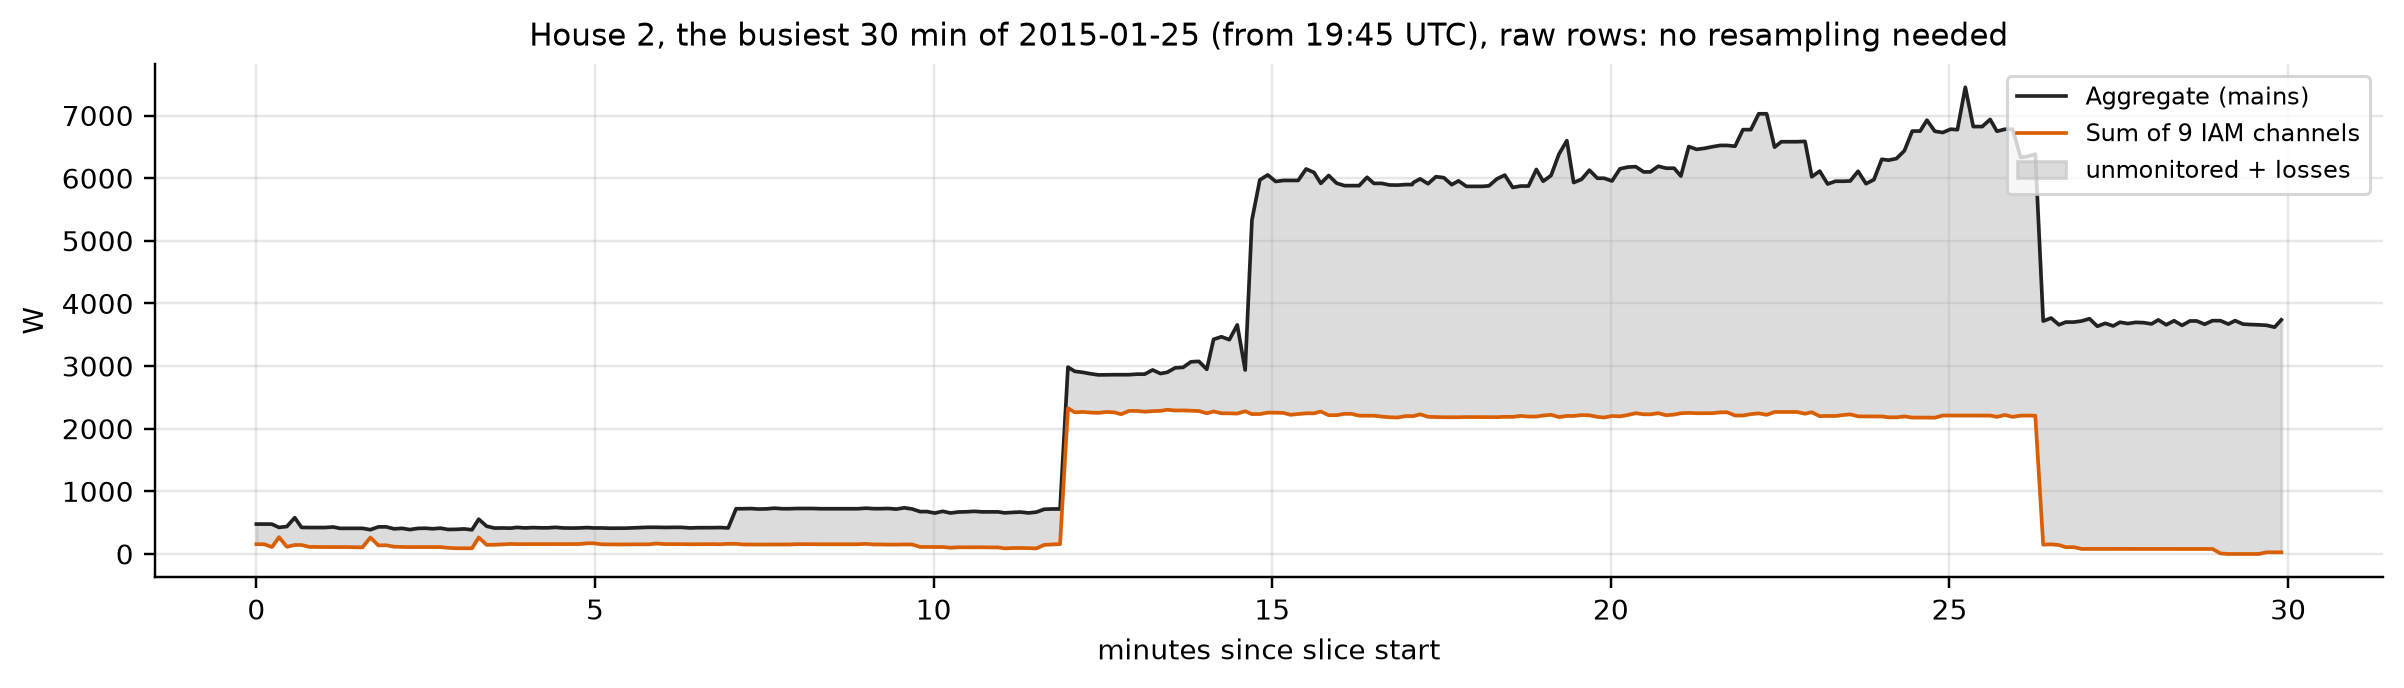

In [ ]:
# Exact per-row alignment: aggregate vs sum of submeters, 30 raw minutes.
_d = PASS['dil_slice']
_fig, _ax = plt.subplots(figsize=(11, 3.2))
_ax.plot(_d['ts'], _d['agg'], color='#222222', lw=1.2, label='Aggregate (mains)')
_ax.plot(_d['ts'], _d['sub'], color='#d95f02', lw=1.2, label='Sum of 9 IAM channels')
gap = _d['agg'] - _d['sub']
_ax.fill_between(_d['ts'], _d['sub'], _d['agg'], color='#bbbbbb', alpha=0.5, label='unmonitored + losses')
_ax.set_xlabel('minutes since slice start')
_ax.set_ylabel('W')
_ax.set_title('House 2, the busiest 30 min of %s (from %s UTC), raw rows: no resampling needed' % (PASS['day']['day'], _d['start']))
_ax.legend(fontsize=8, loc='upper right')
_fig.tight_layout()
print('rows in slice:', len(_d['ts']), '| all rows on one shared grid: True')
_fig  # render figure as cell output

Reading it. The two lines are computed on the same timestamps, so the gray
band is *exactly* the unmonitored load (lighting, oven, TV, standby...) - not a
resampling artifact like in UK-DALE. This window (chosen as the busiest half
hour of the house's busiest day) shows cooking- and appliance-scale movement;
the submeters catch part of it, but much of the swing lives in the gray band,
because only up to nine appliances are metered per home.

**[collectable]** Wide, clock-aligned capture is what makes aggregate-vs-submeter
audits trivial. Our Shelly EM setup records all channels on one device clock -
keep it that way; it is worth more than any post-hoc alignment.

### A day in the life of house 2

House 2 is canonical-rich (fridge-freezer, washing machine, dishwasher,
microwave, kettle all metered) and comparatively clean. The day below is its
highest *clean aggregate* energy day in the whole recording (stuck-meter rows
excluded from the ranking).

busiest day: 2015-01-25 | channels drawn: ['Fridge-Freezer (ap1)', 'Washing Machine (ap2)', 'Dishwasher (ap3)', 'Kettle (ap8)']


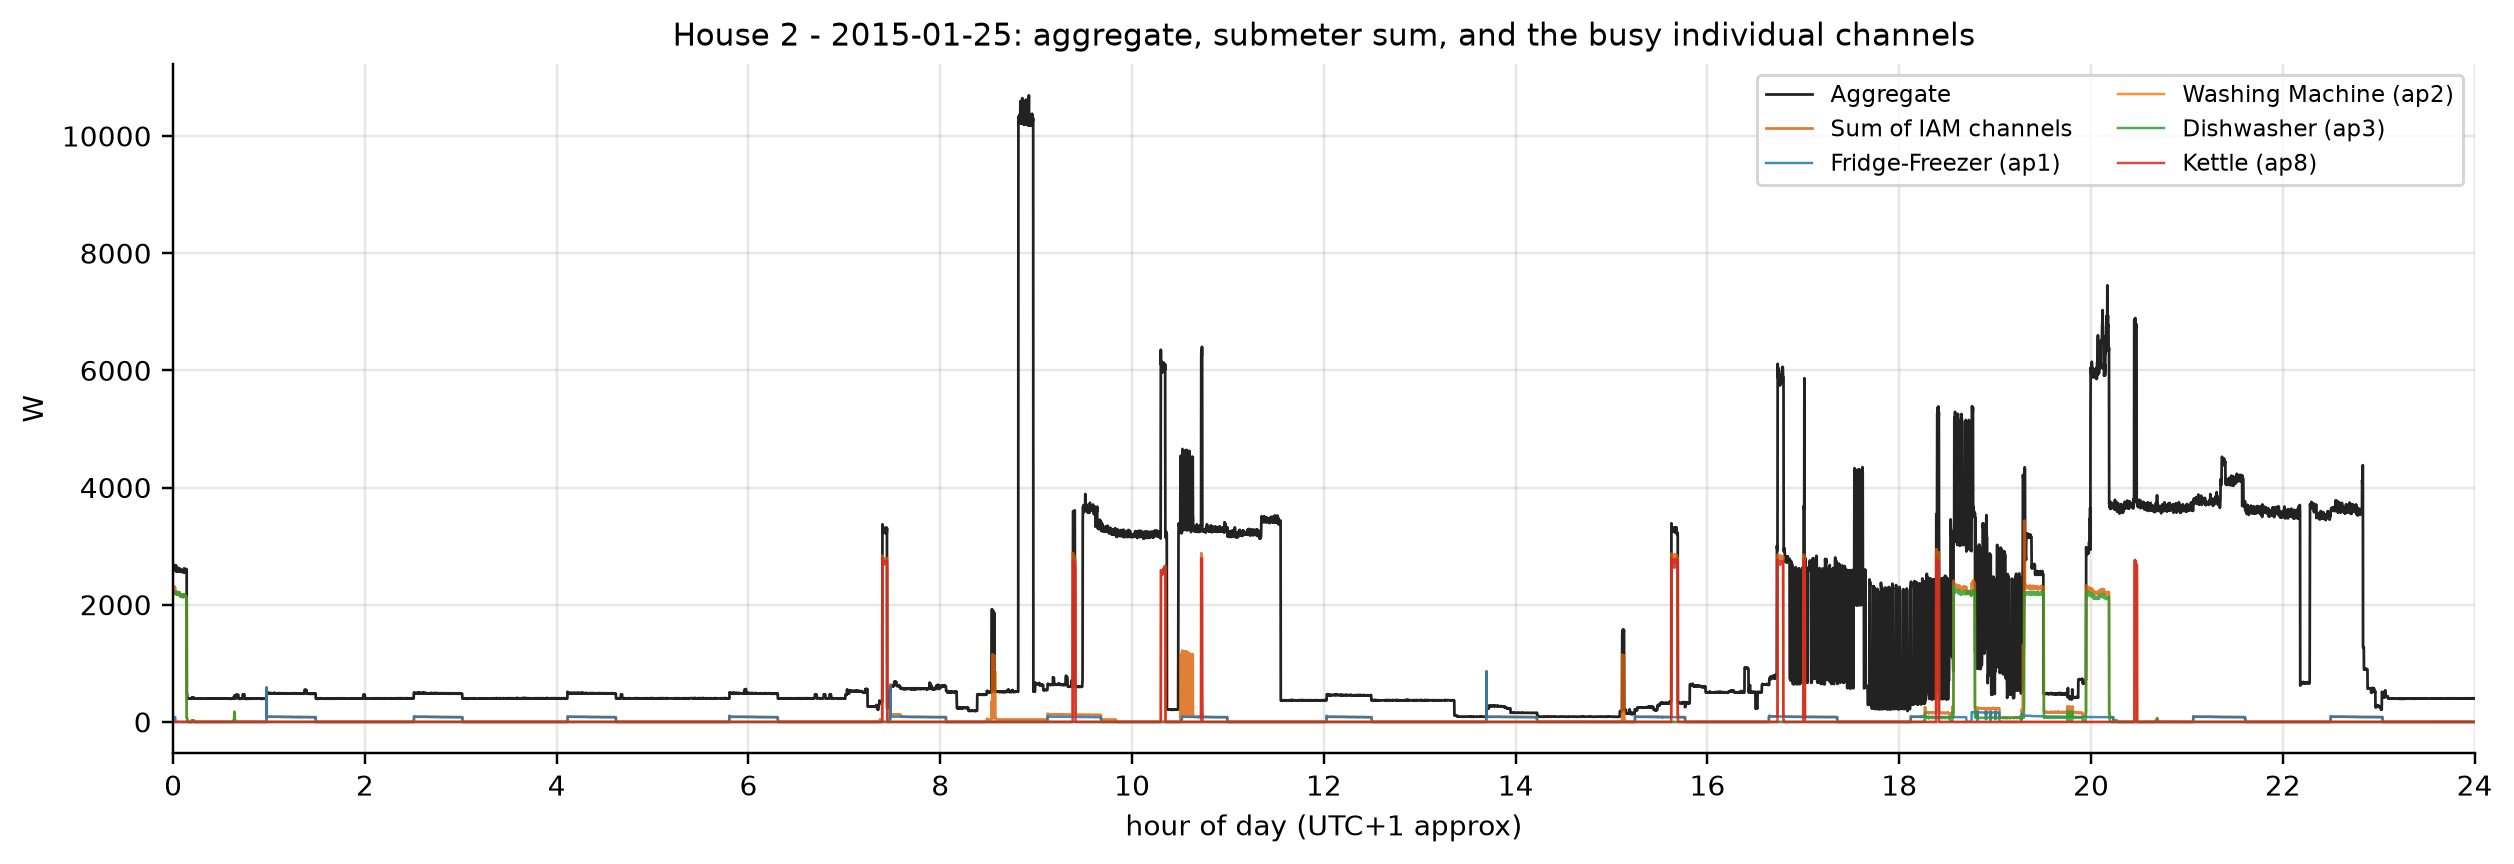

In [ ]:
_AXH = 'hour of day (UTC+1 approx)'
_d = PASS['day']
_fig, _ax = plt.subplots(figsize=(11.5, 4))
_ax.plot(_d['ts'], _d['agg'], color='#222222', lw=0.9, label='Aggregate')
_ax.plot(_d['ts'], _d['sub'], color='#d95f02', lw=0.9, alpha=0.8, label='Sum of IAM channels')
cmap = plt.cm.tab10
for _k, (_lab, _v) in enumerate(_d['series'].items()):
    _ax.plot(_d['ts'], _v, lw=0.8, color=cmap(_k % 10), alpha=0.85, label=_lab)
_ax.set_xlim(0, 24)
_ax.set_xticks(range(0, 25, 2))
_ax.set_xlabel(_AXH)
_ax.set_ylabel('W')
_ax.set_title('House 2 - %s: aggregate, submeter sum, and the busy individual channels' % _d['day'])
_ax.legend(fontsize=7.5, ncol=2, loc='upper right')
_fig.tight_layout()
print('busiest day:', _d['day'], '| channels drawn:', list(_d['series'].keys()))
_fig  # render figure as cell output

Reading it. A readable "day-in-the-life": the kettle's 3 kW needles (a few
minutes each), the washing machine's long programme with heater spikes and spin
bursts, the fridge-freezer's steady cycling under everything. The gap between
the orange line (submeters) and the black line (aggregate) is the unmonitored
household - lighting, oven, TV, standby; on a cooking-heavy day like this one it
widens exactly at meal times.

Note how *readable* the appliance channels are at 7-second cadence: phases of
the washing machine are visible to the eye. That is the promise of submetered
data - and the reason we want it in our own deployment.

### When does this house use power?

Two cheap, robust shapes: the hour-of-day profile and the day-of-week profile
(computed on the aggregate; hours shifted to approximate UK local time, UTC+1).

peak hour share: 9.83% | quietest hour: 1.57%
weekend vs weekday kWh/day: Sat 11.2, Sun 11.4 vs Mon-Fri mean 10.2


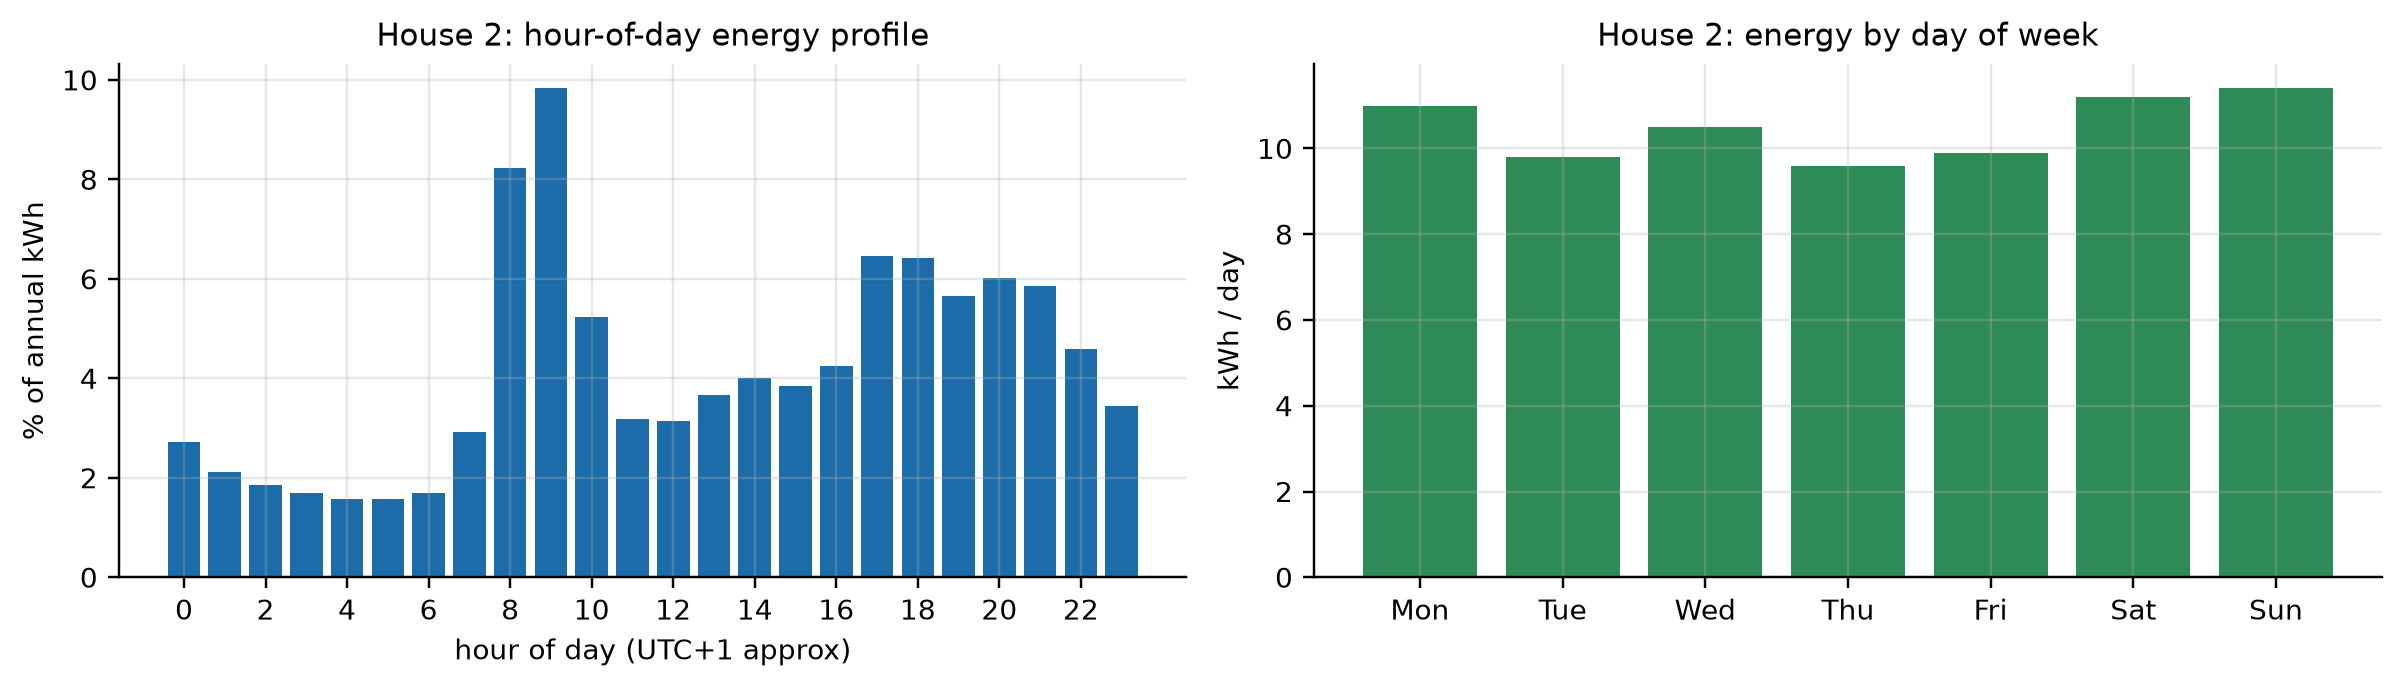

In [ ]:
_AXH = 'hour of day (UTC+1 approx)'
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.2))
_ax = _axes[0]
_ax.bar(range(24), PASS['diurnal'], color='#1b6ca8')
_ax.set_xticks(range(0, 24, 2))
_ax.set_xlabel(_AXH)
_ax.set_ylabel('% of annual kWh')
_ax.set_title('House 2: hour-of-day energy profile')
_ax = _axes[1]
names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
_ax.bar(names, PASS['weekday'], color='#2e8b57')
_ax.set_ylabel('kWh / day')
_ax.set_title('House 2: energy by day of week')
_fig.tight_layout()
print('peak hour share: %.2f%%' % max(PASS['diurnal']), '| quietest hour: %.2f%%' % min(PASS['diurnal']))
print('weekend vs weekday kWh/day: Sat %.1f, Sun %.1f vs Mon-Fri mean %.1f' % (PASS['weekday'][5], PASS['weekday'][6], float(np.mean(PASS['weekday'][:5]))))
_fig  # render figure as cell output

Reading it. A classic working-home profile: an overnight floor (fridge +
standby), then the single sharpest hour of the day at 08:00 - breakfast -
carrying ~10% of the whole day's energy in sixty minutes. A broad evening
shoulder (16:00-20:00) follows at roughly two-thirds of the breakfast peak, and
the overnight floor sits near 1.6% per hour. Over a week the cycle is weak:
Sunday is the heaviest day (~11 kWh) but Saturday actually sits below the
Mon-Fri mean (9.9 vs 10.5) - house 2 is not a strong weekly-cycle house.

**[insight only]** These two shapes are the cheapest "did we record long enough?"
sanity check: one week of data already shows the daily structure, but you need
months to see whether it is stable.

## Q3 - When the fleet stood still

A meter that stops *changing* is more dangerous than a meter that stops
*reporting*: rows keep arriving, values look plausible, and nothing obviously
breaks. We scanned every house for runs where the aggregate holds an identical
wattage for over an hour. The result is the single most important quality
finding of this dataset.

In [ ]:
_rows = []
for _h in sorted(PASS['stuck'], key=lambda x: int(x.replace('House', ''))):
    _s = PASS['stuck'][_h]
    if _s['dead_pct'] >= 0.5:
        _t0, _w, _hrs = _s['top'][0]
        _rows.append([_h.replace('House', 'H'), '%.2f%%' % _s['dead_pct'], pd.Timestamp(_t0, unit='us').strftime('%Y-%m-%d'), '%d W' % _w, '%.1f h' % _hrs, '%.0f kWh' % (_s['kwh_raw'] - _s['kwh_clean'])])
worst = max(PASS['stuck'], key=lambda h: PASS['stuck'][h]['dead_pct'])
tot_ph = sum((s['kwh_raw'] - s['kwh_clean'] for s in PASS['stuck'].values()))
tot_raw = sum((s['kwh_raw'] for s in PASS['stuck'].values()))
print('houses with >5%% of span frozen: %d' % sum((1 for s in PASS['stuck'].values() if s['dead_pct'] > 5)))
print('phantom energy from >1h plateaus: %.0f kWh of %.0f kWh total (%.1f%%)' % (tot_ph, tot_raw, 100 * tot_ph / tot_raw))
mo.md(eda.md_table(['house', 'span in >1h plateaus', 'longest starts', 'at', 'duration', 'phantom kWh'], _rows))

houses with >5% of span frozen: 4
phantom energy from >1h plateaus: 6338 kWh of 117145 kWh total (5.4%)


| house | span in >1h plateaus | longest starts | at | duration | phantom kWh |
| --- | --- | --- | --- | --- | --- |
| H2 | 0.55% | 2014-12-02 | 153 W | 24.4 h | 46 kWh |
| H3 | 13.73% | 2014-05-09 | 491 W | 37.3 h | 1364 kWh |
| H4 | 3.86% | 2014-02-28 | 496 W | 505.3 h | 224 kWh |
| H8 | 0.56% | 2014-10-22 | 231 W | 13.8 h | 49 kWh |
| H9 | 5.17% | 2014-03-13 | 394 W | 500.8 h | 234 kWh |
| H10 | 9.16% | 2014-02-28 | 2169 W | 855.0 h | 1794 kWh |
| H13 | 2.94% | 2015-03-05 | 565 W | 116.2 h | 296 kWh |
| H16 | 1.69% | 2014-11-15 | 162 W | 77.0 h | 80 kWh |
| H17 | 1.70% | 2015-02-26 | 2285 W | 145.5 h | 345 kWh |
| H18 | 1.50% | 2015-05-22 | 0 W | 46.0 h | 52 kWh |
| H20 | 3.43% | 2015-02-26 | 445 W | 326.5 h | 148 kWh |
| H21 | 8.58% | 2015-06-05 | 1789 W | 657.0 h | 1516 kWh |

plateau itself is EXACTLY constant: unique values after onset = 1
displayed window includes the 12 h pre-onset lead-in: unique values there = 1515


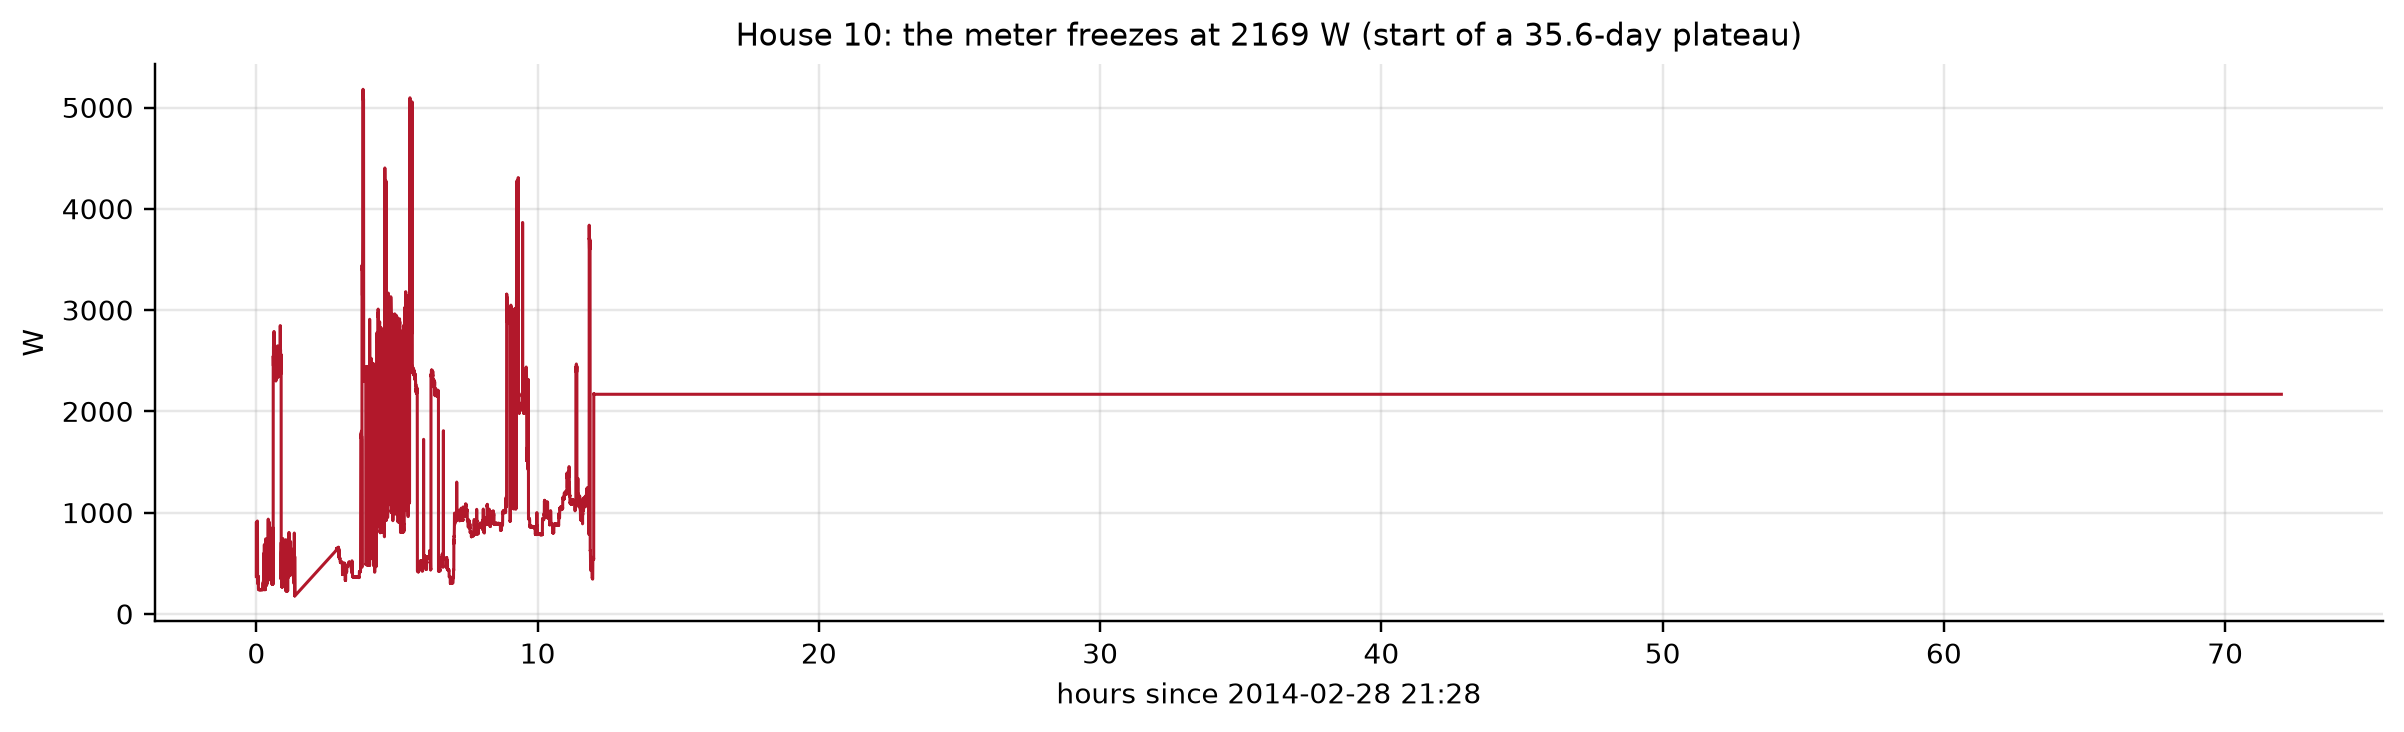

In [ ]:
# The worst plateau, up close: house 10, aggregate frozen at one value for 35.6 days.
_p = PASS['plateau']
_fig, _ax = plt.subplots(figsize=(11, 3.4))
_ax.plot(_p['ts'], _p['agg'], color='#b2182b', lw=1.0)
_ax.set_xlabel('hours since %s' % _p['start'])
_ax.set_ylabel('W')
_ax.set_title('House 10: the meter freezes at %d W (start of a %.1f-day plateau)' % (_p['w'], _p['hours'] / 24.0))
_fig.tight_layout()
print('plateau itself is EXACTLY constant: unique values after onset =', _p['n_post_unique'])
print('displayed window includes the 12 h pre-onset lead-in: unique values there =', _p['n_pre_unique'])
_fig  # render figure as cell output

Reading it. A real house never does this: even at 3 a.m. the aggregate wobbles
by a few watts as fridges cycle and standby loads drift. Here every sample for
**35.6 days** is the same number, 2169 W. Any training label or energy statistic
computed naively absorbs ~1.9 MWh of energy nobody used. And the frozen value is
not absurd - 2169 W looks like an ordinary evening load, which is exactly why
this defect is dangerous: it passes "is the number plausible?" checks. The
mechanism is documented by the release: the cleaned export **forward-fills NaN
readings** (readme: "NaN values have been forward filled"), and the release's
dataset description attributes long static stretches to connection loss - rows
keep arriving on one clock while the measurement is stale.

**[collectable]** Our devices should ship a **heartbeat**: a counter that must
increment between consecutive frames. A frozen channel is then a detected fault
("sensor stopped changing"), not a silent poison. This is cheap to collect and
worth more than any downstream cleaning.

houses frozen on 2014-08-30: 14 | on 2014-08-01: 15
2014-08-30: longest per-house plateau inside the window - median 9.1 h, range 9.0-9.1 h (n=14)
2014-08-01: longest per-house plateau inside the window - median 2.2 h, range 2.2-2.2 h (n=15)


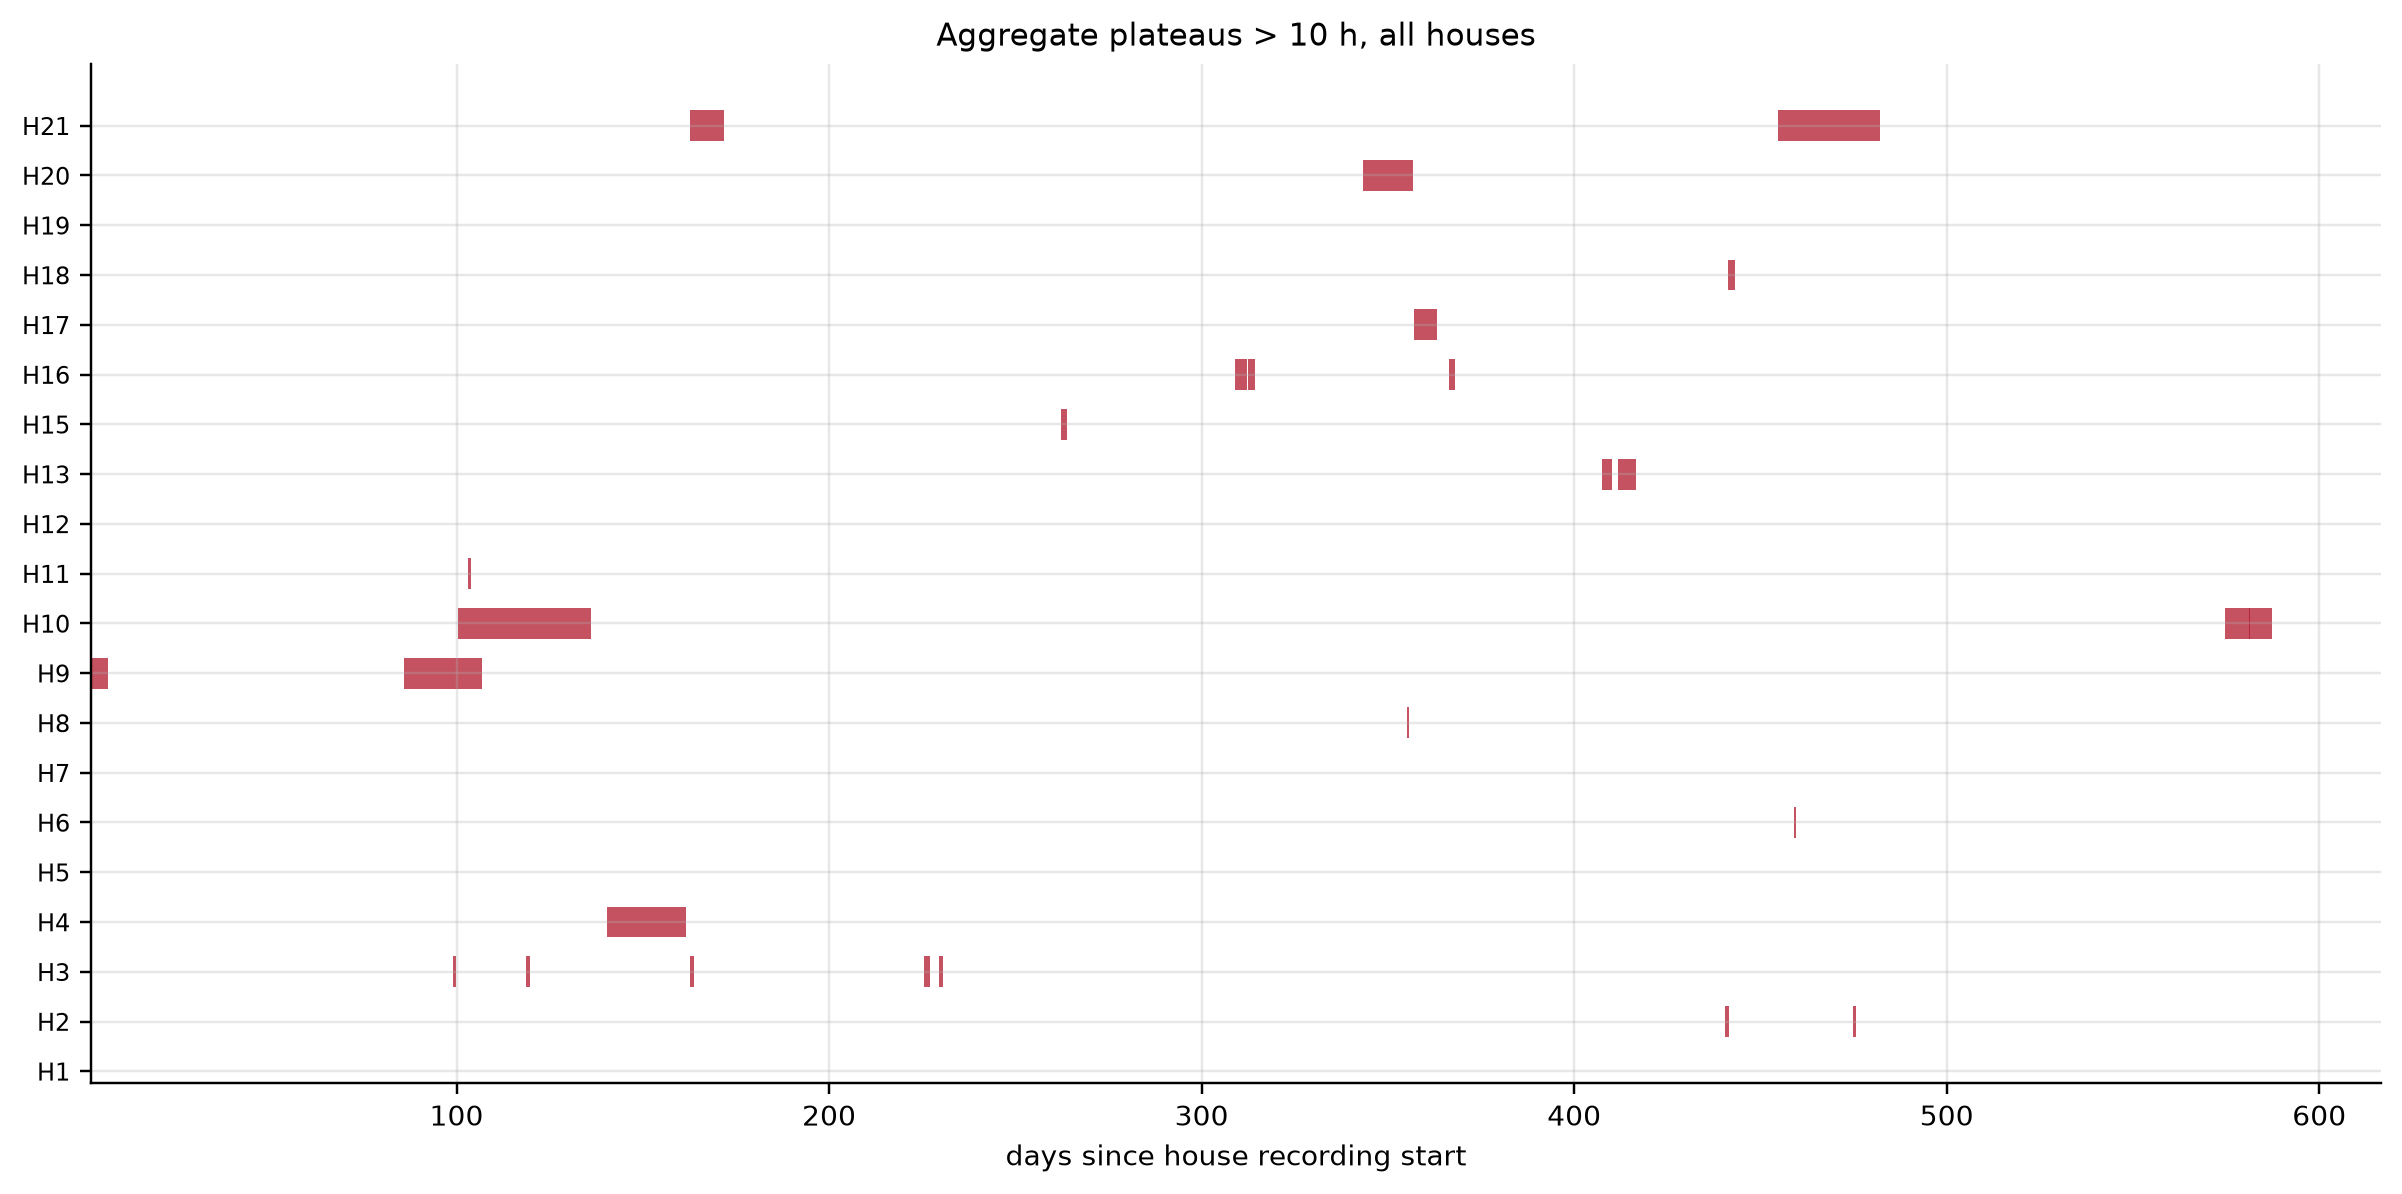

In [ ]:
# Dead-window chart: one row per house, bars = longest plateaus.
_fig, _ax = plt.subplots(figsize=(11, 5.5))
houses = sorted(PASS['stuck'], key=lambda x: int(x.replace('House', '')))
t_min = min((r[0] for h in houses for r in PASS['stuck'][h]['top']))
t_max = max((r[0] for h in houses for r in PASS['stuck'][h]['top'])) + 90 * 86400 * 10 ** 6
for _k, _h in enumerate(houses):
    for _t0, _w, _hrs in PASS['stuck'][_h]['top']:
        if _hrs < 10:
            continue
        x0 = (_t0 - PASS['inv'][_h]['first_ts']) / 86400000000.0
        _ax.barh(_k, _hrs / 24, left=x0, height=0.62, color='#b2182b', alpha=0.75)
_ax.set_yticks(range(len(houses)))
_ax.set_yticklabels([h.replace('House', 'H') for h in houses], fontsize=8)
_ax.set_xlabel('days since house recording start')
_ax.set_title('Aggregate plateaus > 10 h, all houses')
_fig.tight_layout()
fr = {h: PASS['freeze'][h] for h in houses}
n1 = sum((1 for v in fr.values() if '2014-08-30' in v))
n2 = sum((1 for v in fr.values() if '2014-08-01' in v))
print('houses frozen on 2014-08-30:', n1, '| on 2014-08-01:', n2)
for wi, _d in enumerate(['2014-08-30', '2014-08-01']):
    ds = [PASS['freeze_dur'][h][wi] for h in houses if PASS['freeze_dur'][h][wi] is not None]
    if ds:
        print('%s: longest per-house plateau inside the window - median %.1f h, range %.1f-%.1f h (n=%d)' % (_d, float(np.median(ds)), min(ds), max(ds), len(ds)))
_fig  # render figure as cell output

Reading it. Two stories at once. First, the long red bars are house-specific
failures (houses 4, 9, 10, 20, 21 each lost weeks). Second, there is a
**vertical alignment**: on 2014-08-30 fourteen of the twenty homes froze (printed
per-house plateau lengths: median 9.1 h), and fifteen did again on 2014-08-01
(median 2.2 h). Note these plateau lengths are row-mass - during a connection
loss few rows arrive, so the same value spans a longer wall-clock window. Whatever
the cause - a logger deployment, a central server, a shared firmware - it hit the
*fleet*, not one home. And the table above already quantified the cost: plateaus
account for 5.4% of all aggregate energy the fleet ever recorded.

**[insight only]** Fleet-synchronous faults mean your failures are correlated
across homes. If we ever run a multi-home study, the monitoring dashboard must
watch the fleet as a whole, not per-home dashboards only.

**[collectable]** A watchdog that alerts on "value unchanged for N minutes" and
"gap in stream" - both detected live above - is the practical takeaway.

## Q4 - What is actually monitored?

Nine IAM channels per house, with names from the release's metadata
spreadsheet. Labels are free text ("Washer Dryer", "Television Site", "???"),
so we use the project's gold mapping to collapse them to canonical types. First:
which appliance types appear in how many houses?

fridge           35 channels in 20 houses
washing_machine  24 channels in 19 houses
microwave        17 channels in 16 houses
dishwasher       15 channels in 15 houses
kettle           15 channels in 15 houses
tumble_dryer      7 channels in  7 houses


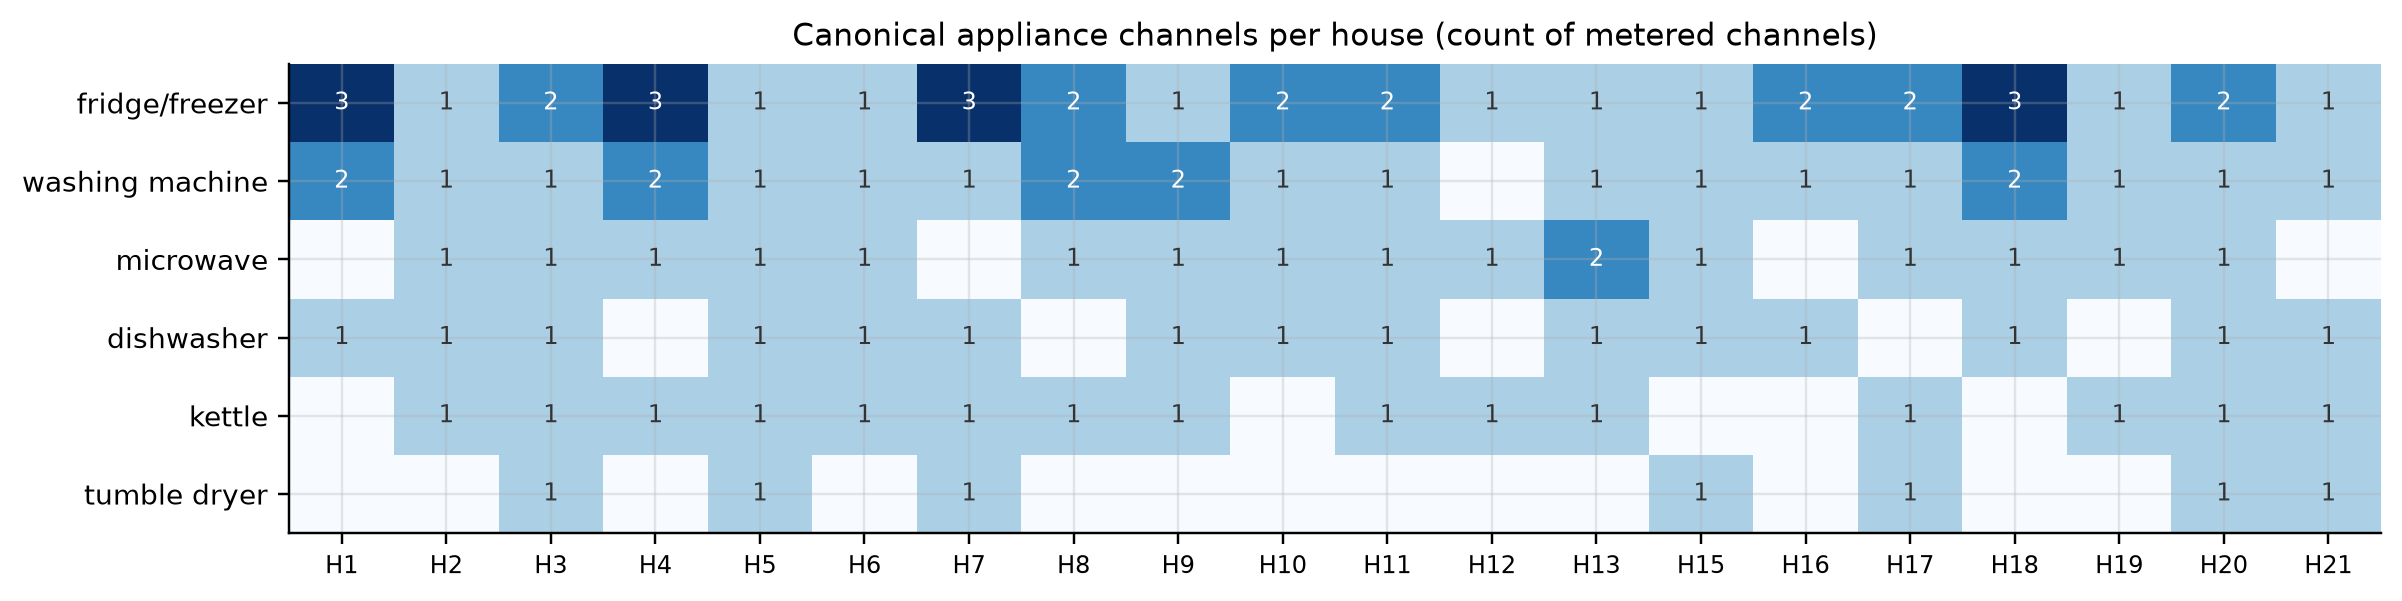

In [ ]:
canon_houses = {}
for _h, _cols in PASS['cols_per_house'].items():
    for _col, _rec in _cols.items():
        _cn = _rec.get('canonical') or ('tumble_dryer' if 'tumble' in _rec['label'].lower() else None)
        if _cn:
            canon_houses.setdefault(_cn, {}).setdefault(_h, 0)
            canon_houses[_cn][_h] = canon_houses[_cn][_h] + 1
_order = ['fridge', 'washing_machine', 'microwave', 'dishwasher', 'kettle', 'tumble_dryer']
houses_sorted = sorted(PASS['cols_per_house'], key=lambda x: int(x.replace('House', '')))
_mat = np.zeros((len(_order), len(houses_sorted)))
for _i, _cn in enumerate(_order):
    for _j, _h in enumerate(houses_sorted):
        _mat[_i, _j] = canon_houses.get(_cn, {}).get(_h, 0)
_fig, _ax = plt.subplots(figsize=(11, 2.8))
_im = _ax.imshow(_mat, cmap='Blues', aspect='auto', vmin=0, vmax=3)
_ax.set_xticks(range(len(houses_sorted)))
_ax.set_xticklabels([h.replace('House', 'H') for h in houses_sorted], fontsize=8)
_ax.set_yticks(range(len(_order)))
_ax.set_yticklabels(['fridge/freezer', 'washing machine', 'microwave', 'dishwasher', 'kettle', 'tumble dryer'], fontsize=9)
for _i in range(len(_order)):
    for _j in range(len(houses_sorted)):
        if _mat[_i, _j]:
            _ax.text(_j, _i, int(_mat[_i, _j]), ha='center', va='center', fontsize=8, color='white' if _mat[_i, _j] > 1.6 else '#333333')
_ax.set_title('Canonical appliance channels per house (count of metered channels)')
_fig.tight_layout()
for _cn in _order:
    _n_cols = sum(canon_houses.get(_cn, {}).values())
    n_h = len(canon_houses.get(_cn, {}))
    print('%-16s %2d channels in %2d houses' % (_cn, _n_cols, n_h))
_fig  # render figure as cell output

Reading it. The cold-chain rows are nearly full: some form of fridge or freezer
is metered in **every one of the 20 houses** (35 channels total - several homes
meter two or three cold appliances). Washing machines are almost universal (19
of 20 houses, 24 channels). Kettles and dishwashers appear in 15 each; the
canonical five are metered widely enough for cross-house statistics, which is
unusual among public datasets and is REFIT's core value for us. One mapping
caveat, printed above: the **7 tumble-dryer channels are matched by label
substring** - the gold map has no tumble-dryer type, and the release's own
description lists 10 (it counts washer-dryer combinations as dryers). Treat the
dryer row as a REFIT-local extra, not a gold-mapped class.

**[insight only]** Houses without a kettle channel are not "kettle-free" - the
IAM slots simply ran out (9 channels, dozens of appliances per home). Absence of
a channel is a *deployment* choice, never evidence of absence of the appliance.
That distinction must survive into any gold-layer documentation.

### But are the labels true? A data-driven label audit

A label is a claim; the channel's behaviour is evidence. Three audits:

1. **Dead channels** - never record a non-zero value (installed but never
   transmitted, or never installed?).

2. **Unplugged mid-study** - long runs of exactly zero *after* being active.

3. **Label-vs-signature mismatches** - a "kettle" whose typical ON level is
   113 W, or a "microwave" that behaves like a compressor.

In [ ]:
_rows = []
for _h in sorted(PASS['cols_per_house'], key=lambda x: int(x.replace('House', ''))):
    _cols = PASS['cols_per_house'][_h]
    for _col, _rec in _cols.items():
        tag = None
        if _rec['nz_frac'] == 0:
            tag = 'DEAD (never > 0)'
        elif _rec['nz_frac'] < 0.0008 and _rec['kwh_clean'] < 5:
            tag = 'trace (used < ~5 kWh total)'
        elif _rec['label'].lower() == 'kettle' and _rec['p50_on_w'] < 500:
            tag = 'KETTLE at %d W p50-on?!' % _rec['p50_on_w']
        elif _rec['label'].lower() == 'microwave' and _rec['duty_pct'] > 50:
            tag = 'MICROWAVE with %.0f%% duty (compressor-like?)' % _rec['duty_pct']
        if tag:
            _rows.append([_h.replace('House', 'H'), _col.replace('Appliance', 'ap'), _rec['label'], tag])
mo.md(eda.md_table(['house', 'col', 'label', 'verdict from data'], _rows))

| house | col | label | verdict from data |
| --- | --- | --- | --- |
| H12 | ap6 | Kettle | KETTLE at 113 W p50-on?! |
| H12 | ap7 | Toaster | DEAD (never > 0) |
| H12 | ap8 | Television | DEAD (never > 0) |
| H12 | ap9 | ??? | DEAD (never > 0) |
| H13 | ap7 | Microwave | MICROWAVE with 72% duty (compressor-like?) |
| H15 | ap9 | Toaster | trace (used < ~5 kWh total) |
| H16 | ap3 | Electric Heater(1) | trace (used < ~5 kWh total) |

In [ ]:
unplugged = []
for _f in FILES:
# unplugged mid-study: channels silent in their final 60 days after being active.
# Also: a dedicated look at house 1's dishwasher, which the label audit suspects.
    _house = os.path.basename(_f).replace('CLEAN_', '').replace('.parquet', '')
    _t = pq.read_table(_f, columns=['ts_us'] + ['Appliance%d' % i for i in range(1, 10)])
    _ts = np.asarray(_t['ts_us'], dtype=np.int64)
    for _i in range(1, 10):
        _col = 'Appliance%d' % _i
        _rec = PASS['cols_per_house'][_house][_col]
        if _rec['nz_frac'] < 0.0005 or _rec['nz_frac'] > 0.6:
            continue
        _v = np.asarray(_t[_col], dtype=np.float64)
        cut = _ts[-1] - 60 * 86400 * 10 ** 6
        late_alive = float((_v[_ts >= cut] != 0).mean())
        early_frac = float((_v[:len(_v) // 2] != 0).mean())
        if early_frac > 0.002 and late_alive == 0.0:
            last_on = pd.Timestamp(int(_ts[_v != 0][-1]), unit='us').strftime('%Y-%m-%d')
            unplugged.append((_house.replace('House', 'H'), _col.replace('Appliance', 'ap'), _rec['label'], last_on))
        del _v
    del _t, _ts
mo.md(eda.md_table(['house', 'col', 'label', 'last active day'], unplugged) if unplugged else "*(no channel is fully silent in its final 60 days after being active)*")

| house | col | label | last active day |
| --- | --- | --- | --- |
| H7 | ap3 | Freezer(2) | 2015-03-21 |
| H11 | ap3 | Washing Machine | 2015-04-29 |
| H13 | ap2 | Freezer | 2014-08-18 |
| H16 | ap9 | Dehumidifier | 2015-03-20 |

In [ ]:
t1 = pq.read_table(eda.fnd_file('refit', 'CLEAN_House1.parquet'), columns=['ts_us', 'Appliance6'])
ts1 = np.asarray(t1['ts_us'], dtype=np.int64)
v1 = np.asarray(t1['Appliance6'], dtype=np.float64)
nz = v1 != 0
print('House1 "Dishwasher" (ap6): last non-zero reading %s; zero for the final %.0f days' % (pd.Timestamp(int(ts1[nz][-1]), unit='us').strftime('%Y-%m-%d'), (ts1[-1] - ts1[nz][-1]) / 86400000000.0))
del t1, ts1, v1, nz

House1 "Dishwasher" (ap6): last non-zero reading 2015-07-10; zero for the final 0 days


In [ ]:
stalled = []
for _h in sorted(PASS['cols_per_house'], key=lambda x: int(x.replace('House', ''))):
    for _col, _rec in PASS['cols_per_house'][_h].items():
        if _rec['frozen_pct'] > 20:
            stalled.append([round(_rec['frozen_pct']), _h.replace('House', 'H'), _col.replace('Appliance', 'ap'), _rec['label']])
stalled.sort(key=lambda r: -r[0])
# stalled channels: non-zero constant runs >= 1 h covering > 20% of rows
print('channels with > 20%% of rows pinned at one non-zero value (runs >= 1 h): %d of %d' % (len(stalled), sum((len(c) for c in PASS['cols_per_house'].values()))))
mo.md(eda.md_table(['frozen % rows', 'house', 'col', 'label'], stalled[:14]))

channels with > 20% of rows pinned at one non-zero value (runs >= 1 h): 14 of 180


| frozen % rows | house | col | label |
| --- | --- | --- | --- |
| 98 | H13 | ap8 | Microwave |
| 96 | H18 | ap9 | Microwave |
| 95 | H6 | ap6 | Microwave |
| 94 | H9 | ap8 | Hi-Fi |
| 90 | H1 | ap9 | Electric Heater |
| 83 | H4 | ap8 | Microwave |
| 70 | H21 | ap8 | Vivarium |
| 59 | H12 | ap3 | ??? |
| 47 | H13 | ap5 | ??? |
| 30 | H2 | ap1 | Fridge-Freezer |
| 28 | H20 | ap8 | Microwave |
| 25 | H5 | ap3 | Washing Machine |
| 25 | H21 | ap1 | Fridge-Freezer |
| 24 | H9 | ap5 | Television Site |

Reading it. House 12 is the problem child: three dead channels *and* a "kettle"
whose typical ON level is ~113 W (a real kettle boils at 2-3 kW) - that channel
measures something else entirely. House 13 has a "microwave" with compressor-like
duty (we will see its signature in the gallery); its two "Microwave" labels are
also a duplicate-labelling slip. And the audit table above catches four channels
that went **silent mid-study after being active** - two freezers (H13, H7), a
washing machine (H11) and a dehumidifier (H16). An appliance leaving the trial
looks exactly like a frugal appliance unless you check the active window. The
cross-reference is direct: House 13's freezer outlier in Q5 (the ~1.5 kW p50-ON
"freezer") is the *same channel* that went silent on 2014-08-18 - the label
survived a swap or unplug. The stall table adds a fourth failure mode: whole
channels **pinned at one non-zero value** for a large share of their rows - that
is why the inventory pass masks every channel's own >= 1 h constant runs, and
Q5/Q11 exclude channels stalled for > 20% of their rows.

**[collectable]** Two practices fall out directly. First, an **installation
audit** at commissioning: each channel must record one known event (kettle boiled,
fridge unplugged) before acceptance - that is how you catch a dead or mislabeled
channel on day one, not month fourteen. Second, **distinguish "OFF" from "out of
the study"**: our schema should carry a per-channel active window, so a plug that
is removed does not masquerade as a frugal appliance.

## Q5 - Is a washing machine a washing machine everywhere?

The fleet lets us put the same appliance type from many homes side by side.
Three questions: how much power does it draw when ON (p50 of on-samples), how
often does it cycle (episodes/day), and what share of time it spends ON (duty;
ON-duration medians are tabulated in Q11). The gray bands below are the spread
across houses for each canonical type. Channels stalled for > 20% of their rows
(see the exclusion print) are kept out of the panels: a pinned meter produces
confident-looking but meaningless statistics.

channels excluded from Q5/Q11 (stalled > 20% of rows):
  fridge: H2 ap1 (30% frozen), H21 ap1 (25% frozen)
  microwave: H4 ap8 (83% frozen), H6 ap6 (95% frozen), H13 ap8 (98% frozen), H18 ap9 (96% frozen), H20 ap8 (28% frozen)
  washing_machine: H5 ap3 (25% frozen)
total: 8 of 180 channels excluded
kettle           p50-on W: min 113 / median 2614 / max 2946
fridge/freezer   p50-on W: min 36 / median 85 / max 1519
dishwasher       p50-on W: min 42 / median 109 / max 2545
washing machine  p50-on W: min 73 / median 150 / max 1376
fridge/freezer max is H13 Appliance2 "Freezer" at 1519 W p50-on


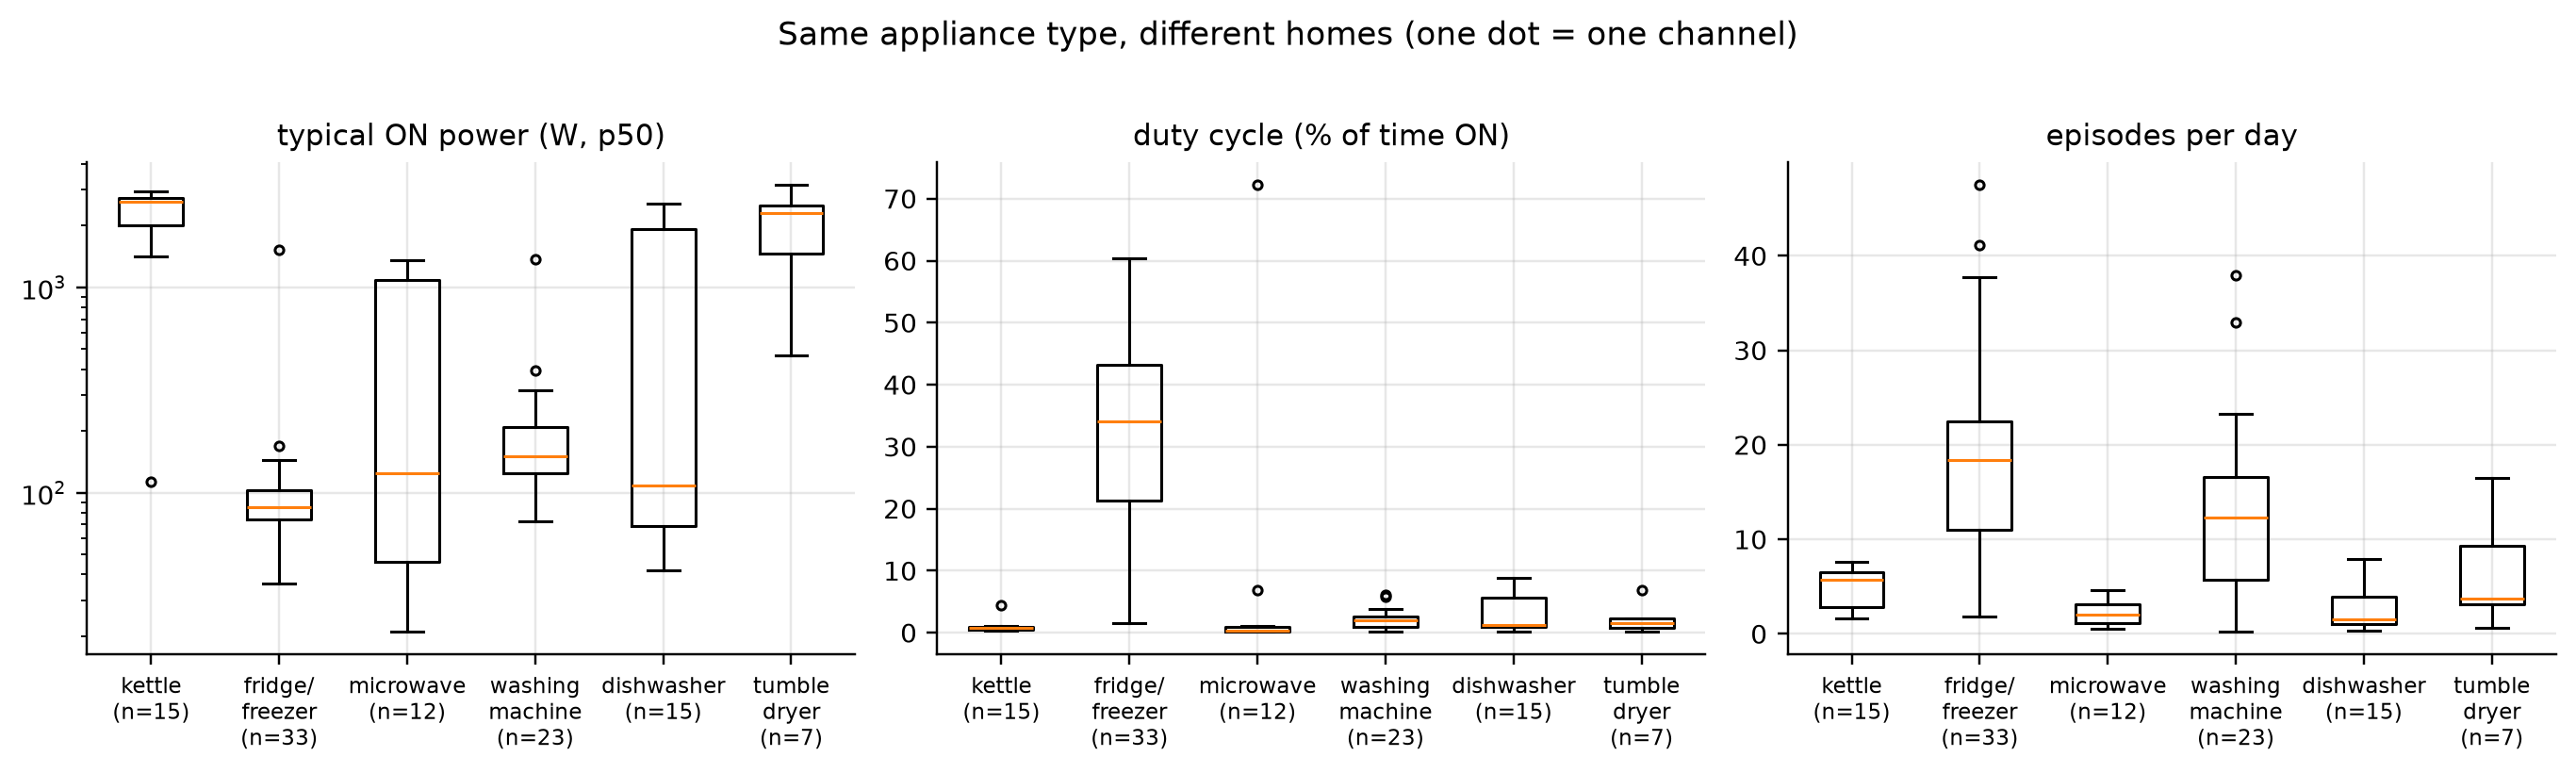

In [ ]:
# p50-on power, duty, episodes/day: per house, per canonical type.
# Channels stalled > 20% of their rows (non-zero constant runs >= 1 h) are excluded
# from the panels and from everything downstream: a pinned meter returns confident-looking stats.
canon_vals = {}
excluded = {}
for _h, _cols in PASS['cols_per_house'].items():
    for _col, _rec in _cols.items():
        _cn = _rec.get('canonical') or ('tumble_dryer' if 'tumble' in _rec['label'].lower() else None)
        if not _cn:
            continue
        if _rec['frozen_pct'] > 20:
            excluded.setdefault(_cn, []).append('%s %s (%.0f%% frozen)' % (_h.replace('House', 'H'), _col.replace('Appliance', 'ap'), _rec['frozen_pct']))
            continue
        canon_vals.setdefault(_cn, {}).setdefault(_h, []).append(_rec)
print('channels excluded from Q5/Q11 (stalled > 20% of rows):')
for _cn in sorted(excluded):
    print('  %s: %s' % (_cn, ', '.join(excluded[_cn])))
n_excl = sum((len(v) for v in excluded.values()))
n_all = sum((len(cols) for cols in PASS['cols_per_house'].values()))
print('total: %d of %d channels excluded' % (n_excl, n_all))
_order = ['kettle', 'fridge', 'microwave', 'washing_machine', 'dishwasher', 'tumble_dryer']
nice = {'kettle': 'kettle', 'fridge': 'fridge/freezer', 'microwave': 'microwave', 'washing_machine': 'washing machine', 'dishwasher': 'dishwasher', 'tumble_dryer': 'tumble dryer'}
_fig, _axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for _ax, _key in zip(_axes, ['p50_on_w', 'duty_pct', 'eps_per_day']):
    data, labels = ([], [])
    for _cn in _order:
        _vals = [r[_key] for h in canon_vals[_cn] for r in canon_vals[_cn][h] if r.get(_key) is not None]
        if _cn == 'washing_machine':
            pass
        data.append(_vals)
        _lab = nice[_cn].replace('fridge/freezer', 'fridge/\nfreezer').replace('washing machine', 'washing\nmachine').replace('tumble dryer', 'tumble\ndryer')
        labels.append('%s\n(n=%d)' % (_lab, len(_vals)))
    _ax.boxplot(data, tick_labels=labels, showfliers=True, flierprops={'markersize': 3})
    plt.setp(_ax.get_xticklabels(), rotation=0, fontsize=6.8)
    _ax.set_yscale('log' if _key == 'p50_on_w' else 'linear')
    _ax.set_title({'p50_on_w': 'typical ON power (W, p50)', 'duty_pct': 'duty cycle (% of time ON)', 'eps_per_day': 'episodes per day'}[_key], fontsize=10)
    _ax.tick_params(axis='x', labelsize=7.5)
_fig.suptitle('Same appliance type, different homes (one dot = one channel)', y=1.02, fontsize=11)
_fig.tight_layout()
for _cn in ['kettle', 'fridge', 'dishwasher', 'washing_machine']:
    _vals = sorted((r['p50_on_w'] for h in canon_vals[_cn] for r in canon_vals[_cn][h]))
    print('%-16s p50-on W: min %d / median %d / max %d' % (nice[_cn], _vals[0], _vals[len(_vals) // 2], _vals[-1]))
fr_all = [(h, r) for h in canon_vals['fridge'] for r in canon_vals['fridge'][h]]
fr_worst = max(fr_all, key=lambda hr: hr[1]['p50_on_w'])
print('fridge/freezer max is %s %s "%s" at %d W p50-on' % (fr_worst[0].replace('House', 'H'), fr_worst[1]['col'], fr_worst[1]['label'], fr_worst[1]['p50_on_w']))
_fig  # render figure as cell output

Reading it. Three different stories:

- **Kettles are a law of physics**: every house's p50-ON sits in a tight
  2-3 kW band (resistive element; fleet median ~2.6 kW). One dot is far below -
  that is house 12's mislabeled channel from Q4, visually confirming itself.

- **Fridges/freezers split into compressor bands** (~50-120 W p50-ON). The one
  extreme outlier at ~1.5 kW (printed above) is no compressor - a mislabel that
  slipped past the duty-cycle check; it is house 13's "Freezer", the very
  channel Q4 shows went silent on 2014-08-18. Duty cycles span from a few
  percent to ~60% (visible in the middle panel): how hard a fridge works is a
  *house* property (temperature setting, ambient heat, door habits) more than
  an appliance property.

- **Washing machines vs washer-dryers**: most wash channels sit at 50-200 W
  p50-ON (pump + heater duty cycles), while washer-dryer channels reach
  ~1.4 kW (the dry-phase heater element); dishwashers likewise split into
  heater-heavy (~2 kW) and pump-dominated (~50-120 W) modes. One appliance,
  two power modes - a preview of why threshold-based ON/OFF detection needs
  per-appliance thresholds.

**[insight only]** This cross-house spread is the single most important training
lesson: models must learn appliance *signatures* (shape, duration, context), not
fixed wattages. A model tuned to one house's kettle number would still work - a
model tuned to one house's fridge would not.

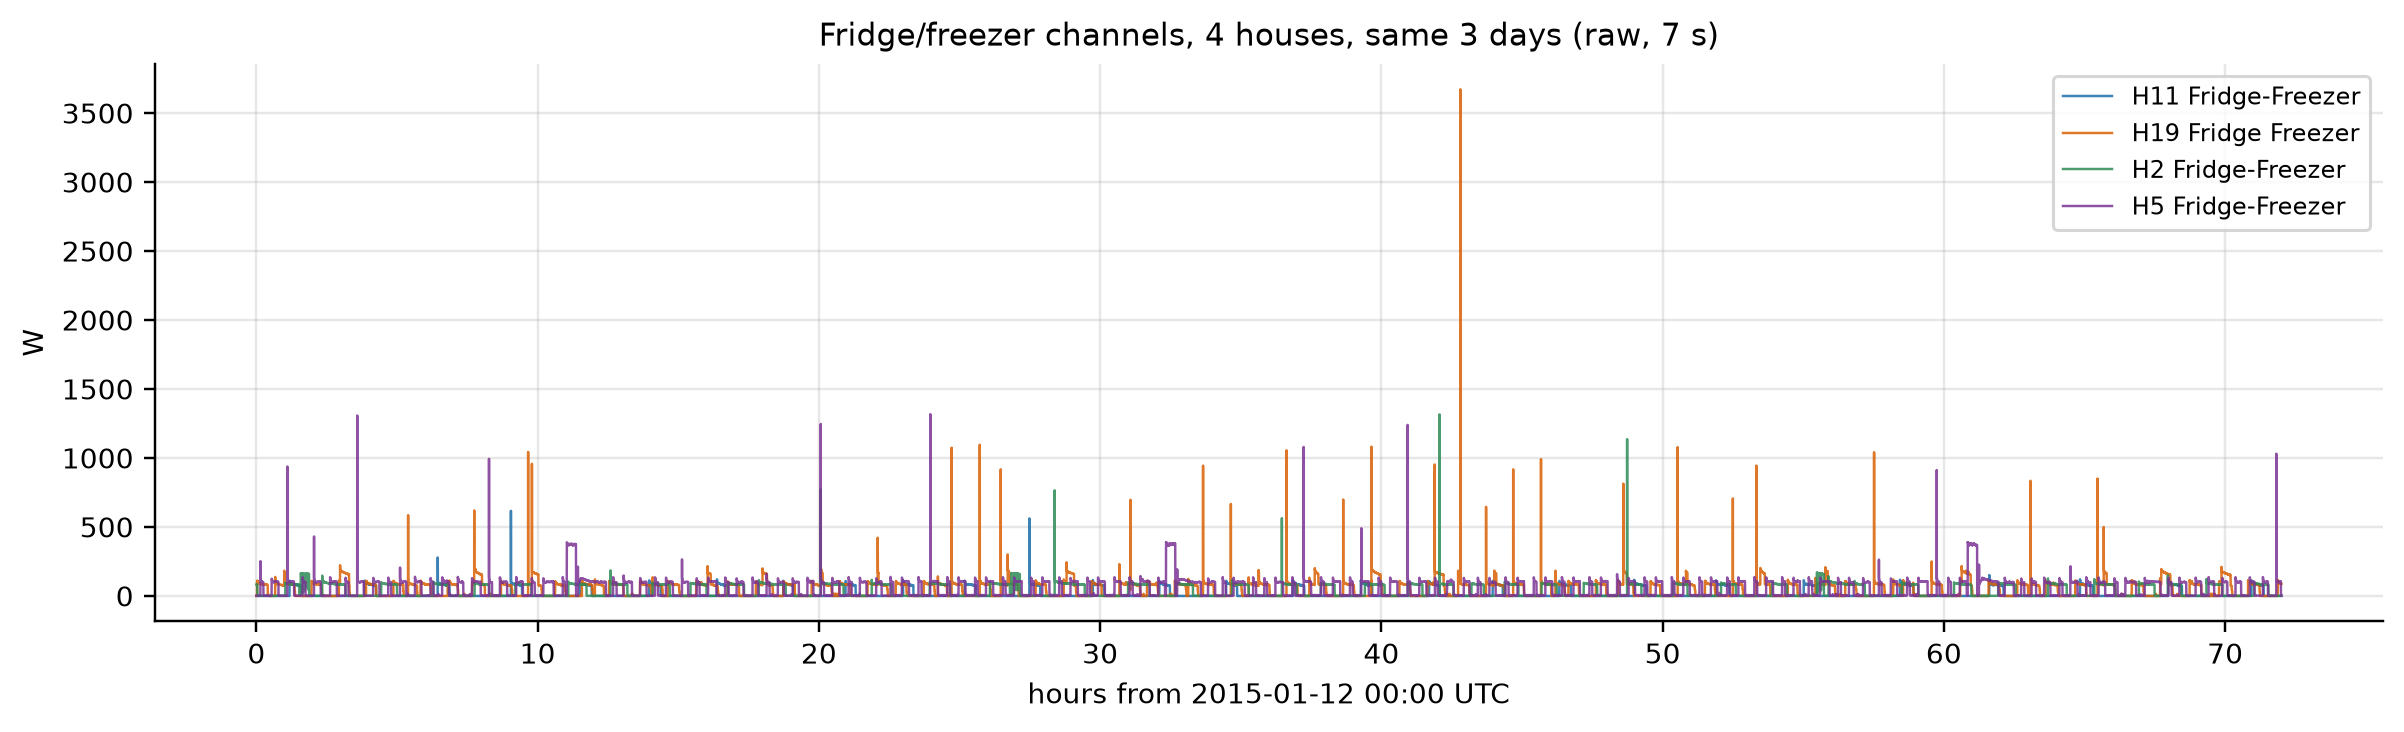

In [ ]:
# One appliance type, four homes, same three winter days: fridge/freezer overlay.
_fig, _ax = plt.subplots(figsize=(11, 3.4))
colors = ['#1b6ca8', '#d95f02', '#2e8b57', '#7b3294']
for _k, (_h, _d) in enumerate(sorted(PASS['overlay'].items())):
    _ax.plot(_d['ts'], _d['v'], lw=0.8, color=colors[_k], alpha=0.85, label='%s %s' % (_h.replace('House', 'H'), _d['label']))
_ax.set_xlabel('hours from 2015-01-12 00:00 UTC')
_ax.set_ylabel('W')
_ax.set_title('Fridge/freezer channels, 4 houses, same 3 days (raw, 7 s)')
_ax.legend(fontsize=8)
_fig.tight_layout()
_fig  # render figure as cell output

Reading it. Four compressors, four personalities: each has a stable duty
rhythm, but cycle length, depth, and phase are all different. Some cycle every
20 minutes, others every hour; some dip to 0 W (defrost cycles visible as flat
zeros), others never stop drawing baseline power. The short high spikes (past
1 kW, one reaching 3.6 kW) are defrost heaters or shared-circuit neighbours -
a raw submeter channel is not always surgically one appliance. Over a 3-day
window the phases
drift apart completely - there is no "fridge schedule" shared across homes, only
a fridge *behaviour class*.

**[collectable]** For our gold layer: this is what per-appliance *duty cycling*
features look like - cycle period, compressor ON-duration distribution, defrost
gaps. All derivable from 1-second Shelly data with a simple threshold + hysteresis.

### Transferability of a fixed threshold, and a chatter case

If signatures were stable, one threshold per appliance type would transfer across
houses. Check: each channel's noise floor vs the fleet-median threshold.

H10 channel p50-on: 150 W, 37.9 episodes/day
H3  channel p50-on: 161 W, 23.3 episodes/day


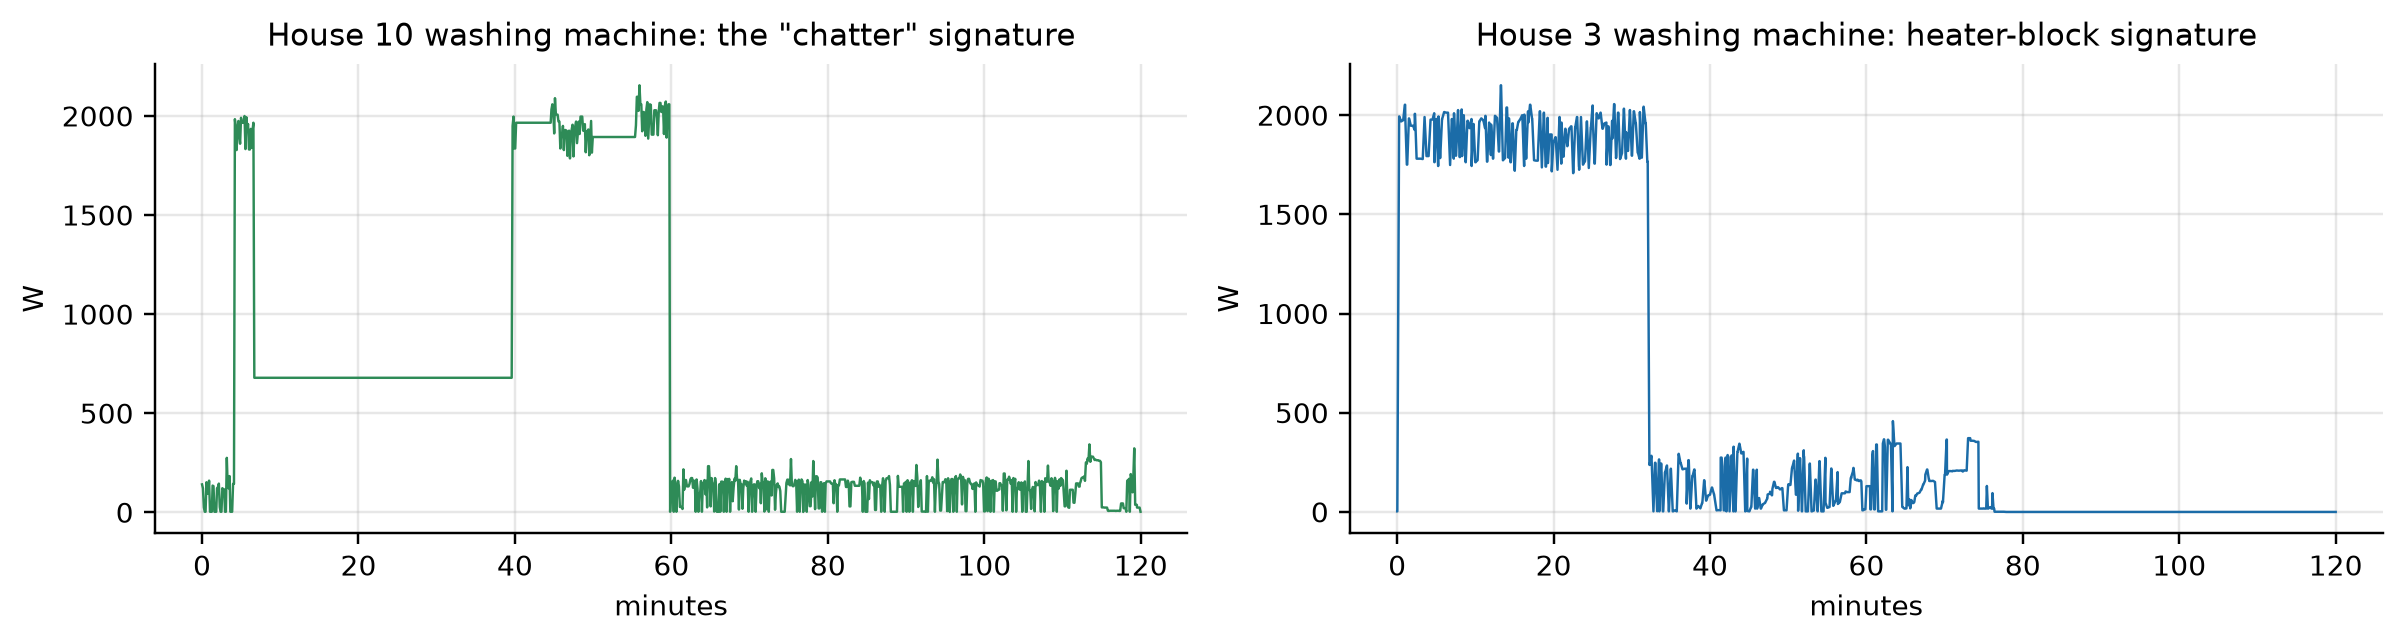

In [ ]:
# threshold transferability: fleet-median thr per canonical vs each channel's floor
_rows = []
for _cn in ['kettle', 'microwave', 'washing_machine', 'dishwasher']:
    thrs = [r['thr_on_w'] for h in canon_vals[_cn] for r in canon_vals[_cn][h]]
    _med = float(np.median(thrs))
    below = sum((1 for x in thrs if x < _med * 0.5))
    _rows.append([nice[_cn], '%d W' % _med, '%d / %d' % (below, len(thrs))])
c10 = PASS['chatter']['House10']
c3 = PASS['chatter']['House3']
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3))
_ax = _axes[0]
_ax.plot(c10['ts'], c10['v'], lw=0.8, color='#2e8b57')
_ax.set_title('House 10 washing machine: the "chatter" signature', fontsize=10)
_ax.set_xlabel('minutes')
_ax.set_ylabel('W')
_ax = _axes[1]
_ax.plot(c3['ts'], c3['v'], lw=0.8, color='#1b6ca8')
_ax.set_title('House 3 washing machine: heater-block signature', fontsize=10)
_ax.set_xlabel('minutes')
_ax.set_ylabel('W')
_fig.tight_layout()
print('H10 channel p50-on: %d W, %.1f episodes/day' % (PASS['cols_per_house']['House10']['Appliance5']['p50_on_w'], PASS['cols_per_house']['House10']['Appliance5']['eps_per_day']))
print('H3  channel p50-on: %d W, %.1f episodes/day' % (PASS['cols_per_house']['House3']['Appliance6']['p50_on_w'], PASS['cols_per_house']['House3']['Appliance6']['eps_per_day']))
mo.md(eda.md_table(['canonical', 'fleet-median ON threshold', 'channels with thr < half'], _rows))
_fig  # render figure as cell output

Reading it. The per-channel rule adapts to what each channel actually draws:
auto-thresholds run from ~54 W (pump-level dishwashers) to ~1.3 kW (kettles).
Within a type they cluster better than the p50-ON spread suggests - but a single
type-wide constant still fails quietly: 5 of 12 microwaves sit below half the
microwave median (standby-holding vs clean units; the stalled microwave channels
are already excluded, so this is the residual spread among healthy meters), and
even 2 of 15 dishwashers flip. The right figure pair shows the deeper reason:
house 10's machine is an older "chatterer" (dozens of short, low pulses per
cycle), house 3's is a modern heater-block machine (few long steps). Same
appliance, opposite shapes.

**[collectable]** Calibration per site, not per appliance type: when we deploy,
each Shelly channel should get its own ON threshold from a short observation
window (or the gold layer must store per-channel thresholds), because a
fleet-wide constant will silently drop the quiet phases of some machines.

## Q6 - Aggregate vs submeters: the built-in audit

Because rows are shared, we can compute, per house: what fraction of mains
energy the submeters explain (coverage), how correlated the two views are, and
what the residual looks like. Computed on "alive" rows only (not in a frozen
plateau, not flagged) so meter faults do not pollute the audit.

coverage range: House11 15.1% .. House18 52.6%
correlation range: 0.322 .. 0.946
residual mean range: 170 .. 548 W
solar-documented houses: H3, H11, H21
solar houses coverage: H3 41.0%, H11 15.1%, H21 27.7%
over the 17 non-solar houses: coverage 20.1% .. 52.6% (median 36.9%), corr 0.408 .. 0.946


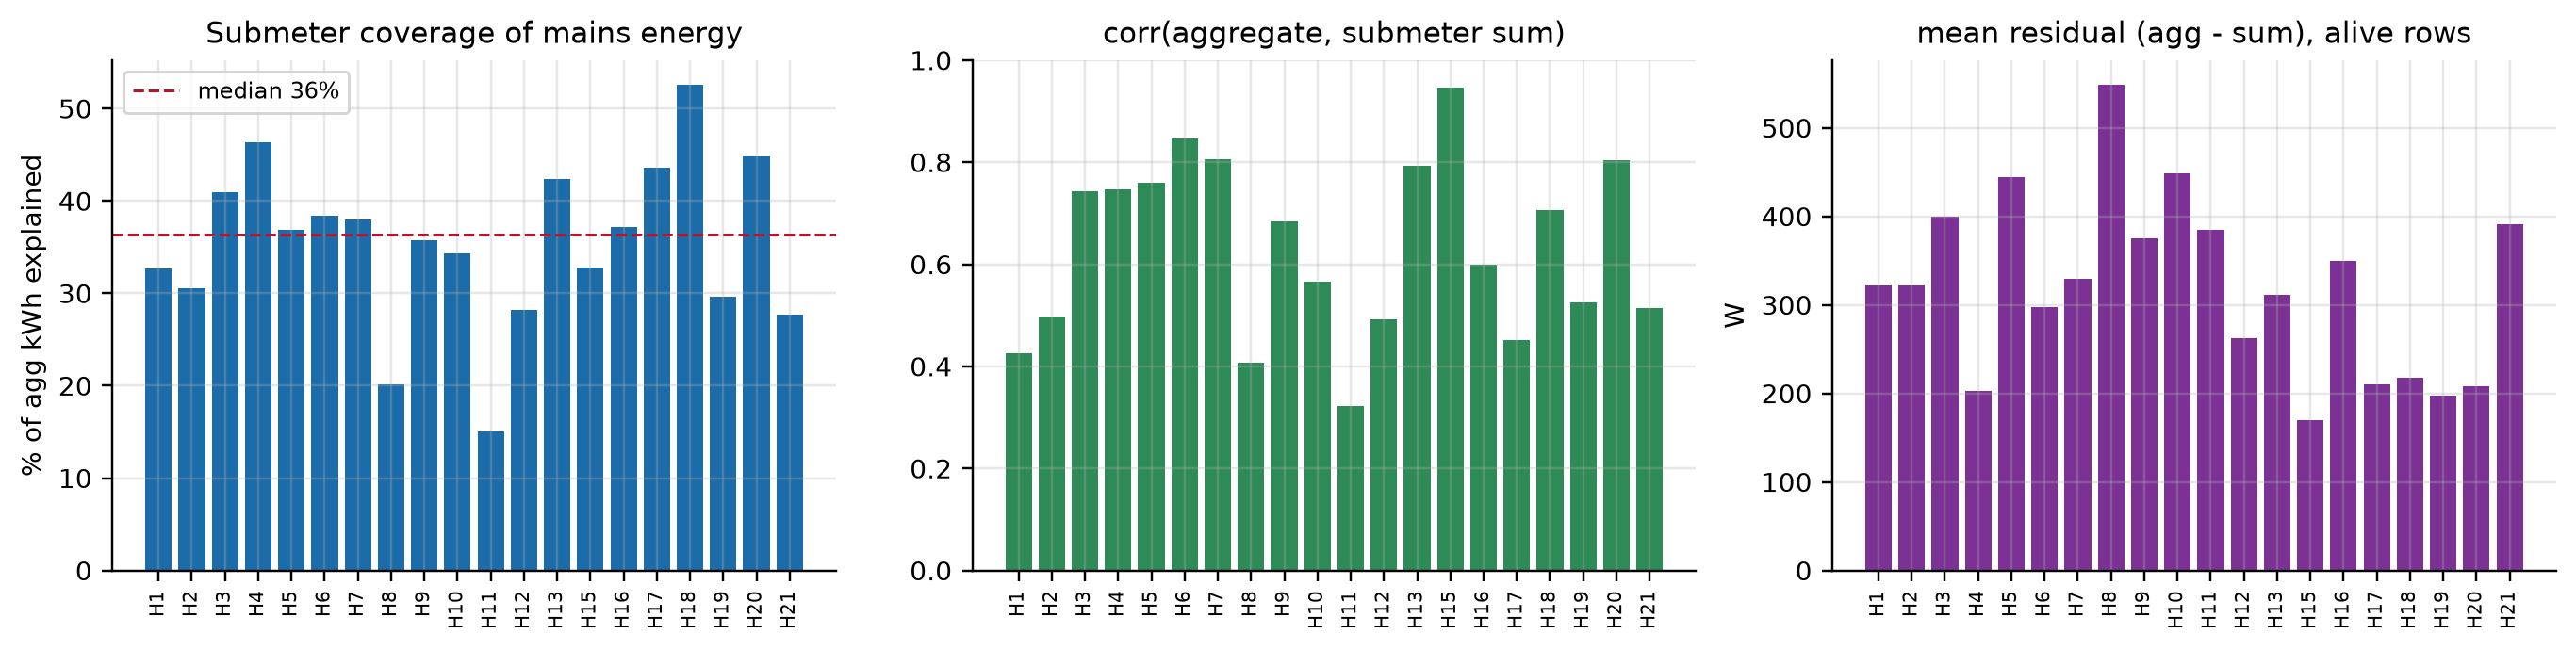

In [ ]:
hs = sorted(PASS['cov'], key=lambda x: int(x.replace('House', '')))
_fig, _axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
_ax = _axes[0]
_vals = [PASS['cov'][h]['cov_pct'] for h in hs]
_ax.bar(range(len(hs)), _vals, color='#1b6ca8')
_ax.axhline(float(np.median(_vals)), color='#b2182b', ls='--', lw=1, label='median %.0f%%' % float(np.median(_vals)))
_ax.set_xticks(range(len(hs)))
_ax.set_xticklabels([h.replace('House', 'H') for h in hs], fontsize=6.5, rotation=90)
_ax.set_ylabel('% of agg kWh explained')
_ax.set_title('Submeter coverage of mains energy', fontsize=10)
_ax.legend(fontsize=8)
_ax = _axes[1]
_vals = [PASS['cov'][h]['r'] for h in hs]
_ax.bar(range(len(hs)), _vals, color='#2e8b57')
_ax.set_xticks(range(len(hs)))
_ax.set_xticklabels([h.replace('House', 'H') for h in hs], fontsize=6.5, rotation=90)
_ax.set_ylim(0, 1)
_ax.set_title('corr(aggregate, submeter sum)', fontsize=10)
_ax = _axes[2]
_vals = [PASS['cov'][h]['res_mean_w'] for h in hs]
_ax.bar(range(len(hs)), _vals, color='#7b3294')
_ax.set_xticks(range(len(hs)))
_ax.set_xticklabels([h.replace('House', 'H') for h in hs], fontsize=6.5, rotation=90)
_ax.set_ylabel('W')
_ax.set_title('mean residual (agg - sum), alive rows', fontsize=10)
_fig.tight_layout()
lo = min(PASS['cov'], key=lambda h: PASS['cov'][h]['cov_pct'])
hi = max(PASS['cov'], key=lambda h: PASS['cov'][h]['cov_pct'])
print('coverage range: %s %.1f%% .. %s %.1f%%' % (lo, PASS['cov'][lo]['cov_pct'], hi, PASS['cov'][hi]['cov_pct']))
print('correlation range: %.3f .. %.3f' % (min((PASS['cov'][h]['r'] for h in hs)), max((PASS['cov'][h]['r'] for h in hs))))
print('residual mean range: %d .. %d W' % (min((PASS['cov'][h]['res_mean_w'] for h in hs)), max((PASS['cov'][h]['res_mean_w'] for h in hs))))
SOLAR_H = ('House3', 'House11', 'House21')
nons = [h for h in hs if h not in SOLAR_H]
print('solar-documented houses: %s' % ', '.join((h.replace('House', 'H') for h in SOLAR_H)))
print('solar houses coverage: %s' % ', '.join(('%s %.1f%%' % (h.replace('House', 'H'), PASS['cov'][h]['cov_pct']) for h in SOLAR_H)))
# houses 3, 11, 21 carry rooftop solar (release-documented): their aggregate is
# deflated by export, so their coverage bars are not comparable.
print('over the %d non-solar houses: coverage %.1f%% .. %.1f%% (median %.1f%%), corr %.3f .. %.3f' % (len(nons), min((PASS['cov'][h]['cov_pct'] for h in nons)), max((PASS['cov'][h]['cov_pct'] for h in nons)), float(np.median([PASS['cov'][h]['cov_pct'] for h in nons])), min((PASS['cov'][h]['r'] for h in nons)), max((PASS['cov'][h]['r'] for h in nons))))
_fig  # render figure as cell output

Reading it. Submeters explain only **15-53% of mains energy** (median ~36%) -
the gray band from Q2, quantified for every house. That is *by design*: nine
channels cannot cover dozens of appliances. The residual averages a few hundred
watts in every house (printed range above): that is the true unmonitored
background (lighting, oven, TV, standby). Correlation of the submeter sum with
the aggregate is 0.32-0.95 - even the best house agrees only loosely, because
the aggregate carries all the unmonitored load.

One systematic wrinkle, called out by the release: houses 3, 11 and 21 have
**rooftop solar**, and export deflates their aggregate on sunny days - their
coverage bars are not comparable with the rest. Over the 17 non-solar homes the
printed range is the honest one, and it is that set (not the solar homes) that
the fleet medians quoted elsewhere in this notebook describe.

**[collectable]** Two consequences for our project. First, NILM targets should be
framed against *appliance-level* ground truth, never against a claim that
submeters reproduce the mains - they never will with partial coverage. Second,
when we deploy, we should **meter the heavy appliances first** (heaters, dryers,
ovens): coverage of kWh, not of channel count, is what makes submeters useful.

across all houses: flagged rows are negative-residual 100% of the time; clean rows 0.0%


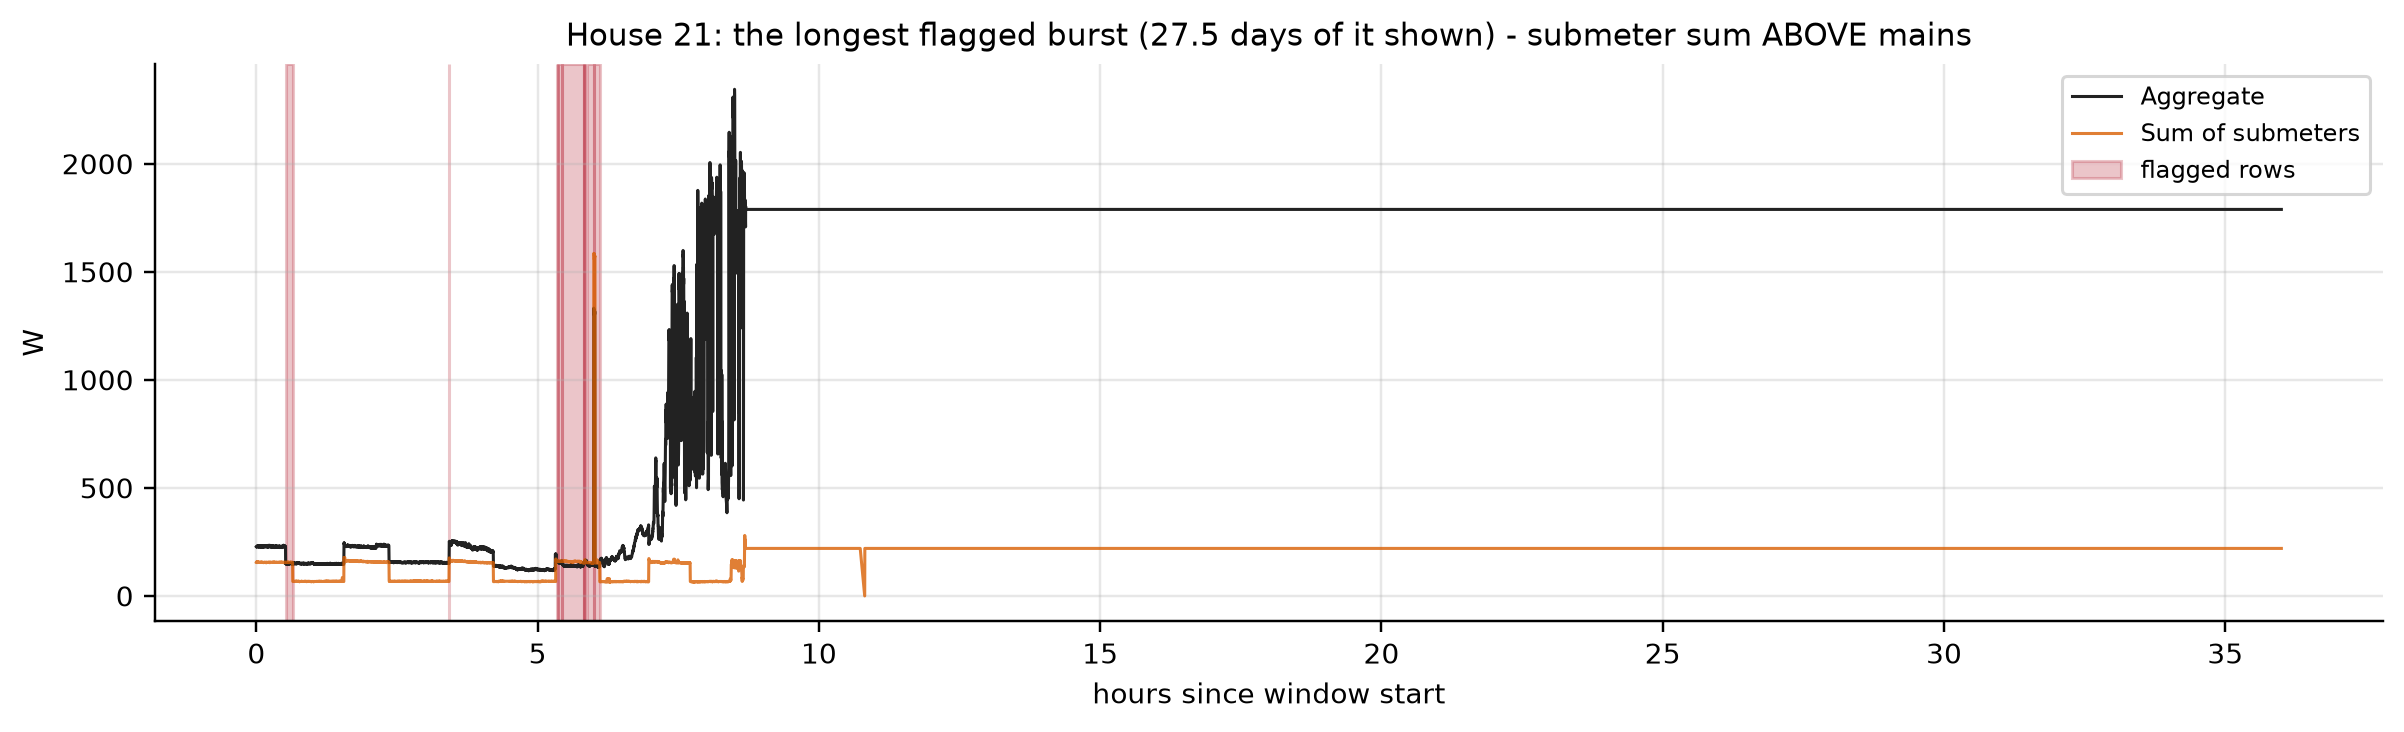

In [ ]:
hs2 = [h for h in hs if PASS['flag'][h]['neg_flag_pct'] is not None]
_rows = []
for _h in sorted(hs2, key=lambda x: -PASS['flag'][x]['n_flag'])[:8]:
    _f = PASS['flag'][_h]
    _rows.append([_h.replace('House', 'H'), eda.fmt_int(_f['n_flag']), '%.1f%%' % _f['neg_flag_pct'], '%.1f%%' % _f['neg_clean_pct']])
_sel = [h for h in hs if PASS['flag'][h]['neg_flag_pct'] is not None]
all_flag = [PASS['flag'][h]['neg_flag_pct'] for h in _sel]
all_clean = [PASS['flag'][h]['neg_clean_pct'] for h in hs]
print('across all houses: flagged rows are negative-residual %.0f%% of the time; clean rows %.1f%%' % (float(np.mean(all_flag)), float(np.mean(all_clean))))
_p = PASS['flag_zoom']
_fig, _ax = plt.subplots(figsize=(11, 3.4))
_ax.plot(_p['ts'], _p['agg'], color='#222222', lw=1.0, label='Aggregate')
_ax.plot(_p['ts'], _p['sub'], color='#d95f02', lw=1.0, alpha=0.8, label='Sum of submeters')
fm, tm = (_p['flag'], _p['ts'])
first = True
for _i in range(len(tm)):
    if fm[_i] and (_i == 0 or not fm[_i - 1]):
        _j = _i
        while _j < len(tm) and fm[_j]:
            _j = _j + 1
        _ax.axvspan(tm[_i], tm[_j - 1] if _j > _i else tm[_i], color='#b2182b', alpha=0.25, label='flagged rows' if first else None)
        first = False
_ax.set_xlabel('hours since window start')
_ax.set_ylabel('W')
_ax.set_title('House 21: the longest flagged burst (%.1f days of it shown) - submeter sum ABOVE mains' % (_p['burst_h'] / 24.0))
_ax.legend(fontsize=8)
_fig.tight_layout()
mo.md(eda.md_table(['house', 'flagged rows', 'residual < 0 among flagged', 'residual < 0 among clean'], _rows))
_fig  # render figure as cell output

Reading it. The Issues column decodes cleanly: **flagged rows are exactly the
rows where the submeter sum exceeds the aggregate** (the table shows ~100%
negative residual among flagged rows vs ~0% among clean rows, in every house
with flags). This is the release's *documented* definition, not our discovery -
the readme states the column "is set to 1 if the sum of the sub-metering (IAMs)
is greater than that of the household aggregate"; the pass verifies it holds on
every flagged row. The zoom makes it physical: during the flagged window the
orange line rides *above* the black one. That happens when the IAM meters capture
an appliance whose load the mains meter misses or under-registers - the release's
own documentation blames the IAMs (they can under- or over-report), but the
mechanism to record is simply "mains suspect here".

So Issues is not noise to discard - it is a *precomputed data-quality mask*, one
of the most useful columns in the release:

- **[insight only]** someone at the collection project already triaged every
  suspicious row; that annotation work is the part we cannot get for our own
  data.

- **[collectable]** the *trigger* is reproducible: raise a flag whenever
  |sum(sub) - mains| stays above a margin for M minutes. Our Shelly EM gives us
  both quantities on one clock, so this audit costs nothing to run continuously.

## Q7 - Sentinels, nulls, and impossible spikes

Two hygiene checks with very different outcomes.

In [ ]:
n_null = 0
_n_cols = 0
for _f in FILES:
    _mdf = pq.ParquetFile(_f).metadata
    for _rg in range(_mdf.num_row_groups):
        rgm = _mdf.row_group(_rg)
        for _ci in range(rgm.num_columns):
            _cc = rgm.column(_ci)
            nm = _cc.path_in_schema
            if nm.startswith('ts_'):
                continue
            _n_cols = _n_cols + 1
            if _cc.statistics is not None and _cc.statistics.null_count:
                n_null = n_null + _cc.statistics.null_count
print('measurement column-chunks scanned: %d' % _n_cols)
print('nulls in any measurement column: %d' % n_null)
mins = {}
for _h in PASS['sentinel']:
    mins.setdefault('Aggregate', []).append(PASS['sentinel'][_h]['agg_min'])
    mins.setdefault('appliances', []).append(PASS['sentinel'][_h]['app_min'])
for _k, _v in mins.items():
    print('%-10s min over whole fleet: %d' % (_k, min(_v)))
print('=> no -1 sentinel in the cleaned columns (that convention belongs to the raw release variant)')

measurement column-chunks scanned: 1353
nulls in any measurement column: 0
Aggregate  min over whole fleet: 0
appliances min over whole fleet: 0
=> no -1 sentinel in the cleaned columns (that convention belongs to the raw release variant)


UK single-phase ceiling is ~23 kW (100 A at 230 V); anything above is impossible.
fleet total readings > 11 kW: 38312  |  > 23 kW: 1851
House1 readings > 11 kW: 4273 | max reading: 29159 W


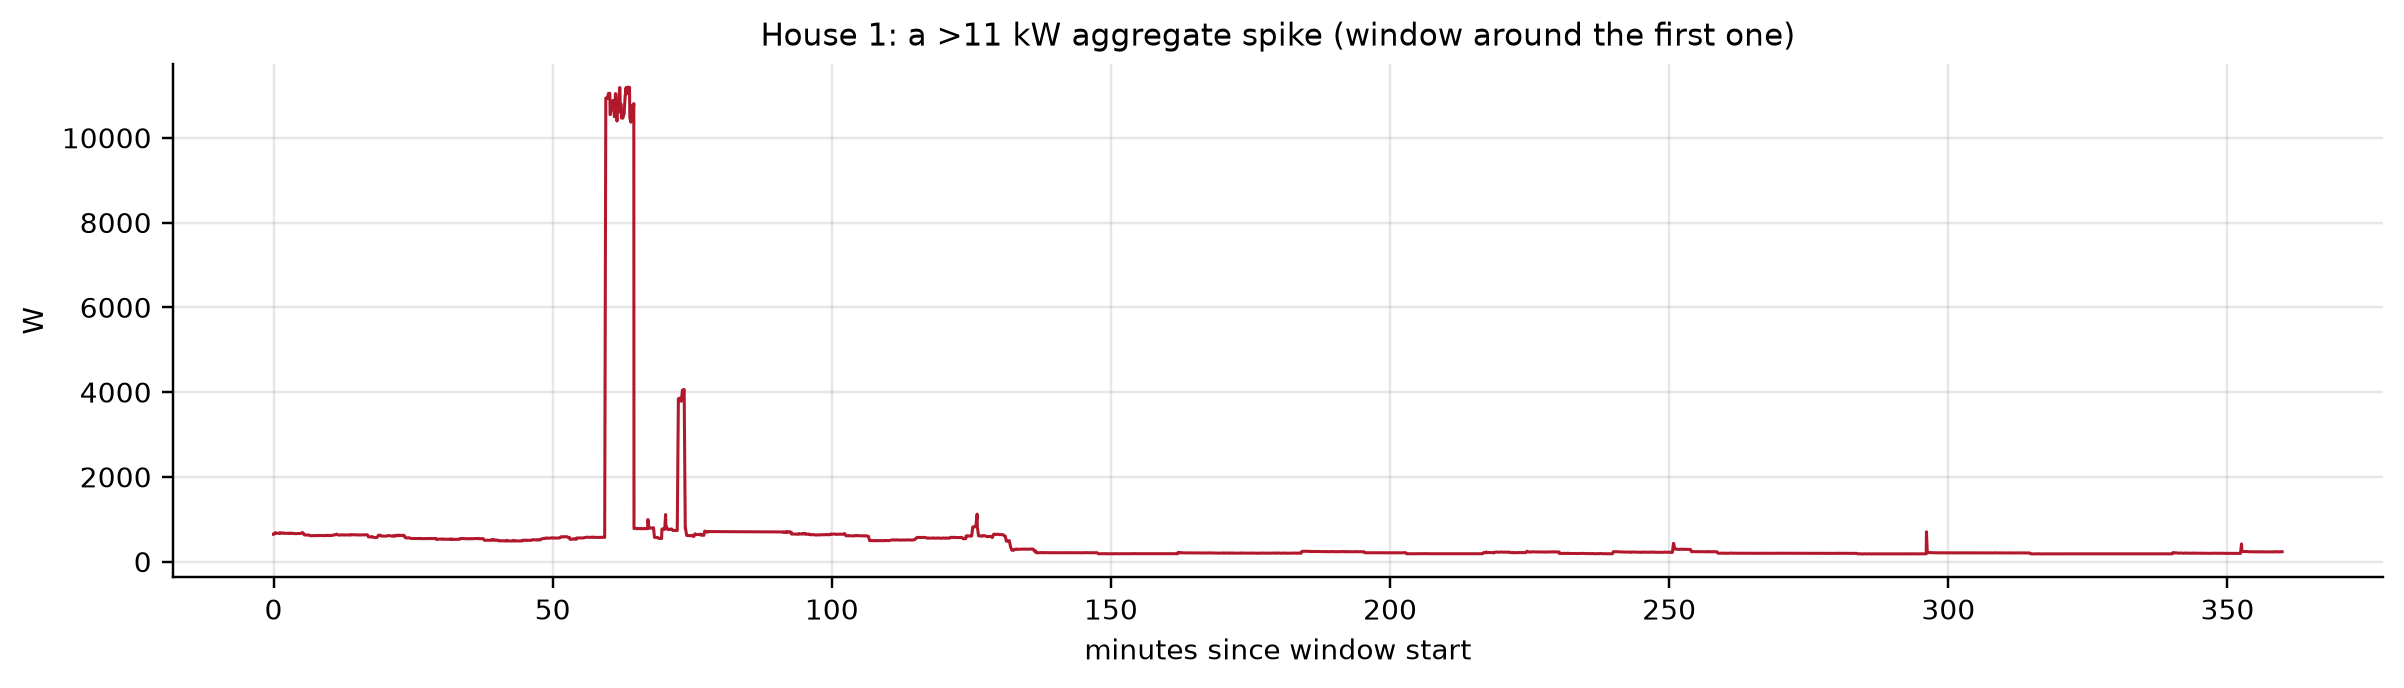

In [ ]:
hs_1 = sorted(PASS['spikes'], key=lambda h: -PASS['spikes'][h]['max_w'])
_rows = []
for _h in hs_1[:6]:
    _s = PASS['spikes'][_h]
    _rows.append([_h.replace('House', 'H'), eda.fmt_int(_s['gt11k']), eda.fmt_int(_s['gt23k']), eda.fmt_int(_s['max_w'])])
print('UK single-phase ceiling is ~23 kW (100 A at 230 V); anything above is impossible.')
print('fleet total readings > 11 kW: %d  |  > 23 kW: %d' % (sum((s['gt11k'] for s in PASS['spikes'].values())), sum((s['gt23k'] for s in PASS['spikes'].values()))))
s1 = PASS['spikes']['House1']
print('House1 readings > 11 kW: %d | max reading: %d W' % (s1['gt11k'], s1['max_w']))
if PASS['spike_zoom']:
    z = PASS['spike_zoom']
    _fig, _ax = plt.subplots(figsize=(11, 3.2))
    _ax.plot(z['ts'], z['agg'], lw=1.0, color='#b2182b')
    _ax.set_xlabel('minutes since window start')
    _ax.set_ylabel('W')
    _ax.set_title('House 1: a >11 kW aggregate spike (window around the first one)')
    _fig.tight_layout()
mo.md(eda.md_table(['house', 'readings > 11 kW', 'readings > 23 kW', 'max reading (W)'], _rows))
_fig  # render figure as cell output

In [ ]:
# IAM-side hygiene: the readme states IAM spikes > 4000 W were removed and replaced
# with zeros - so the ceiling is baked into this layer, and the zeros it left are visible.
print('IAM readings > 4000 W across the fleet: %d | fleet IAM max: %d W' % (PASS['iam']['gt4000'], round(PASS['iam']['max_w'])))
print('readme: "spikes of greater than 4000 Watts have been removed from the IAM values and replaced with zeros"')
_rows = []
for _h in sorted(PASS['cols_per_house'], key=lambda x: int(x.replace('House', ''))):
    _cols = PASS['cols_per_house'][_h]
    zb_tot = sum((r['zb'] for r in _cols.values()))
    if zb_tot:
        worst_col, worst_rec = max(_cols.items(), key=lambda kc: kc[1]['zb'])
        _rows.append([_h.replace('House', 'H'), zb_tot, worst_col.replace('Appliance', 'ap'), worst_rec['zb'], worst_rec['label']])
print('fleet: single-sample 0 W readings between two > 200 W neighbours: %d' % PASS['iam']['zb_total'])
fam = {}
for _h, _cols in PASS['cols_per_house'].items():
    for _col, _rec in _cols.items():
        _cn = _rec.get('canonical') or ('tumble_dryer' if 'tumble' in _rec['label'].lower() else None)
        if _cn:
            fam[_cn] = fam.get(_cn, 0) + (1 if _rec['vmax'] > 3000 else 0)
print('channels whose max exceeds 3000 W, by family:', fam)
mo.md(eda.md_table(['house', 'zero-blips', 'worst col', 'in that col', 'label'], _rows))

IAM readings > 4000 W across the fleet: 0 | fleet IAM max: 3975 W
readme: "spikes of greater than 4000 Watts have been removed from the IAM values and replaced with zeros"
fleet: single-sample 0 W readings between two > 200 W neighbours: 961
channels whose max exceeds 3000 W, by family: {'fridge': 16, 'washing_machine': 15, 'dishwasher': 11, 'microwave': 11, 'kettle': 10, 'tumble_dryer': 4}


| house | zero-blips | worst col | in that col | label |
| --- | --- | --- | --- | --- |
| H1 | 5 | ap1 | 2 | Fridge |
| H2 | 10 | ap5 | 5 | Microwave |
| H3 | 17 | ap4 | 8 | Tumble Dryer |
| H4 | 4 | ap2 | 1 | Freezer |
| H5 | 26 | ap2 | 22 | Tumble Dryer |
| H6 | 72 | ap8 | 28 | Toaster |
| H7 | 8 | ap4 | 4 | Tumble Dryer |
| H8 | 15 | ap3 | 6 | Washer Dryer |
| H9 | 30 | ap1 | 12 | Fridge-Freezer |
| H10 | 23 | ap6 | 12 | Dishwasher |
| H11 | 20 | ap3 | 14 | Washing Machine |
| H12 | 16 | ap4 | 8 | Computer Site |
| H13 | 10 | ap5 | 4 | ??? |
| H15 | 10 | ap8 | 8 | Hi-Fi |
| H16 | 35 | ap8 | 27 | Television Site |
| H17 | 11 | ap8 | 8 | Kettle |
| H18 | 22 | ap2 | 16 | Freezer(garage) |
| H19 | 615 | ap7 | 588 | Bread-maker |
| H20 | 5 | ap9 | 3 | Kettle |
| H21 | 7 | ap7 | 6 | Kettle |

Reading it. Hygiene: the cleaned columns are **null-free and sentinel-free** -
no -1 placeholders anywhere (the -1 convention belongs to the raw Processed
variant of REFIT, not this cleaned export). Spikes are the opposite story:
house 1 alone has thousands of readings above 11 kW, including values far beyond
the ~23 kW ceiling of a UK single-phase supply, and the zoom shows the
character - a plausible-looking 4 kW household that suddenly spikes to
impossible levels for a few samples. These are meter glitches, not load.

The IAM side looks clean by construction, and that is itself a finding: the
release states IAM readings above 4000 W were *removed and replaced with zeros*,
and the fleet max (3,975 W) confirms the ceiling was applied. The table above
shows the residue of that policy - hundreds of single-sample 0 W readings wedged
between two > 200 W neighbours. A real OFF transition does not look like that;
these are excision scars, and the release's descriptor puts the IAM error bound
at 0.004% of readings. They are rare, but they fabricate plausible OFF states,
so any episode-splitting logic should heal single-sample zeros between strong
neighbours before segmenting.

**[collectable]** A simple plausibility gate at ingest: for a 100 A service,
flag any sample above ~20 kW (and any sample more than 10x the trailing median).
This dataset shows why the gate must exist - thousands of bad rows survive into
a "clean" release and every one of them corrupts training labels it touches.

## Q8 - How long can we trust a continuous stretch?

The recording is interrupted. Question: what is the longest stretch with no gap
longer than a minute, per house - and what do the outages look like?

houses with ANY 30-day gap-free stretch: 0 of 20
best stretch: House9 22.1 days
H2 loses Nov 2013 and Jan 2014 entirely - monthly kWh table:


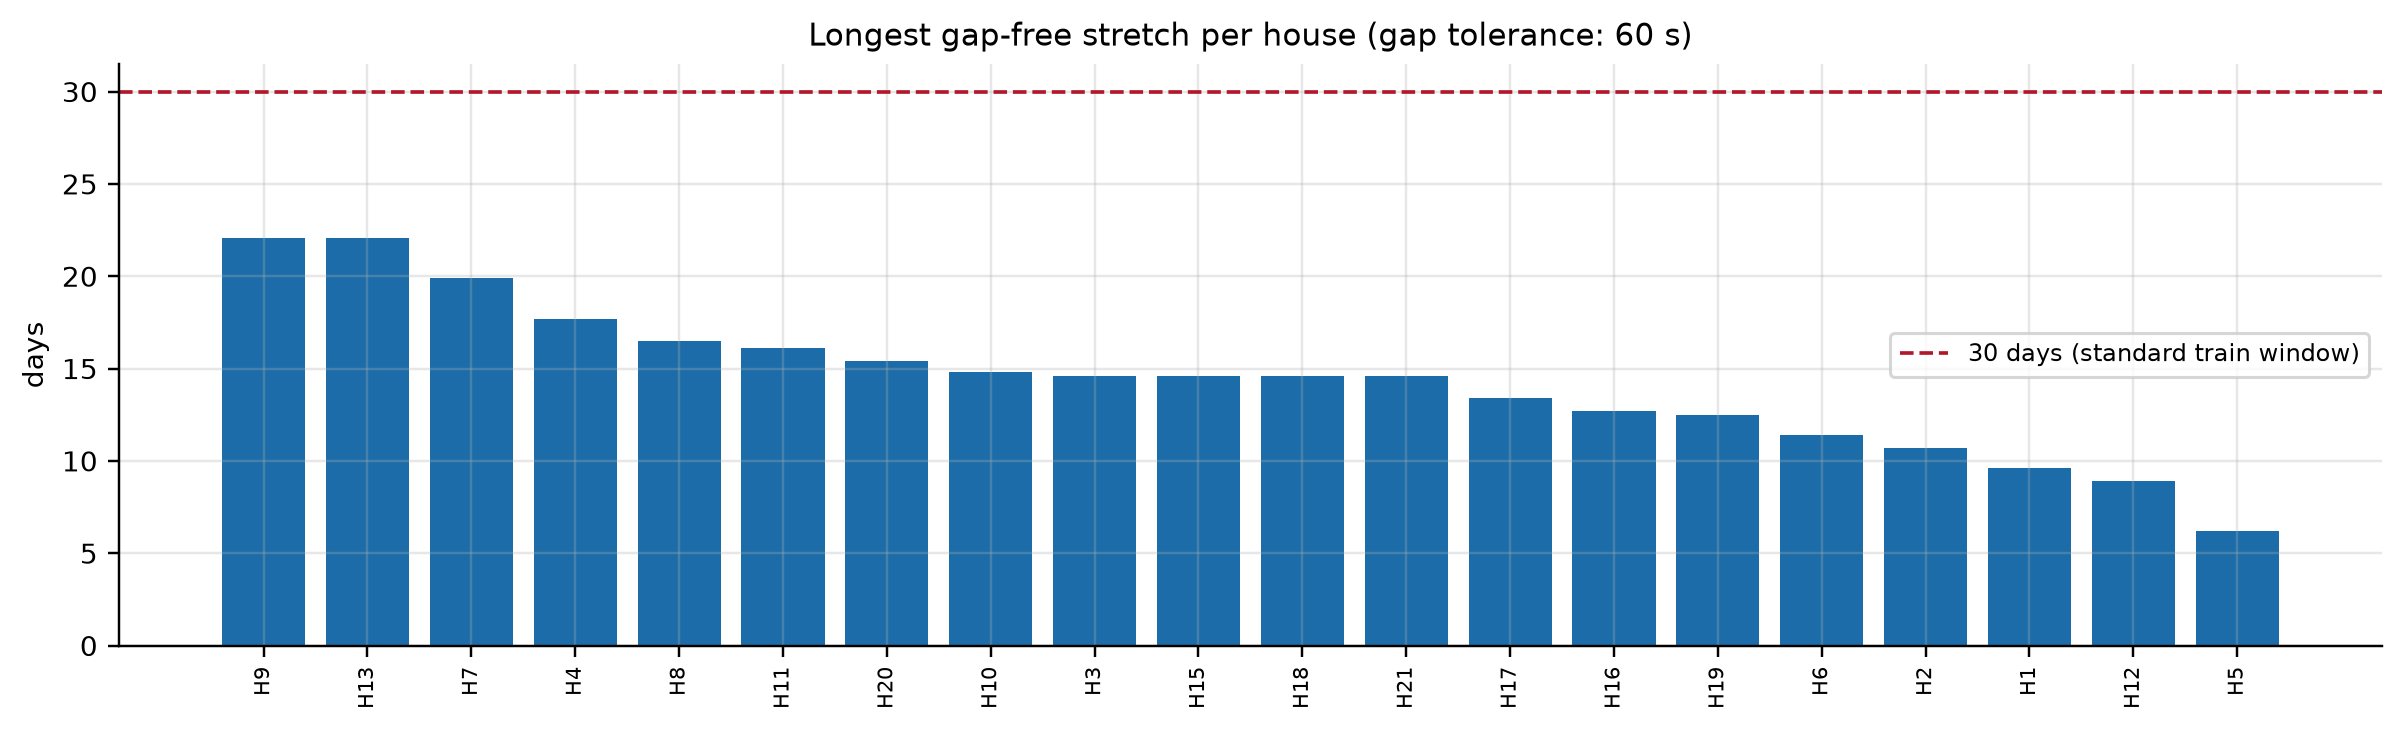

In [ ]:
hs_2 = sorted(PASS['chunk'], key=lambda h: -PASS['chunk'][h]['longest'])
_fig, _ax = plt.subplots(figsize=(11, 3.4))
_vals = [PASS['chunk'][h]['longest'] for h in hs_2]
_ax.bar(range(len(hs_2)), _vals, color='#1b6ca8')
_ax.axhline(30, color='#b2182b', ls='--', lw=1.2, label='30 days (standard train window)')
_ax.set_xticks(range(len(hs_2)))
_ax.set_xticklabels([h.replace('House', 'H') for h in hs_2], fontsize=7, rotation=90)
_ax.set_ylabel('days')
_ax.set_title('Longest gap-free stretch per house (gap tolerance: 60 s)')
_ax.legend(fontsize=8)
_fig.tight_layout()
n_ok = sum((1 for h in hs_2 if PASS['chunk'][h]['n30'] > 0))
print('houses with ANY 30-day gap-free stretch: %d of %d' % (n_ok, len(hs_2)))
print('best stretch: %s %.1f days' % (hs_2[0], PASS['chunk'][hs_2[0]]['longest']))
print('H2 loses Nov 2013 and Jan 2014 entirely - monthly kWh table:')
m2 = PASS['monthly']['House2']
_keep = [(k, v) for k, v in zip(m2['keys'], m2['agg']) if k in ('201310', '201311', '201312', '201401', '201402')]
mo.md(eda.md_table(['month', 'agg kWh'], [[k, '%.1f' % v] for k, v in _keep]))
_fig  # render figure as cell output

Reading it. **Not a single house offers a contiguous 30-day recording** - the
best is 22.1 days (house 9), and several homes top out near a week. House 2
loses November 2013 and January 2014 wholesale (its December shows 1.4 kWh - a
one-day fragment). For anyone planning "train on 30-day windows", REFIT answers:
you cannot; you will train on shorter, gap-aware windows.

**[collectable]** This is an argument for *dense, self-contained* collection in
our deployment: our Shelly EM records continuously to its own local storage
independent of any server, so multi-week outages are a design failure we can
avoid - REFIT's outages came from a laptop-based logger setup.

### The reward for surviving 1.5 years: seasonality

With this much span, seasonal structure shows up. Two houses tell the story:
house 2 (gas-heated home) and house 16 (electrically heated, but see the
caveat below - the metered 'heater' channel is not the whole story).

H2: winter months mean 287 kWh vs summer 245 kWh
H16: winter months mean 345 kWh vs summer 206 kWh


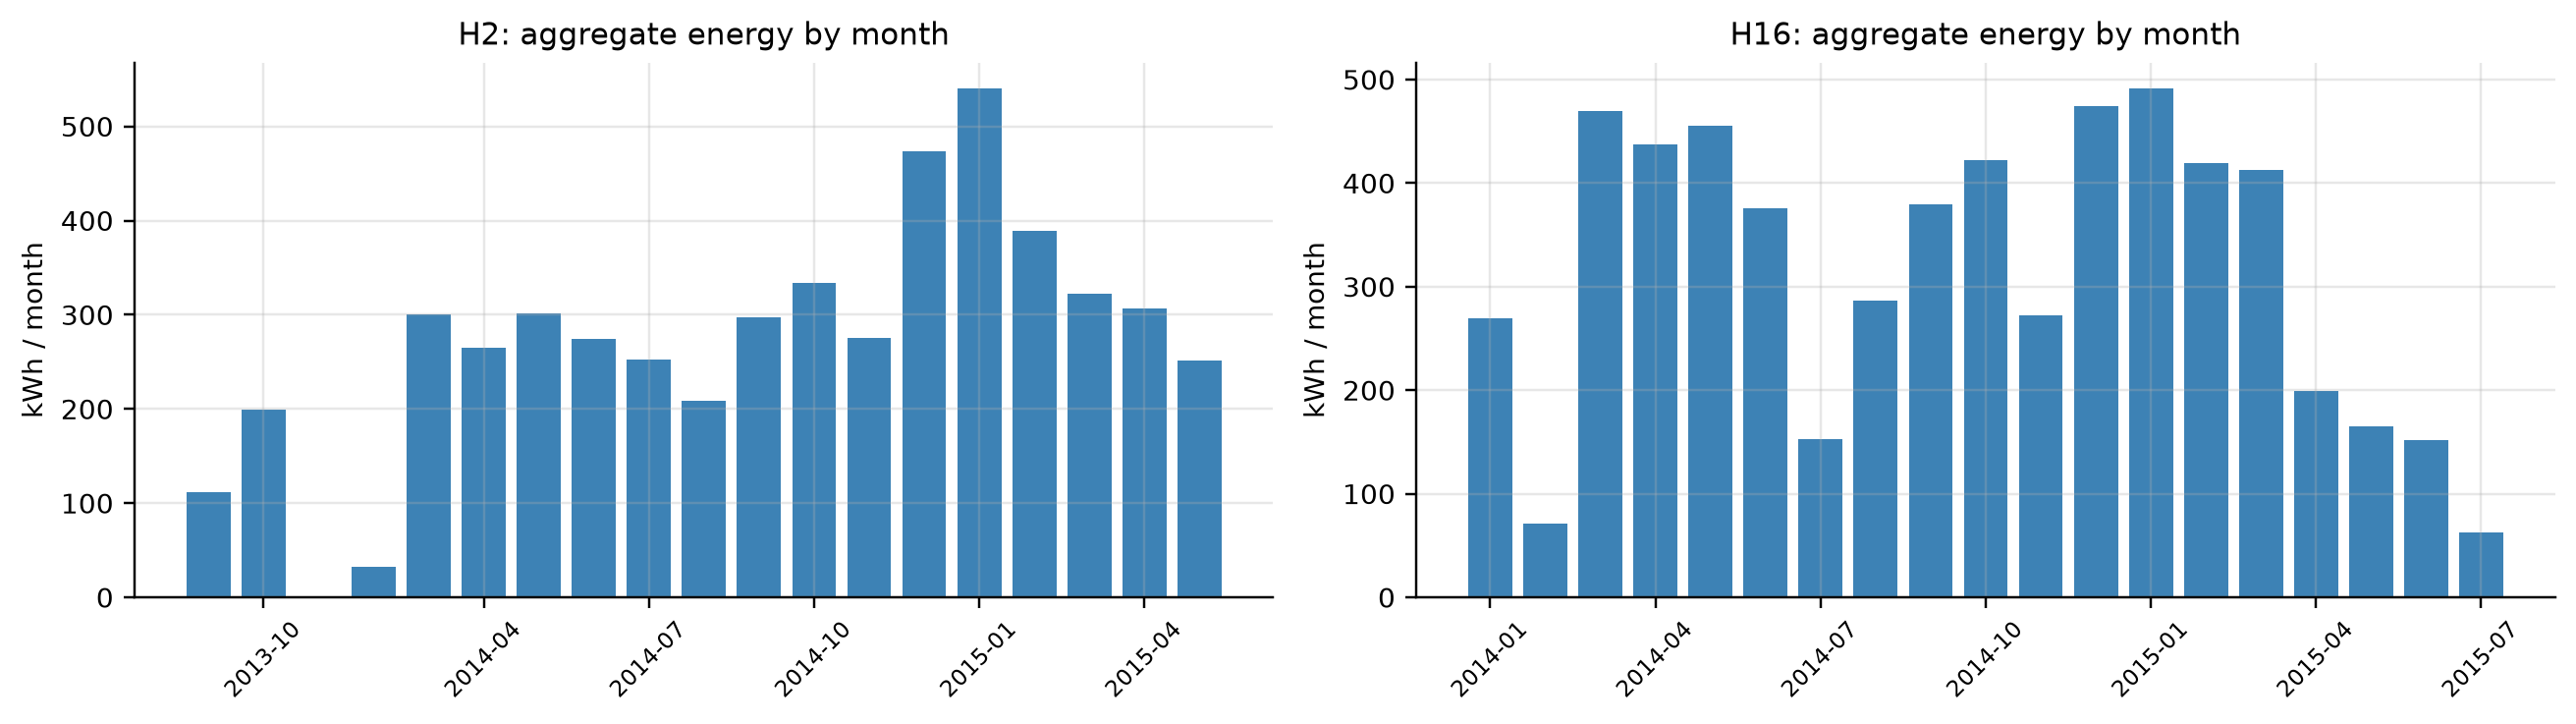

In [ ]:
_fig, _axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=False)
for _ax, _h in zip(_axes, ['House2', 'House16']):
    _m = PASS['monthly'][_h]
    keys = _m['keys']
    xs = np.arange(len(keys))
    _ax.bar(xs, _m['agg'], color='#1b6ca8', alpha=0.85)
    tick = [k for k in keys if k.endswith(('01', '04', '07', '10'))]
    tick_x = [keys.index(k) for k in tick]
    _ax.set_xticks(tick_x)
    _ax.set_xticklabels(['%s-%s' % (k[:4], k[4:]) for k in tick], rotation=45, fontsize=7.5)
    _ax.set_ylabel('kWh / month')
    _ax.set_title('%s: aggregate energy by month' % _h.replace('House', 'H'), fontsize=10)
_fig.tight_layout()
for _h in ['House2', 'House16']:
    _m = PASS['monthly'][_h]
    winter = [v for k, v in zip(_m['keys'], _m['agg']) if k[4:] in ('12', '01', '02')]
    summer = [v for k, v in zip(_m['keys'], _m['agg']) if k[4:] in ('06', '07', '08')]
    print('%s: winter months mean %.0f kWh vs summer %.0f kWh' % (_h.replace('House', 'H'), float(np.mean(winter)), float(np.mean(summer))))
_fig  # render figure as cell output

Reading it. Both houses peak in December-January and sag in summer, but for
different reasons: house 16's winter months average ~1.7x its summer ones -
yet its metered "Electric Heater" channel is nearly unused (a trace channel
in our Q4 audit), so the extra winter energy must flow through unmonitored
circuits or unlabeled channels. Aggregate seasonality alone cannot tell you
*which* appliance moved; you need the submeters, and you need them labeled
truthfully. House 2's winter bump is smaller (gas central heating, but winter
lighting and electric extras still push the aggregate up ~1.2x). Cold-chain
loads behave in the *opposite* direction - fridges work harder in summer.

**[insight only]** Any model that sees one season must be told there are others:
a December-trained prior ("high baseload") misfires in July, and a
fridge-detection model tuned in winter under-detects summer compressor duty.
Our deployment spans years; the gold layer should tag season explicitly.

## Q9 - The signature gallery

Twelve channels, chosen to span the fleet's variety: the five canonical types,
the extra REFIT types (tumble dryer, electric heater), the household oddities
(vivarium heater, pond pump), and the two suspect labels from Q4. Each shows the
highest-energy window of the stated length, raw 7-second samples, plateaus
removed. This is the section to linger on: these are the shapes a NILM model
must tell apart.


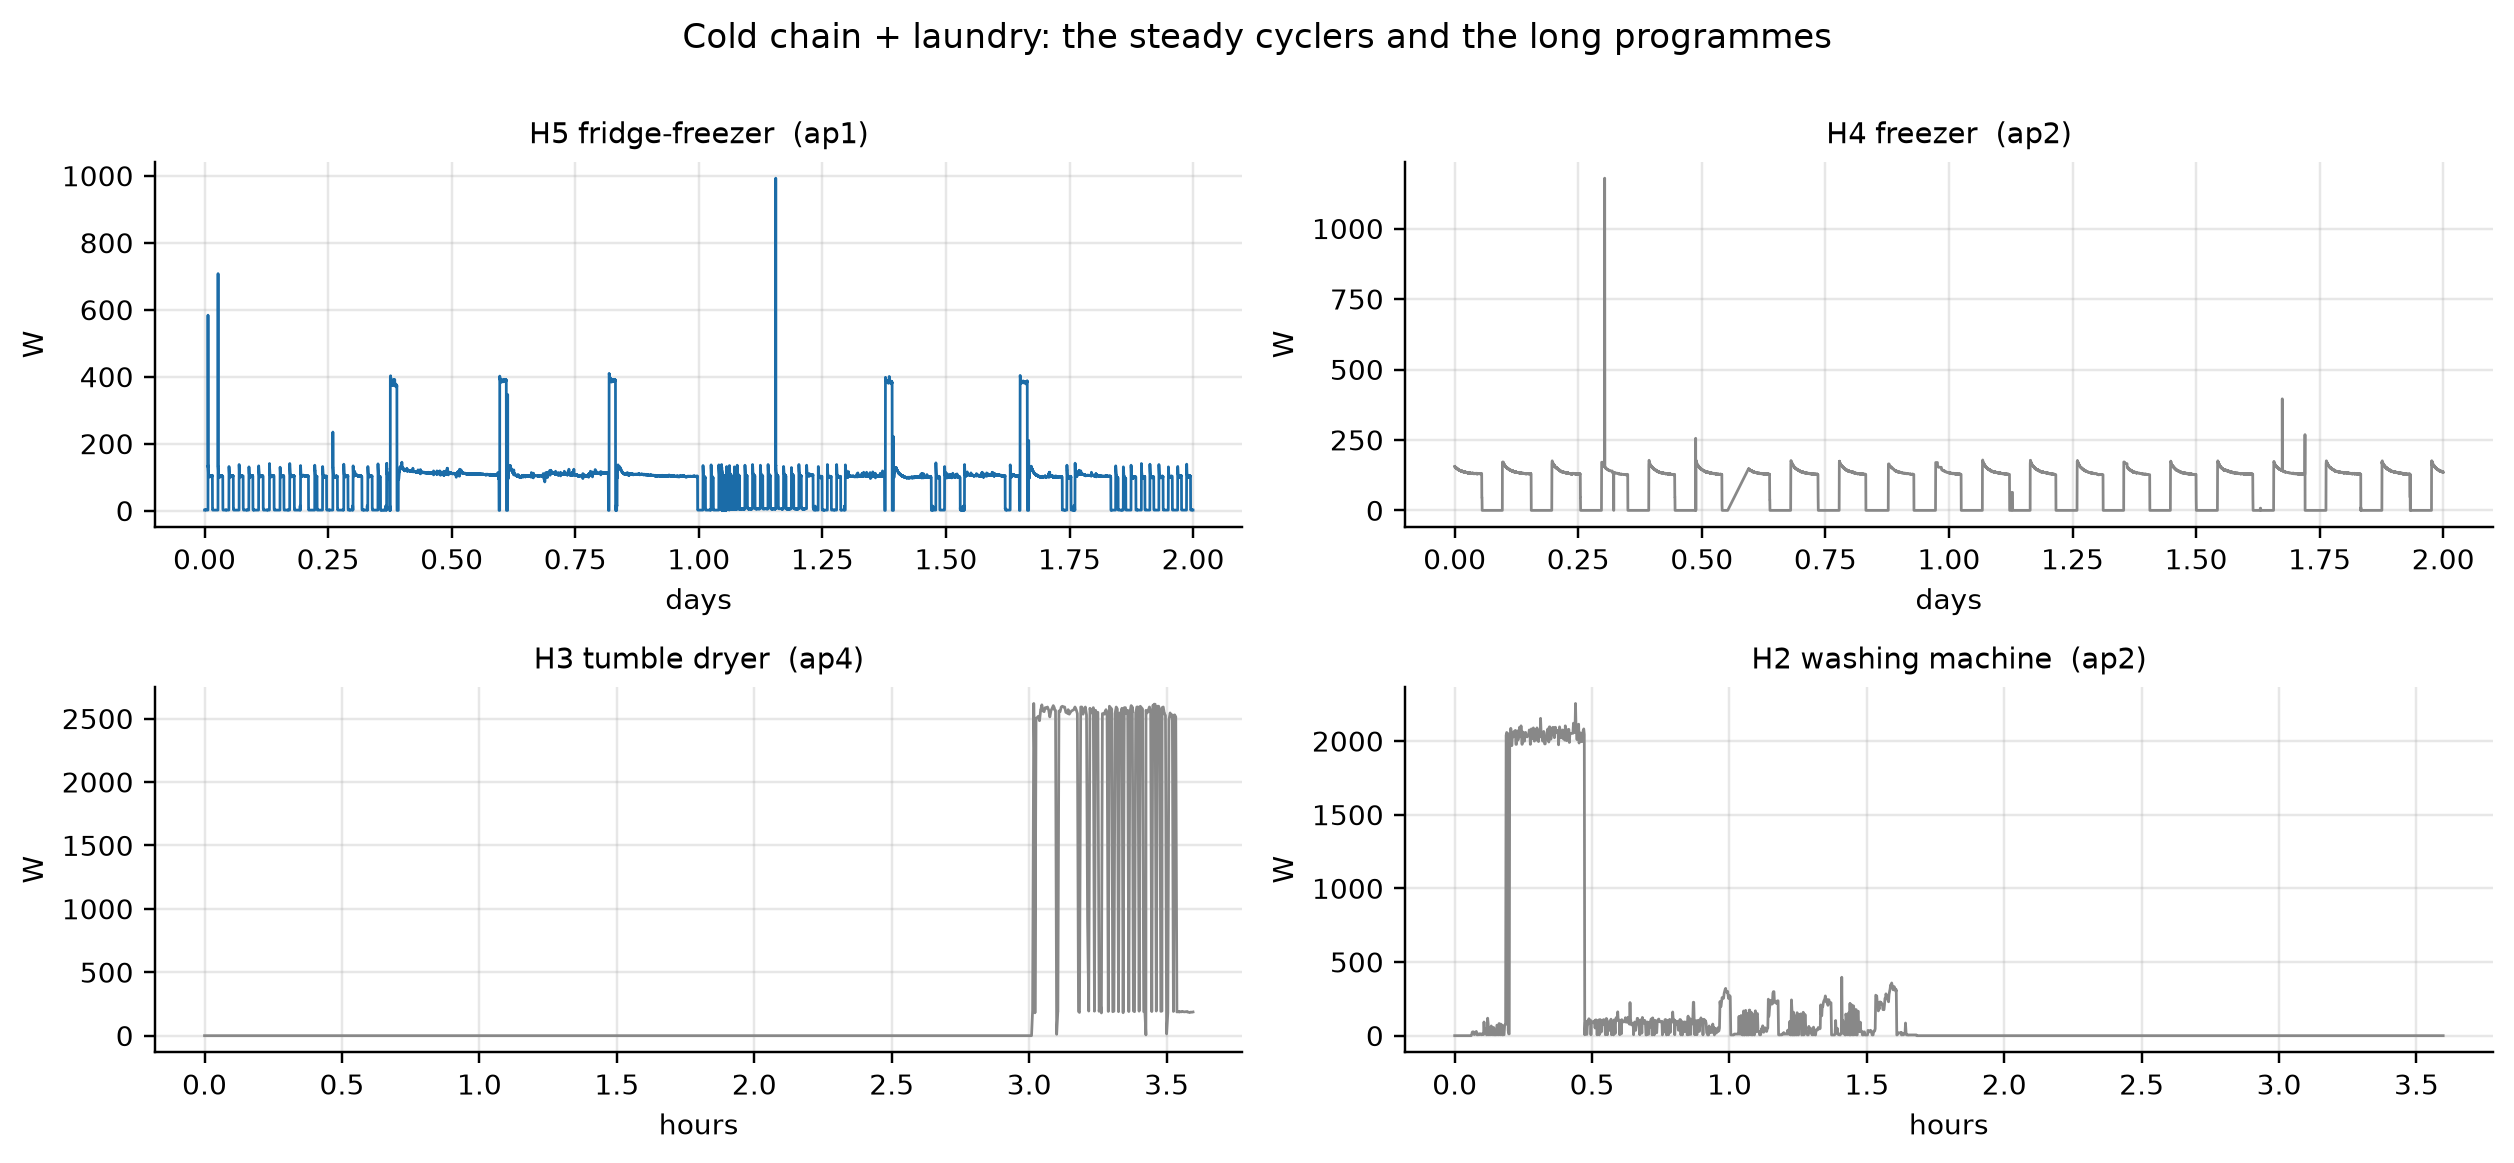

In [ ]:
def draw_gallery(picks, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 5.2))
    for ax, (h, col) in zip(axes.ravel(), picks):
        g = PASS['gallery'][(h, col)]
        tt = g['t']
        unit = 'days' if g['days'] >= 1 else ('hours' if g['days'] >= 0.05 else 'minutes')
        ax.plot(tt / (86400.0 if unit == 'days' else (3600.0 if unit == 'hours' else 60.0)),
                g['v'], lw=0.9, color=eda.canon_color(g['title']))
        ax.set_xlabel(unit)
        ax.set_ylabel('W')
        ax.set_title(g['title'] + '  (%s)' % col.replace('Appliance', 'ap'), fontsize=9.5)
    fig.suptitle(suptitle, fontsize=11, y=1.005)
    fig.tight_layout()
    return fig

_figs = []
_figs.append(draw_gallery([('House5', 'Appliance1'), ('House4', 'Appliance2'),
              ('House3', 'Appliance4'), ('House2', 'Appliance2')],
             'Cold chain + laundry: the steady cyclers and the long programmes'))
mo.vstack(_figs)  # render figure as cell output

Reading it. The fridge and freezer compressors show the classic sawtooth: short
ON bursts with silent OFF gaps, at 7-second resolution clean enough to count
cycles. House 3's tumble dryer is the opposite - a violent step pattern with a
big resistive element cycling between ~0 and 2.5-3 kW for an hour at a time, the
single highest-power flexible appliance in most homes. House 2's washing machine
shows the full programme anatomy: a 2 kW heater block, then the long quiet
agitate with spin bursts.

**[collectable]** Tumble dryers are the biggest shiftable load in UK homes and
REFIT tracks them in 7 houses. For our stack, "dryer running" is among the most
valuable single detections (cost, safety, scheduling) - and its 2-3 kW signature
makes it one of the easiest to detect from the aggregate alone.


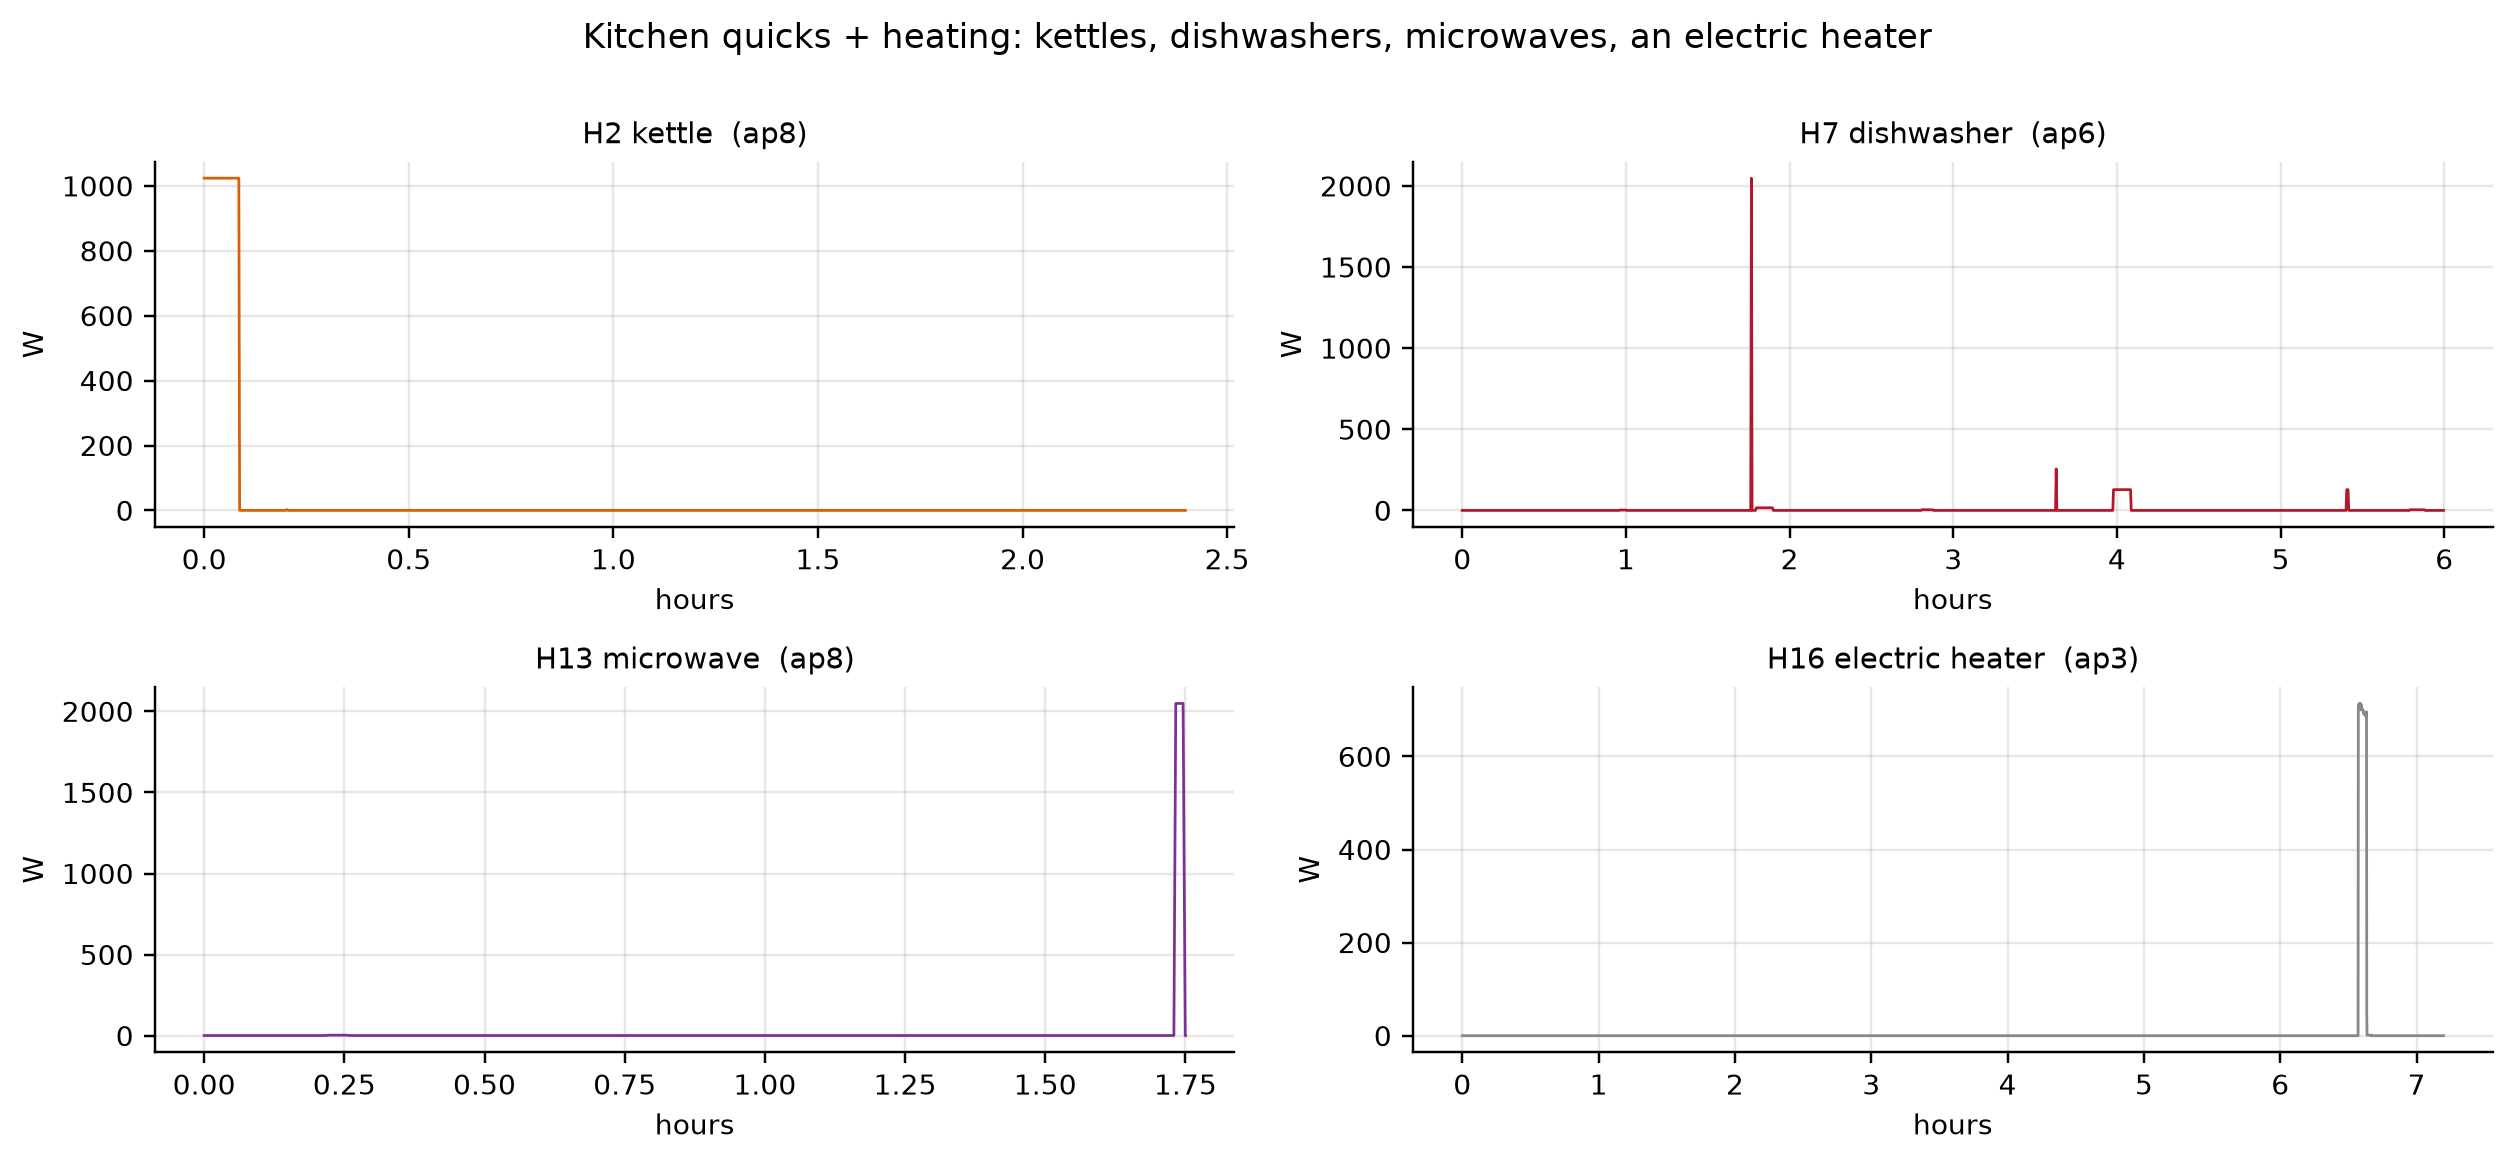

In [ ]:
_figs = []
_figs.append(draw_gallery([('House2', 'Appliance8'), ('House7', 'Appliance6'),
              ('House13', 'Appliance8'), ('House16', 'Appliance3')],
             'Kitchen quicks + heating: kettles, dishwashers, microwaves, an electric heater'))
mo.vstack(_figs)

Reading it. The kettle: one boil per use - house 2's element runs ~1 kW for
several minutes (fleet p50-ON is ~2.6 kW; element size and fill volume vary by
home). The dishwasher is a *sequence* - intake pump, heater block, drain -
visible as distinct power levels across a 1-3 hour programme. The microwave is
the cleanest step in the whole dataset: 0 to ~2 kW the moment it starts, flat
while cooking, 0 the moment it stops. House 16's "electric heater", by
contrast, is a trace channel: its biggest window in 1.5 years is one short
~700 W step - the label promises far more than the data delivers (Q4).

**[insight only]** Kettles and microwaves are the "easy" classes for NILM;
dishwashers teach that some appliances are *programmes*, not events - the model
must recognize the sequence, not the step.


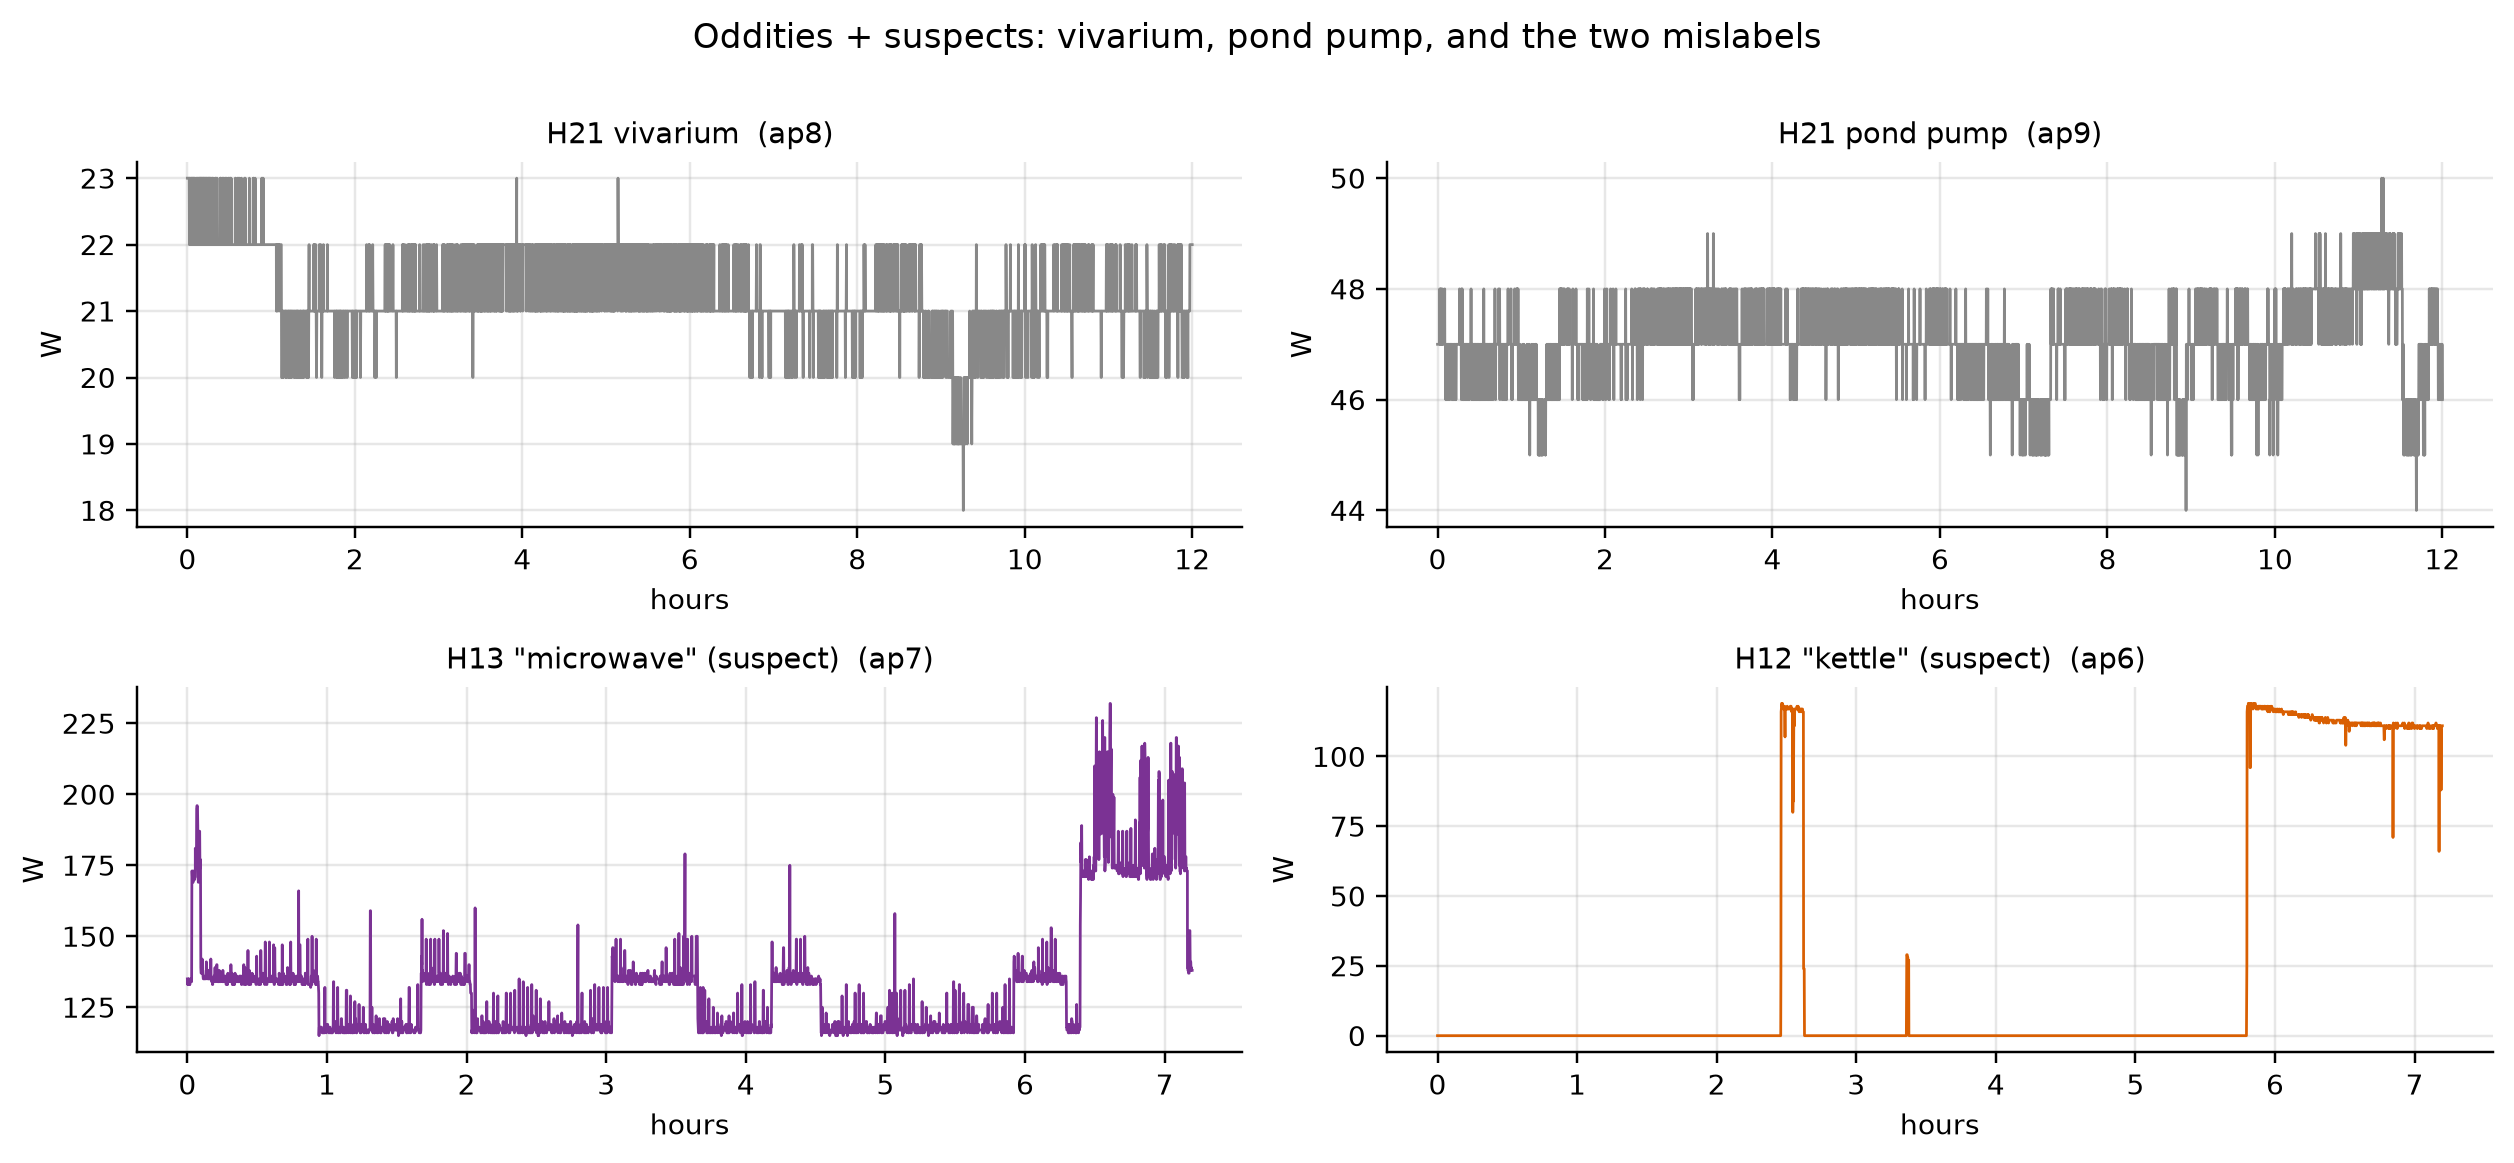

In [ ]:
_figs = []
_figs.append(draw_gallery([('House21', 'Appliance8'), ('House21', 'Appliance9'),
              ('House13', 'Appliance7'), ('House12', 'Appliance6')],
             'Oddities + suspects: vivarium, pond pump, and the two mislabels'))
mo.vstack(_figs)

Reading it. The oddities are the fun half of REFIT: house 21 meters a
**vivarium** (reptile enclosure) with its own heater/light cycle and a **pond
pump** - both are round-the-clock loads a home owner would never guess are their
top-ten consumers. Then the suspects, confirmed by eye: house 13's "Microwave"
(ap7) shows a continuous low compressor-like trace - microwaves never idle at
tens of watts for days - so this label is wrong (its housemate ap8, in the
kitchen panel above, is the real microwave). House 12's "Kettle" idles around
100 W and never shows a 2-3 kW boil: also mislabeled.

**[collectable]** Our label audit must be *visual + statistical*, not just a
name mapping: the two suspects here were caught by p50-ON and duty (Q4) and
confirmed by signature (here). In our own deployment this is a 10-minute
commissioning step per channel.

## Q10 - Behaviour: when appliances wake up

Pooling every ON-episode of every house (approximate UK local hour, UTC+1):
when do the canonical types start, on weekdays vs weekends?

channels pooled per type: {'kettle': 15, 'fridge': 35, 'microwave': 17, 'washing_machine': 24, 'dishwasher': 15}


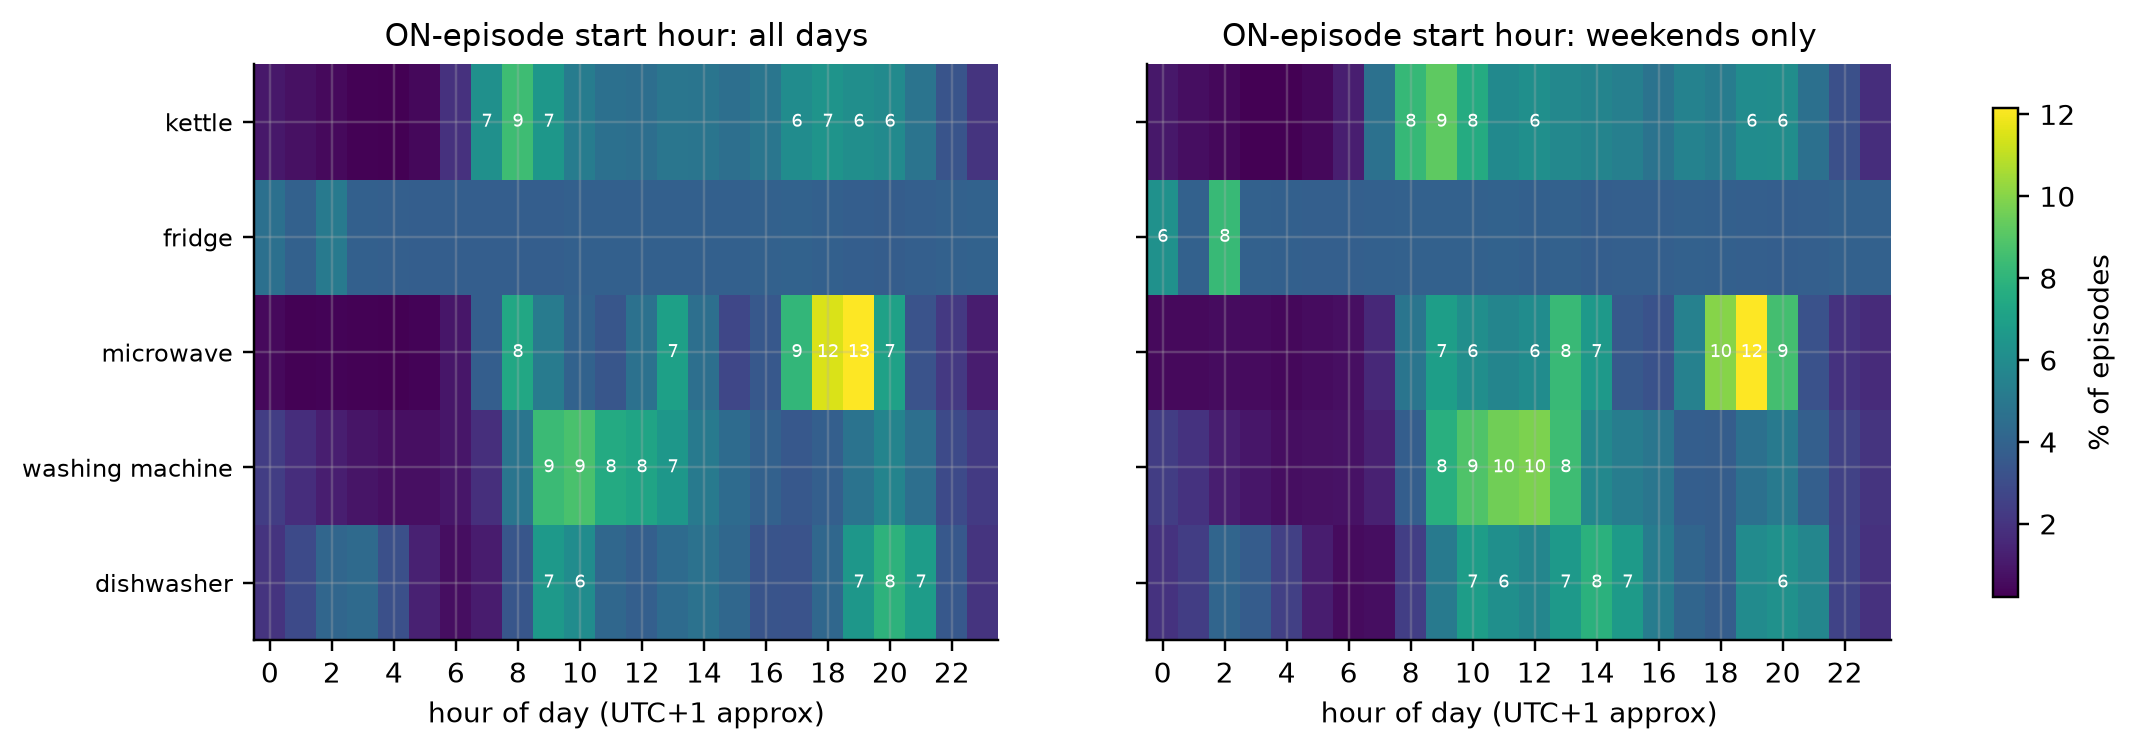

In [ ]:
_AXH = 'hour of day (UTC+1 approx)'
_order = [c for c in ['kettle', 'fridge', 'microwave', 'washing_machine', 'dishwasher'] if c in PASS['onset']]
_fig, _axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for _ax, _key, ttl in [(_axes[0], 'h24', 'all days'), (_axes[1], 'wk', 'weekends only')]:
    _mat = np.array([PASS['onset'][c][_key] / max(PASS['onset'][c][_key].sum(), 1) * 100 for c in _order])
    _im = _ax.imshow(_mat, aspect='auto', cmap='viridis')
    _ax.set_yticks(range(len(_order)))
    _ax.set_yticklabels([c.replace('_', ' ') for c in _order], fontsize=8)
    _ax.set_xticks(range(0, 24, 2))
    _ax.set_xlabel(_AXH)
    _ax.set_title('ON-episode start hour: %s' % ttl, fontsize=10)
    for _i in range(len(_order)):
        for _j in range(24):
            if _mat[_i, _j] >= 6:
                _ax.text(_j, _i, '%.0f' % _mat[_i, _j], ha='center', va='center', fontsize=6, color='w')
_fig.colorbar(_im, ax=_axes, shrink=0.85, label='% of episodes')
print('channels pooled per type:', {c: PASS['onset'][c]['n'] for c in _order})
_fig  # render figure as cell output

Reading it. Each appliance has a social clock. Kettles: spikes at breakfast
(07-08) and steeply through the evening tea window. Microwaves: lunch-heavy.
Washing machines and dishwashers: daytime-dominant, and on weekends their
morning peak arrives 2-3 hours later than on weekdays - households sleep in.
Fridges are uniform (compressors do not read clocks), which is exactly the
contrast a NILM prior needs: *context features* (hour, weekday) separate classes
that raw power cannot.

**[collectable]** Hour-of-day and weekday/weekend are free features in our data
pipeline. This panel is the evidence they carry signal - keep them in the gold
layer schema from day one.

## Q11 - What this means for our gold layer

Everything above collapses into design guidance. The table reports, per
canonical type: fleet medians over all kept channels, then the same medians
after a physical plausibility gate (a kettle must draw like a kettle, a
compressor like a compressor, a heater cycle under 25% duty). The blocks below
are the rules we adopt.

In [ ]:
# Fleet medians per canonical type - kept channels, then after a plausibility gate.
# The gate encodes what the appliance physically is (a kettle element, a compressor,
# a resistive heater with a pump): channels that fail it measure something else.
GATES = {'kettle': lambda r: r['p50_on_w'] > 800, 'fridge': lambda r: r['p50_on_w'] < 300, 'microwave': lambda r: r['p50_on_w'] > 500 and r['duty_pct'] < 25, 'washing_machine': lambda r: r['p50_on_w'] > 500 and r['duty_pct'] < 25, 'dishwasher': lambda r: r['p50_on_w'] > 500 and r['duty_pct'] < 25, 'tumble_dryer': lambda r: r['p50_on_w'] > 500 and r['duty_pct'] < 25}
_rows = []
gated_out = {}
for _cn in ['kettle', 'fridge', 'microwave', 'washing_machine', 'dishwasher', 'tumble_dryer']:
    _keep = [r for h in canon_vals[_cn] for r in canon_vals[_cn][h]]
    pl = [r for r in _keep if GATES[_cn](r)]
    for _h in canon_vals[_cn]:
        for _col, _rec in PASS['cols_per_house'][_h].items():
            if _rec in _keep and (not GATES[_cn](_rec)):
                gated_out.setdefault(_cn, []).append('%s %s "%s" %d W/%.0f%% duty' % (_h.replace('House', 'H'), _col.replace('Appliance', 'ap'), _rec['label'], _rec['p50_on_w'], _rec['duty_pct']))

    def _med(rs, k):
        vs = [r[k] for r in rs if r.get(k) is not None]
        return '%d W' % float(np.median(vs)) if k != 'dwell_p50_s' else '%.0f s' % float(np.median(vs)) if vs else '-'
    _rows.append([nice[_cn], len(_keep), _med(_keep, 'p50_on_w'), _med(_keep, 'thr_on_w'), _med(_keep, 'dwell_p50_s'), len(pl), _med(pl, 'p50_on_w') if pl else '-', _med(pl, 'thr_on_w') if pl else '-', _med(pl, 'dwell_p50_s') if pl else '-'])
for _cn in ['microwave', 'washing_machine', 'dishwasher']:
    if gated_out.get(_cn):
        print('gated out (%s): %s' % (_cn, '; '.join(gated_out[_cn])))
mo.md(eda.md_table(['canonical', 'kept ch', 'p50-on (all)', 'thr (all)', 'dwell (all)', 'plausible ch', 'p50-on (plaus)', 'thr (plaus)', 'dwell (plaus)'], _rows))

gated out (microwave): H3 ap8 "Microwave" 21 W/1% duty; H5 ap7 "Microwave" 21 W/7% duty; H8 ap8 "Microwave" 44 W/1% duty; H10 ap8 "Microwave" 47 W/0% duty; H11 ap6 "Microwave" 130 W/0% duty; H12 ap5 "Microwave" 118 W/0% duty; H13 ap7 "Microwave" 48 W/72% duty
gated out (washing_machine): H1 ap4 "Washer Dryer" 139 W/0% duty; H1 ap5 "Washing Machine" 140 W/1% duty; H2 ap2 "Washing Machine" 91 W/3% duty; H3 ap6 "Washing Machine" 161 W/4% duty; H4 ap4 "Washing Machine(1)" 277 W/0% duty; H4 ap5 "Washing Machine(2)" 394 W/1% duty; H6 ap2 "Washing Machine" 154 W/1% duty; H7 ap5 "Washing Machine" 150 W/6% duty; H8 ap3 "Washer Dryer" 315 W/0% duty; H8 ap4 "Washing Machine" 240 W/2% duty; H9 ap3 "Washing Machine" 179 W/2% duty; H10 ap5 "Washing Machine" 150 W/6% duty; H11 ap3 "Washing Machine" 91 W/1% duty; H13 ap3 "Washing Machine" 117 W/3% duty; H15 ap3 "Washing Machine" 175 W/2% duty; H16 ap5 "Washing Machine" 73 W/3% duty; H17 ap4 "Washing Machine" 133 W/1% duty; H18 ap4 "Washer Dryer(garage

| canonical | kept ch | p50-on (all) | thr (all) | dwell (all) | plausible ch | p50-on (plaus) | thr (plaus) | dwell (plaus) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| kettle | 15 | 2614 W | 1307 W | 112 s | 14 | 2662 W | 1331 W | 105 s |
| fridge/freezer | 33 | 85 W | 42 W | 1113 s | 32 | 83 W | 41 W | 1141 s |
| microwave | 12 | 124 W | 62 W | 122 s | 5 | 1131 W | 565 W | 63 s |
| washing machine | 23 | 150 W | 75 W | 56 s | 1 | 1376 W | 688 W | 49 s |
| dishwasher | 15 | 109 W | 54 W | 441 s | 5 | 2129 W | 1064 W | 598 s |
| tumble dryer | 7 | 2293 W | 1146 W | 133 s | 6 | 2381 W | 1190 W | 161 s |

**[collectable] - what REFIT teaches us to do in our own deployment**

1. **Heartbeat + gap watchdog at the meter** (Q3): alert when a channel stops
   changing for N minutes or the stream gaps; log an outage window, never
   interpolate silently.

2. **Per-channel commissioning check** (Q4, Q5): one known event per channel at
   install; store the measured ON threshold per channel in the gold layer.

3. **Distinguish OFF from out-of-study** (Q4): per-channel active windows in
   schema, so removed plugs cannot fake low consumption - and watch for
   *stalled* meters, which pollute silently (14 channels here, 8 canonical).

4. **Plausibility gate at ingest** (Q7): hard ceiling from service amperage
   (~20 kW for 100 A single phase), plus a rolling-median outlier rule - and
   heal single-sample zero scars before episode detection (Q7's table).

5. **Label audit before statistics** (Q5, Q11): gate each family's channels by
   what the appliance physically is (the two-stage table above) so one mislabel
   or an exotic mode cannot drag the fleet median; REFIT's own medians only
   become usable after it.

6. **Mains-vs-submeter audit as a live metric** (Q2, Q6): with one-clock
   devices, sum(sub) vs mains is computable every minute; flag persistent
   mismatches like REFIT's Issues column does.

7. **Rich schema**: hour/weekday/season features and per-channel thresholds
   (Q8, Q10) belong in the gold layer, not re-derived per experiment.

**[insight only] - what REFIT gives us that we cannot collect ourselves**

- A 19-home fleet on one protocol: the cross-house spread of every signature
  (Q5) is our best available prior for how much variation to expect.

- Pre-annotated data-quality events (Issues column, fleet-wide freezes) to
  validate our own anomaly detectors against (Q6).

- Ground truth for appliance classes we will not meter everywhere (tumble
  dryers, electric heating), and 1.5-year spans long enough to show seasonality
  (Q8) - we will not have that span for a long time.

## Quirks worth remembering

- Aggregate plateaus up to 35.6 days; two fleet-synchronous freeze dates -
  2014-08-30 (14 houses pinned, longest per-house in-window plateau median 9.1 h)
  and 2014-08-01 (15 houses, 2.2 h). The freeze "durations" are row-mass: the
  08-30 event spans about 45 wall-clock hours because rows are missing, not
  forward-filled, during the outage.

- No house offers a contiguous 30-day gap-free stretch; H2 misses two whole
  months (Nov 2013, Jan 2014).

- Issues = exactly "submeter sum > aggregate" rows - a free data-quality mask,
  and the release's documented definition.

- No nulls, no -1 sentinels in the cleaned columns. The legacy Time column is
  dropped in our layer - the extractor verified the release's claim before
  dropping it: Time renders the SAME corrected timeline as Unix (identical for
  every checked row, no DST repeat), so it carried no separate local-clock
  information. In its place the layer now stores ts_local_us, the reconstructed
  Europe/London wall clock (see 02b for the edition built on it).

- Spikes up to about 68 kW recorded from a ~23 kW-ceiling single-phase supply;
  IAMs sit under the release's 4 kW removal rule (fleet max 3,975 W), whose
  "replaced with zeros" edit fabricates plausible OFF states (zero-blips).

- Mislabeled channels: H12 "Kettle" (~113 W p50-on), H13 duplicate "Microwave"
  with one compressor-like channel (its twin is 98% stalled); 3 dead channels in
  H12; 4 channels go silent mid-study (freezers H13/H7, washer H11, dehumidifier
  H16); H15 toaster channel is a rounding trap (0.04% non-zero); 14 channels
  stall pinned non-zero for > 20% of their rows (table in Q4), 8 of them
  canonical-family channels that Q5/Q11 therefore exclude.

- Three homes' aggregates include rooftop-solar export (houses 3, 11, 21 -
  documented by the release), which deflates measured consumption on sunny days.

- Oddities metered deliberately: vivarium heater and pond pump (H21),
  "Television Site" and "Full House" standing charges as labels.

- True local time is now stored in our layer as ts_local_us (a Europe/London
  conversion of ts_us); this edition keeps its UTC+1-approximate clock labels
  (UK summer wants UTC+1, winter UTC+0) for continuity, while 02b runs every
  clock-facing figure on the true wall clock.

## Verdict

REFIT is the **fleet study** to pair with UK-DALE's deep single-home study:
20 homes x ~1.5 years, wide per-house tables, exact per-row mains/submeter
alignment, and the canonical five metered in most homes. Its defects are
concentrated and mechanical - frozen meters (with phantom energy up to ~1.8 MWh
in the worst house), no 30-day contiguous stretch anywhere, a handful of
mislabeled or dead channels - and all of them are *detectable*, most already
have a precomputed flag (Issues) or a simple rule (identical-value runs, gap
runs, plausibility ceilings). Used with gap-aware windows, plateau masking and
per-channel thresholds, it is a strong cross-house generalisation corpus and the
best source of "same appliance, different homes" priors this project has.

For the gold layer it defines three reusable patterns: mask-then-train (never
smooth), label-audit-then-trust (statistics + one look per channel), and
audit-submeters-continuously (the one-clock wide layout makes it free).

In [ ]:
summary = {
    'dataset': 'refit',
    'houses': 20,
    'missing_houses': [14],
    'mains_house_1': 'Aggregate',
    'issues_flag_pct_house1': PASS['inv']['House1']['issues_pct'],
    'channels_h1': 9,
    'canonical': ['kettle', 'fridge', 'microwave', 'washing_machine', 'dishwasher', 'tumble_dryer'],
    'simultaneity_two_plus_pct': round(100 * float(PASS['sim_h2']['two_plus']), 1) if PASS['sim_h2'] else None,
    'energy_coverage_pct': round(float(np.median([PASS['cov'][h]['cov_pct'] for h in PASS['cov']])), 1),
    'stuck_worst_house': max(PASS['stuck'], key=lambda h: PASS['stuck'][h]['dead_pct']),
    'houses_with_any_30d_chunk': sum(1 for s in PASS['chunk'].values() if s['n30'] > 0),
    'fleet_max_agg_w': max(s['max_w'] for s in PASS['spikes'].values()),
    'freeze_dates': sorted({d for v in PASS['freeze'].values() for d in v}),
    'iam_max_w': round(PASS['iam']['max_w']),
    'iam_readings_gt4000': PASS['iam']['gt4000'],
    'zero_blips_total': PASS['iam']['zb_total'],
    'solar_houses': [3, 11, 21],
    'channels_frozen_gt20pct': sum(
        1 for cols in PASS['cols_per_house'].values() for r in cols.values() if r['frozen_pct'] > 20),
    'quirks': [
        'aggregate plateaus up to 35.6 days (phantom energy)',
        'fleet-synchronous freezes on 2014-08-30 and 2014-08-01 (row-mass 9.1 h / 2.2 h)',
        'no house has a contiguous 30-day gap-free stretch',
        'Issues flag == submeter sum exceeds aggregate (release-documented, verified)',
        'no nulls / no -1 sentinels in cleaned columns; release Time col dropped (verified redundant), ts_local_us added',
        'spikes up to ~68 kW exceed single-phase ceiling',
        'IAMs capped at 4 kW by release cleaning (fleet max 3,975 W); replaced-with-zeros leaves zero-blip scars',
        'rooftop solar in houses 3, 11, 21 (release-documented) deflates aggregates',
        'mislabeled channels: H12 kettle (113 W), H13 duplicate microwave (compressor-like)',
        'dead channels in H12; 4 channels silent mid-study (H13/H7 freezers, H11 washer, H16 dehumidifier)',
        'channels stalled pinned non-zero: %d of %d over 20%% of rows' % (
            sum(1 for cols in PASS['cols_per_house'].values() for r in cols.values() if r['frozen_pct'] > 20),
            sum(len(c) for c in PASS['cols_per_house'].values())),
        'vivarium + pond pump metered (H21); UTC+1-approx clock labels (true local now stored as ts_local_us)',
    ],
}
mo.md(eda.md_summary(summary))

**Summary**

| metric | value |
| --- | --- |
| dataset | refit |
| rows | - |
| span | - |
| cadence | - |
| power W (mean / p50 / p95) | - |
| energy | - |
| simultaneity (2+ ON) | 3.9% of 60 s buckets |

<details><summary>raw JSON (machine-readable)</summary>

```json
{
  "dataset": "refit",
  "houses": 20,
  "missing_houses": [
    14
  ],
  "mains_house_1": "Aggregate",
  "issues_flag_pct_house1": 0.84,
  "channels_h1": 9,
  "canonical": [
    "kettle",
    "fridge",
    "microwave",
    "washing_machine",
    "dishwasher",
    "tumble_dryer"
  ],
  "simultaneity_two_plus_pct": 3.9,
  "energy_coverage_pct": 36.3,
  "stuck_worst_house": "House3",
  "houses_with_any_30d_chunk": 0,
  "fleet_max_agg_w": 68232,
  "freeze_dates": [
    "2014-08-01",
    "2014-08-30"
  ],
  "iam_max_w": 3975,
  "iam_readings_gt4000": 0,
  "zero_blips_total": 961,
  "solar_houses": [
    3,
    11,
    21
  ],
  "channels_frozen_gt20pct": 14,
  "quirks": [
    "aggregate plateaus up to 35.6 days (phantom energy)",
    "fleet-synchronous freezes on 2014-08-30 and 2014-08-01 (row-mass 9.1 h / 2.2 h)",
    "no house has a contiguous 30-day gap-free stretch",
    "Issues flag == submeter sum exceeds aggregate (release-documented, verified)",
    "no nulls / no -1 sentinels in cleaned columns; release Time col dropped (verified redundant), ts_local_us added",
    "spikes up to ~68 kW exceed single-phase ceiling",
    "IAMs capped at 4 kW by release cleaning (fleet max 3,975 W); replaced-with-zeros leaves zero-blip scars",
    "rooftop solar in houses 3, 11, 21 (release-documented) deflates aggregates",
    "mislabeled channels: H12 kettle (113 W), H13 duplicate microwave (compressor-like)",
    "dead channels in H12; 4 channels silent mid-study (H13/H7 freezers, H11 washer, H16 dehumidifier)",
    "channels stalled pinned non-zero: 14 of 180 over 20% of rows",
    "vivarium + pond pump metered (H21); UTC+1-approx clock labels (true local now stored as ts_local_us)"
  ]
}
```

</details>

### Provenance

- Source: REFIT Electrical Load Measurements (cleaned CSVs), fnd layer as
  wide per-house parquet files under data/fnd/refit/ (extract pipeline:
  src/pipelines/01_extract_dataset/extract_refit.py; labels from the release's
  metadata spreadsheet, mapped to canonical types in data/gold/appliance_map_refit.json).

- Release documentation: data/raw/REFIT/CLEAN_READ_ME_081116.txt (cleaning steps
  and the Issues-column definition), data/raw/REFIT/REFIT_Readme.txt (per-house
  channel lists and notes).

- Shared helpers: src/pipelines/02_fnd_eda_notebooks/eda_fnd_lib.py (channel stats, episode detection,
  figure style).

- All computations run live from the parquet files in this notebook; prose
  numbers are printed by the cells above and cross-checked.

- Companion notebooks: 00_overview.md (program overview), 01_ukdale_eda.ipynb
  (deep single-home study), 03+ (other datasets in the fnd layer).